# 05A — Estimación de Flujo Vertical: Método Hatch-Amplitude (Cabecera)

## Análisis de Datos de Terreno — Río Cuncumen

> **Método principal**: Hatch-Amplitude (Hatch et al., 2006) — Solo atenuación de amplitud  
> **Método de validación**: McCallum (McCallum et al., 2012) — Ratio de amplitudes + desfase combinado  
> **Versión**: Marzo 2026 | **Parámetros térmicos**: Laboratorio IDIEM por TC  
> **Referencia metodológica**: Saphores et al. (2024) — Justifica Hatch-Amplitude como método base

---

### Justificación del Método Cabecera

Saphores et al. (2024) analizan las distintas metodologías de ecuaciones de flujo de calor y estimación de infiltraciones,
concluyendo que el método **Hatch-Amplitude** es el más robusto y estable por:

- Depende **exclusivamente** del ratio de amplitudes $A_r = A_{sup}/A_{prof}$
- **No requiere estimación de fase**, evitando la principal fuente de error (separación Δφ conductivo/advectivo)
- Menor sensibilidad a ruido instrumental y condiciones de borde transitorias
- Consistencia documentada en Suárez et al. (2023) para el Río Silala

### Ecuación Hatch-Amplitude

$$q_z = \frac{2 \cdot \alpha_e}{\Delta z} \cdot \ln\left(\frac{A_{sup}}{A_{prof}}\right)$$

donde:
- $\alpha_e = \lambda / C_s$ es la difusividad térmica efectiva (medida en laboratorio IDIEM)
- $\Delta z$ es la separación entre sensores (m)
- $A_{sup}, A_{prof}$ son las amplitudes del armónico diario de cada sensor (°C)

### Ecuación McCallum (Validación)

$$\gamma = \sqrt{\Delta\phi^2 + \ln(A_r)^2}$$
$$K_e = \frac{\omega \cdot \Delta z^2 \cdot \Delta\phi}{2 \cdot \gamma^2}$$
$$q_z = \frac{2 K_e}{\Delta z} \cdot \frac{C_w}{C_s} \cdot \frac{\gamma \cdot \ln(A_r)}{2 \cdot \Delta\phi}$$

### Parámetros Térmicos

**ACTUALIZACIÓN**: Se utilizan propiedades térmicas medidas en laboratorio (IDIEM, Feb-Mar 2026)
en lugar de valores genéricos de literatura. Cada TC tiene sus propios parámetros.

| TC | λ (W/m·K) | C_s (MJ/m³·K) | α (m²/s) | K_v (m/d) | Tipo suelo USCS |
|:--:|:---------:|:-------------:|:--------:|:---------:|:---------------:|
| TC-1 | 0.614 | 3.389 | 2.03×10⁻⁷ | 0.003 | SP-SM |
| TC-2 | 0.258 | 5.333 | 4.90×10⁻⁸ | 0.002 | SM |
| TC-3 | 0.265 | 4.867 | 5.50×10⁻⁸ | 0.006 | SW-SM |
| TC-4 | 0.666 | 2.342 | 3.13×10⁻⁷ | 0.778 | GP-GM |
| TC-5 | 0.578 | 2.690 | 2.24×10⁻⁷ | 0.003 | SW-SM |

### Instrumentación

| Parámetro | Valor |
|-----------|-------|
| **Sensores** | iButton DS1922L / DS1923 |
| **Resolución** | 0.0625 °C (DS1922L), 0.5 °C (DS1923) |
| **Muestreo** | 30 min |
| **TC1, TC4, TC5** | 21-dic-25 16:00 → 25-feb-26 12:00 (~66 días) |
| **TC2, TC3** | 23-ene-26 13:00 → 25-feb-26 12:00 (~33 días) |
| **Profundidades** | TC1/TC4/TC5: 0.00, 0.28, 0.56 m; TC2/TC3: 0.00, 0.20, 0.40 m |
| **Pares de sensores** | 15 pares (3 × 5 estaciones) |

### Pipeline de procesamiento

1. **Carga de datos** — 5 termocuplas desde Excel filtrados
2. **Parámetros térmicos IDIEM** — Valores de laboratorio por TC
3. **Análisis armónico** — Ajuste sinusoidal (período 24h, ventanas de 60 días)
4. **Hatch-Amplitude** — Método cabecera con α medida
5. **McCallum** — Validación cruzada
6. **Series temporales** — Ventanas deslizantes 48h
7. **Métricas de confiabilidad** — Enfocadas en Hatch-Amp y McCallum
8. **Incertidumbre** — Propagación con propiedades lab
9. **Flujo promedio por TC** — Promediando todos los pares
10. **Exportación** — Excel con incertidumbre

---
## 1. Carga de Datos y Configuración

In [1]:
# ==========================================================================
# CELDA 1: Imports y Carga de Datos de las 5 Termocuplas
# ==========================================================================
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings('ignore')

# --- Estilo profesional ggplot ---
plt.style.use('ggplot')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.edgecolor': '#333333',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.frameon': True,
    'legend.facecolor': 'white',
    'legend.edgecolor': '#cccccc',
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'lines.linewidth': 1.4,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})

# Directorio raíz del proyecto
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

# Cargar módulos del proyecto
from vfluxx.harmonic_analysis import fit_harmonic_model, analyze_sensor_pair
from vfluxx.vflux_methods import calculate_vflux_all_methods
from vfluxx.io_utils import ibuttons_to_dataframe
from vfluxx.preprocess import align_and_resample
from vfluxx.flux_timeseries import calculate_flux_timeseries, batch_calculate_flux_timeseries, export_flux_timeseries

# Cargar datos Excel filtrados de las 5 TCs
new_data_dir = project_root / 'data' / 'Datos Termocuplas 25-02-2026'
tc1_df = pd.read_excel(new_data_dir / 'tc1' / 'datos_filtrados_tc1.xlsx')
tc2_df = pd.read_excel(new_data_dir / 'tc2' / 'datos_filtrados_tc2.xlsx')
tc3_df = pd.read_excel(new_data_dir / 'tc3' / 'datos_filtrados_tc3.xlsx')
tc4_df = pd.read_excel(new_data_dir / 'tc4' / 'datos_filtrados_tc4.xlsx')
tc5_df = pd.read_excel(new_data_dir / 'tc5' / 'datos_filtrados_tc5.xlsx')

# Construir lista de sensores (misma lógica que 05_datos_terreno)
sensors = []
sensor_mappings = {
    'tc1': (tc1_df, [
        ('A400000082BAF041', 'temp1', 'fecha1', 'DS1923'),
        ('7D000000828FA841', 'temp2', 'fecha2', 'DS1922L'),
        ('5900000082B86A41', 'temp3', 'fecha3', 'DS1923'),
    ]),
    'tc2': (tc2_df, [
        ('2E000000828FF441', 'temp1', 'fecha1', 'DS1922L'),
        ('4600000082991C41', 'temp2', 'fecha2', 'DS1922L'),
        ('4B0000008298EA41', 'temp3', 'fecha3', 'DS1922L'),
    ]),
    'tc3': (tc3_df, [
        ('0600000082994E41', 'temp1', 'fecha1', 'DS1922L'),
        ('870000008290BE41', 'temp2', 'fecha2', 'DS1922L'),
        ('98000000828FD441', 'temp3', 'fecha3', 'DS1922L'),
    ]),
    'tc4': (tc4_df, [
        ('F60000008290D841', 'temp1', 'fecha1', 'DS1922L'),
        ('2D00000082925E41', 'temp2', 'fecha2', 'DS1922L'),
        ('B3000000828F2741', 'temp3', 'fecha3', 'DS1922L'),
    ]),
    'tc5': (tc5_df, [
        ('3800000082952A41', 'temp1', 'fecha1', 'DS1922L'),
        ('B000000082987741', 'temp2', 'fecha2', 'DS1922L'),
        ('2800000082978041', 'temp3', 'fecha3', 'DS1922L'),
    ]),
}

for tc_name, (tc_df, mapping) in sensor_mappings.items():
    for sid, temp_col, date_col, pn in mapping:
        df_sensor = pd.DataFrame({
            'datetime': pd.to_datetime(tc_df[date_col]),
            'temperature': tc_df[temp_col]
        }).dropna()
        sensors.append({
            'df': df_sensor, 'sensor_id': sid,
            'part_number': pn, 'metadata': {'Registration Number': sid}
        })

sensors = sorted(sensors, key=lambda x: x['sensor_id'])
sensor_labels = [f'temp_{i+1}' for i in range(len(sensors))]

print(f"{'='*80}")
print(f" DATOS CARGADOS: 5 Termocuplas Río Cuncumén ".center(80))
print(f"{'='*80}")
print(f"\n{'#':<4} {'Sensor ID':<22} {'Tipo':<10} {'N':<8} {'Inicio':<12} {'Fin':<12} {'T min':<8} {'T max':<8}")
print("-" * 88)
for i, s in enumerate(sensors):
    df_s = s['df']
    print(f"{i+1:<4} {s['sensor_id'][:20]:<22} {s['part_number']:<10} {len(df_s):<8} "
          f"{df_s['datetime'].min().strftime('%d-%b-%y'):<12} {df_s['datetime'].max().strftime('%d-%b-%y'):<12} "
          f"{df_s['temperature'].min():<8.2f} {df_s['temperature'].max():<8.2f}")
print(f"\n✔ {len(sensors)} sensores cargados exitosamente")
print(f"✔ Estilo visual: ggplot profesional")

                   DATOS CARGADOS: 5 Termocuplas Río Cuncumén                   

#    Sensor ID              Tipo       N        Inicio       Fin          T min    T max   
----------------------------------------------------------------------------------------
1    0600000082994E41       DS1922L    1582     23-Jan-26    25-Feb-26    11.67    43.28   
2    2800000082978041       DS1922L    3160     21-Dec-25    25-Feb-26    16.45    26.52   
3    2D00000082925E41       DS1922L    3160     21-Dec-25    25-Feb-26    12.80    26.69   
4    2E000000828FF441       DS1922L    1582     23-Jan-26    25-Feb-26    12.90    25.73   
5    3800000082952A41       DS1922L    3160     21-Dec-25    25-Feb-26    12.79    24.06   
6    4600000082991C41       DS1922L    1582     23-Jan-26    25-Feb-26    15.07    19.96   
7    4B0000008298EA41       DS1922L    1582     23-Jan-26    25-Feb-26    15.80    18.99   
8    5900000082B86A41       DS1923     3160     21-Dec-25    25-Feb-26    14.73    28.90   
9

---
## 2. Configuración Maestra: Sensores, Profundidades y Parámetros IDIEM

In [2]:
# ==========================================================================
# CELDA 2: Mapeo de sensores + Parámetros Térmicos LABORATORIO IDIEM
# ==========================================================================

# --- Mapeo sensor → TC → profundidad (idéntico a 05_datos_terreno) ---
TC_CONFIG = {
    'TC1': {'surface': 'temp_12', 'intermediate': 'temp_9',  'deep': 'temp_8'},
    'TC2': {'surface': 'temp_4',  'intermediate': 'temp_6',  'deep': 'temp_7'},
    'TC3': {'surface': 'temp_1',  'intermediate': 'temp_10', 'deep': 'temp_11'},
    'TC4': {'surface': 'temp_15', 'intermediate': 'temp_3',  'deep': 'temp_14'},
    'TC5': {'surface': 'temp_5',  'intermediate': 'temp_13', 'deep': 'temp_2'},
}

depths_m = {
    'temp_12': 0.00, 'temp_9': 0.28, 'temp_8': 0.56,   # TC1
    'temp_4': 0.00, 'temp_6': 0.20, 'temp_7': 0.40,    # TC2
    'temp_1': 0.00, 'temp_10': 0.20, 'temp_11': 0.40,  # TC3
    'temp_15': 0.00, 'temp_3': 0.28, 'temp_14': 0.56,  # TC4
    'temp_5': 0.00, 'temp_13': 0.28, 'temp_2': 0.56,   # TC5
}

tc_assignment = {
    'temp_8': 'TC1', 'temp_9': 'TC1', 'temp_12': 'TC1',
    'temp_4': 'TC2', 'temp_6': 'TC2', 'temp_7': 'TC2',
    'temp_1': 'TC3', 'temp_10': 'TC3', 'temp_11': 'TC3',
    'temp_3': 'TC4', 'temp_14': 'TC4', 'temp_15': 'TC4',
    'temp_2': 'TC5', 'temp_5': 'TC5', 'temp_13': 'TC5',
}

ACTIVE_TCS = ['TC1', 'TC2', 'TC3', 'TC4', 'TC5']

STATION_COORDS_UTM = {
    'TC1': {'easting': 347285, 'northing': 6473381},
    'TC2': {'easting': 347440, 'northing': 6473566},
    'TC3': {'easting': 347087, 'northing': 6472284},
    'TC4': {'easting': 347113, 'northing': 6472121},
    'TC5': {'easting': 346618, 'northing': 6471135},
}

# ==========================================================================
# PARÁMETROS TÉRMICOS DE LABORATORIO IDIEM (Feb-Mar 2026)
# Informes:
#   - IDIEM N°1: TC1, TC4, TC5 (código 2.172.933-A, 06-feb-2026)
#   - IDIEM N°2: TC2, TC3 (código 2.172.933-B, 02-mar-2026)
# Unidades SI (sistema interno de cálculo)
# ==========================================================================
THERMAL_PARAMS_LAB = {
    'TC1': {
        'lambda_sediment': 0.614,   # W/m·K (medido IDIEM)
        'C_sediment': 3.389e6,      # J/m³·K (medido IDIEM)
        'alpha_e': 2.03e-7,         # m²/s (medido IDIEM, NO calculado)
        'C_water': 4.18e6,          # J/m³·K (constante física)
        'omega': 2 * np.pi / 86400, # rad/s (ciclo diario)
        'density_dry': 1.10,        # g/cm³
        'K_v': 0.0026,              # m/d (permeabilidad vertical)
        'USCS': 'SP-SM',            # Arena mal gradada con limo
    },
    'TC2': {
        'lambda_sediment': 0.258,
        'C_sediment': 5.333e6,
        'alpha_e': 4.90e-8,
        'C_water': 4.18e6,
        'omega': 2 * np.pi / 86400,
        'density_dry': 1.52,
        'K_v': 0.0016,
        'USCS': 'SM',
    },
    'TC3': {
        'lambda_sediment': 0.265,
        'C_sediment': 4.867e6,
        'alpha_e': 5.50e-8,
        'C_water': 4.18e6,
        'omega': 2 * np.pi / 86400,
        'density_dry': 1.39,
        'K_v': 0.0058,
        'USCS': 'SW-SM',
    },
    'TC4': {
        'lambda_sediment': 0.666,
        'C_sediment': 2.342e6,
        'alpha_e': 3.13e-7,
        'C_water': 4.18e6,
        'omega': 2 * np.pi / 86400,
        'density_dry': 1.37,
        'K_v': 0.778,
        'USCS': 'GP-GM',
    },
    'TC5': {
        'lambda_sediment': 0.578,
        'C_sediment': 2.690e6,
        'alpha_e': 2.24e-7,
        'C_water': 4.18e6,
        'omega': 2 * np.pi / 86400,
        'density_dry': 1.22,
        'K_v': 0.0031,
        'USCS': 'SW-SM',
    },
}

# ==========================================================================
# PARÁMETROS EN UNIDADES VFLUX (para compatibilidad con VFLUX2 MATLAB)
# Fuente: Resultados IDIEM.xlsx → Hoja "Resumen resultados", cols "Unidades para VFLUX"
# Dispersividad térmica: se usa la basada en granulometría (d50)
# ==========================================================================
THERMAL_PARAMS_VFLUX = {
    'TC1': {
        'K_cal':  0.001467,   # cal/(°C·s·cm)  — Conductividad térmica
        'C_cal':  0.809971,   # cal/(cm³·°C)   — Cap. calor vol. (= Cs VFLUX)
        'Ce_J':   3080.9,     # J/(kg·°C)      — Calor específico másico
        'D_m2s':  2.03e-7,    # m²/s           — Difusividad térmica
        'rho_kg': 1100,       # kg/m³          — Densidad seca
        'beta_d50': 0.080,    # m              — Dispersividad térmica (d50)
    },
    'TC2': {
        'K_cal':  0.000617,
        'C_cal':  1.274587,
        'Ce_J':   3508.6,
        'D_m2s':  4.90e-8,
        'rho_kg': 1520,
        'beta_d50': 0.004,
    },
    'TC3': {
        'K_cal':  0.000633,
        'C_cal':  1.163213,
        'Ce_J':   3501.4,
        'D_m2s':  5.50e-8,
        'rho_kg': 1390,
        'beta_d50': 0.070,
    },
    'TC4': {
        'K_cal':  0.001592,
        'C_cal':  0.559738,
        'Ce_J':   1709.5,
        'D_m2s':  3.13e-7,
        'rho_kg': 1370,
        'beta_d50': 0.200,
    },
    'TC5': {
        'K_cal':  0.001381,
        'C_cal':  0.642910,
        'Ce_J':   2204.9,
        'D_m2s':  2.24e-7,
        'rho_kg': 1220,
        'beta_d50': 0.035,
    },
}

# ==========================================================================
# FLUJO DE REFERENCIA MATLAB (VFLUX2) — ejemplo semanal 18-mar-26
# Método Hatch-Amplitude, mismos datos de terreno
# ==========================================================================
MATLAB_REFERENCE = {
    'TC1': {'min': 226, 'max': 342, 'mean': 281},   # mm/d
    'TC2': {'min': 303, 'max': 322, 'mean': 311},
    'TC3': {'min': 1909, 'max': 2722, 'mean': 2246},
    'TC4': {'min': 1365, 'max': 1866, 'mean': 1555},
    'TC5': {'min': 138, 'max': 259, 'mean': 181},
}

# Períodos de registro actualizados por TC (con hora exacta de terreno)
TC_PERIODS = {
    'TC1': ('2025-12-21 16:00', '2026-02-25 12:00'),  # ~66 días
    'TC2': ('2026-01-23 13:00', '2026-02-25 12:00'),  # ~33 días
    'TC3': ('2026-01-23 13:00', '2026-02-25 12:00'),  # ~33 días
    'TC4': ('2025-12-21 16:00', '2026-02-25 12:00'),  # ~66 días
    'TC5': ('2025-12-21 16:00', '2026-02-25 12:00'),  # ~66 días
}

# ==========================================================================
# Impresión de tablas de parámetros
# ==========================================================================
print('█' * 90)
print(' PARÁMETROS TÉRMICOS DE LABORATORIO IDIEM '.center(90, '█'))
print('█' * 90)

# Tabla SI
print(f"\n{'─'*90}")
print(f" UNIDADES SI (sistema interno de cálculo) ".center(90, '─'))
print(f"{'─'*90}")
print(f"{'TC':<6} {'λ (W/m·K)':<12} {'C_s (MJ/m³·K)':<16} {'α (m²/s)':<14} {'K_v (m/d)':<12} {'USCS':<12}")
print('=' * 78)
for tc in ACTIVE_TCS:
    p = THERMAL_PARAMS_LAB[tc]
    print(f"{tc:<6} {p['lambda_sediment']:<12.3f} {p['C_sediment']/1e6:<16.3f} "
          f"{p['alpha_e']:<14.2e} {p['K_v']:<12.4f} {p['USCS']:<12}")

# Tabla VFLUX
print(f"\n{'─'*90}")
print(f" UNIDADES VFLUX (compatibilidad con VFLUX2 MATLAB) ".center(90, '─'))
print(f"{'─'*90}")
print(f"{'TC':<6} {'K (cal/°C·s·cm)':<18} {'C (cal/cm³·°C)':<18} {'D (m²/s)':<14} {'ρ (kg/m³)':<12} {'β_d50 (m)':<10}")
print('=' * 82)
for tc in ACTIVE_TCS:
    v = THERMAL_PARAMS_VFLUX[tc]
    print(f"{tc:<6} {v['K_cal']:<18.6f} {v['C_cal']:<18.6f} {v['D_m2s']:<14.2e} {v['rho_kg']:<12.0f} {v['beta_d50']:<10.3f}")

# Tabla resumen profundidades y períodos
print(f"\n{'TC':<6} {'ρ_seca (g/cm³)':<16} {'d penetración (cm)':<22} {'Período registro':<22}")
print('=' * 68)
for tc in ACTIVE_TCS:
    p = THERMAL_PARAMS_LAB[tc]
    d_pen = np.sqrt(2 * p['alpha_e'] / p['omega']) * 100
    start, end = TC_PERIODS[tc]
    dias = (pd.Timestamp(end) - pd.Timestamp(start)).days
    print(f"{tc:<6} {p['density_dry']:<16.2f} {d_pen:<22.1f} {start} → {end} ({dias}d)")

# Tabla referencia MATLAB
print(f"\n{'─'*90}")
print(f" REFERENCIA MATLAB (VFLUX2) — Hatch-Amplitude ".center(90, '─'))
print(f"{'─'*90}")
print(f"{'TC':<6} {'Mín (mm/d)':<14} {'Máx (mm/d)':<14} {'Prom (mm/d)':<14}")
print('=' * 50)
for tc in ACTIVE_TCS:
    r = MATLAB_REFERENCE[tc]
    print(f"{tc:<6} {r['min']:<14} {r['max']:<14} {r['mean']:<14}")

print(f"\n⚠️  NOTA: La difusividad térmica α es un RESULTADO DE LABORATORIO,")
print(f"   no se calcula como λ/C_s. Valores IDIEM directos.")
print(f"\n⚠️  Los parámetros anteriores (λ=1.80, C_s=2.80 MJ/m³·K) eran de LITERATURA.")
print(f"   Los valores de laboratorio muestran heterogeneidad significativa entre TCs.")
print(f"\n⚠️  Dispersividad térmica: se usa la basada en granulometría (d50), por indicación del especialista.")

██████████████████████████████████████████████████████████████████████████████████████████
████████████████████████ PARÁMETROS TÉRMICOS DE LABORATORIO IDIEM ████████████████████████
██████████████████████████████████████████████████████████████████████████████████████████

──────────────────────────────────────────────────────────────────────────────────────────
──────────────────────── UNIDADES SI (sistema interno de cálculo) ────────────────────────
──────────────────────────────────────────────────────────────────────────────────────────
TC     λ (W/m·K)    C_s (MJ/m³·K)    α (m²/s)       K_v (m/d)    USCS        
TC1    0.614        3.389            2.03e-07       0.0026       SP-SM       
TC2    0.258        5.333            4.90e-08       0.0016       SM          
TC3    0.265        4.867            5.50e-08       0.0058       SW-SM       
TC4    0.666        2.342            3.13e-07       0.7780       GP-GM       
TC5    0.578        2.690            2.24e-07       0.0031     

---
## 3. Preparación de Datos y Alineación Temporal

In [3]:
# ==========================================================================
# CELDA 3: Combinar sensores, alinear y remuestrear a 30 min
# ==========================================================================
df_raw = ibuttons_to_dataframe(sensors, sensor_labels=sensor_labels)

# Período de análisis completo
cutoff_start = pd.Timestamp('2025-12-21 16:00')
cutoff_end   = pd.Timestamp('2026-02-25 12:00')

# Alinear a grilla de 30 min
df_aligned = align_and_resample(df_raw, freq='30min')
mapped_sensors = list(tc_assignment.keys())

# Directorios de salida
out_dir = project_root / 'resultados_python' / 'terreno_2026_hatch'
out_dir.mkdir(parents=True, exist_ok=True)
img_dir = project_root / 'image' / 'terreno_2026'
img_dir.mkdir(parents=True, exist_ok=True)

print(f"{'='*70}")
print(f" DATOS PREPARADOS ".center(70))
print(f"{'='*70}")
print(f"DataFrame alineado: {len(df_aligned)} registros × {len(df_aligned.columns)} columnas")
print(f"Período: {df_aligned['fecha'].min()} → {df_aligned['fecha'].max()}")
print(f"TC1/TC4/TC5: 21-dic-25 16:00 → 25-feb-26 12:00 (~66 días)")
print(f"TC2/TC3: 23-ene-26 13:00 → 25-feb-26 12:00 (~33 días)")
print(f"Directorio de salida: {out_dir.relative_to(project_root)}")

✔ Alineación temporal completada:
  • Registros: 24675 → 3160 (freq=30min)
  • Sensores: 15
  • Periodo: 2025-12-21 16:00:00 → 2026-02-25 11:30:00
  • Valores NaN restantes: 9468
                           DATOS PREPARADOS                           
DataFrame alineado: 3160 registros × 16 columnas
Período: 2025-12-21 16:00:00 → 2026-02-25 11:30:00
TC1/TC4/TC5: 21-dic-25 16:00 → 25-feb-26 12:00 (~66 días)
TC2/TC3: 23-ene-26 13:00 → 25-feb-26 12:00 (~33 días)
Directorio de salida: resultados_python\terreno_2026_hatch


---
## 4. Series Temporales de Temperatura

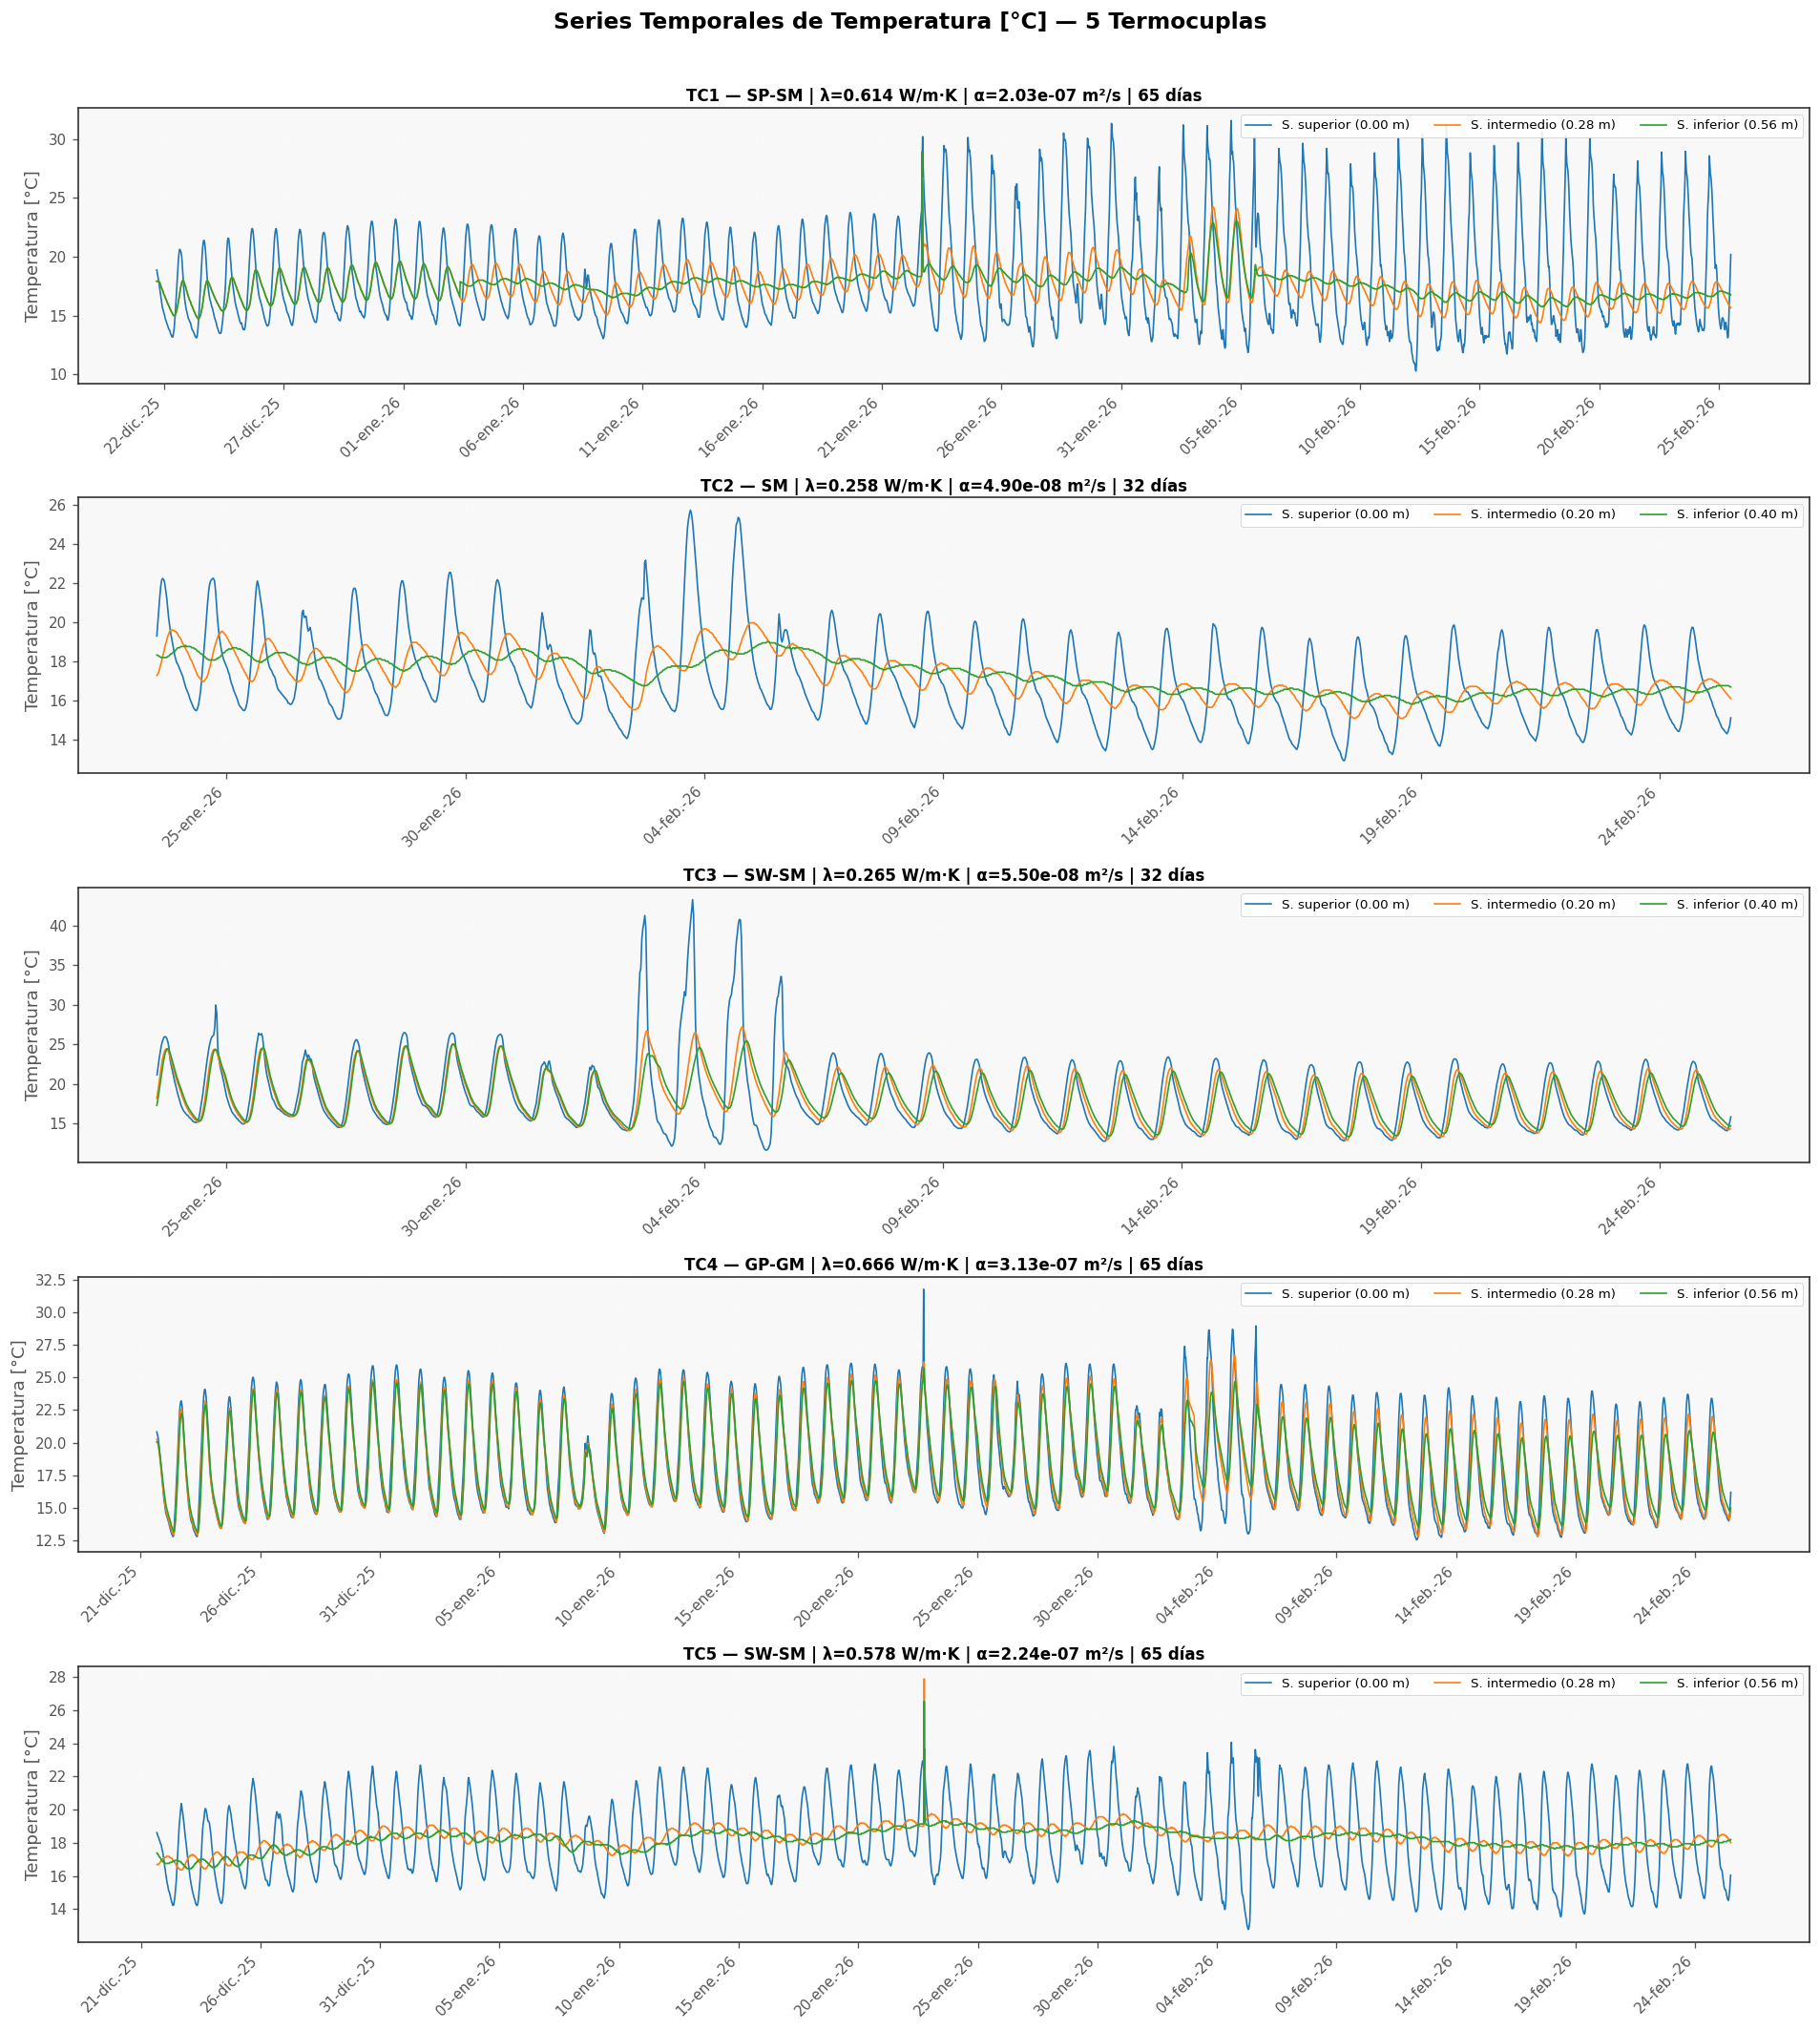

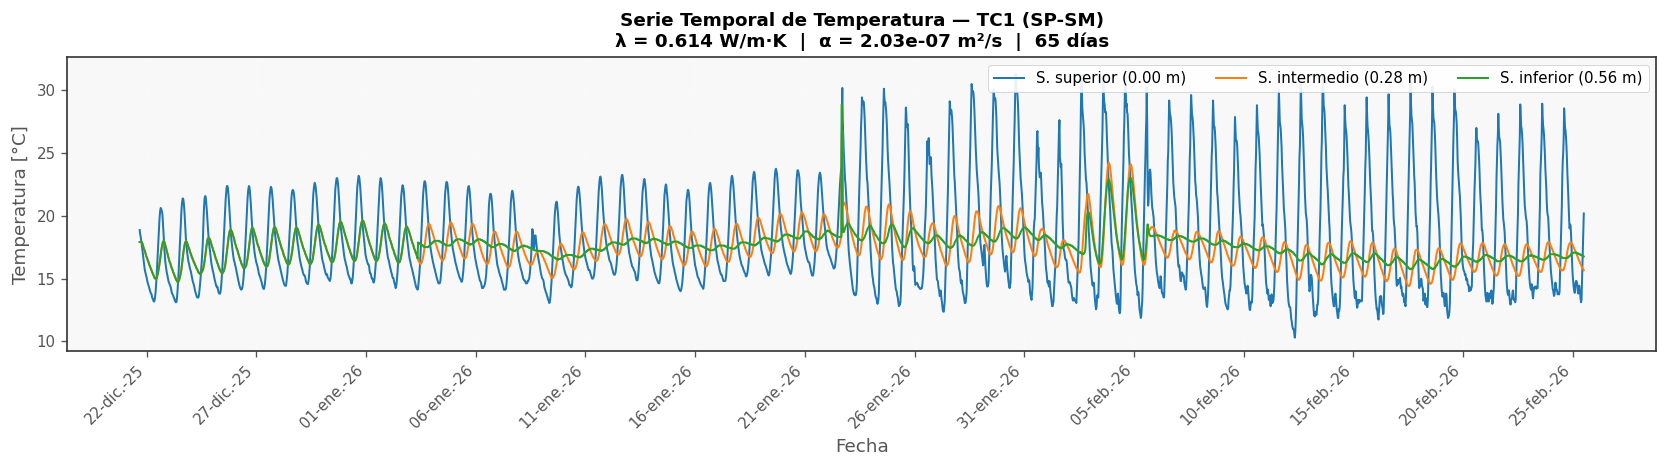

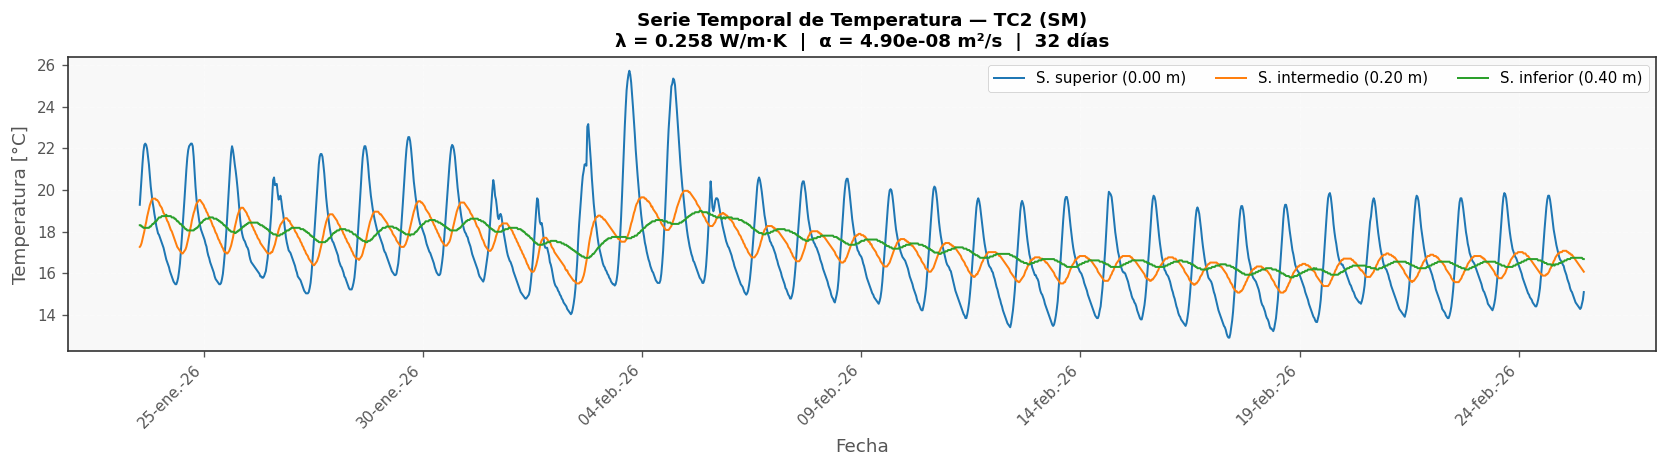

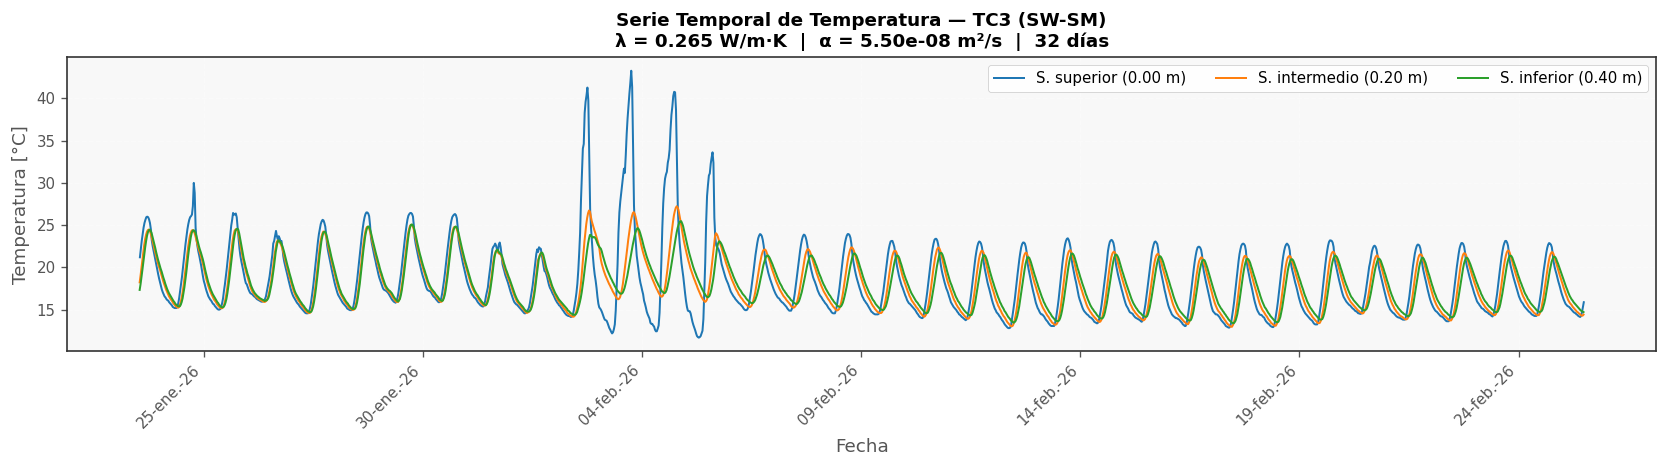

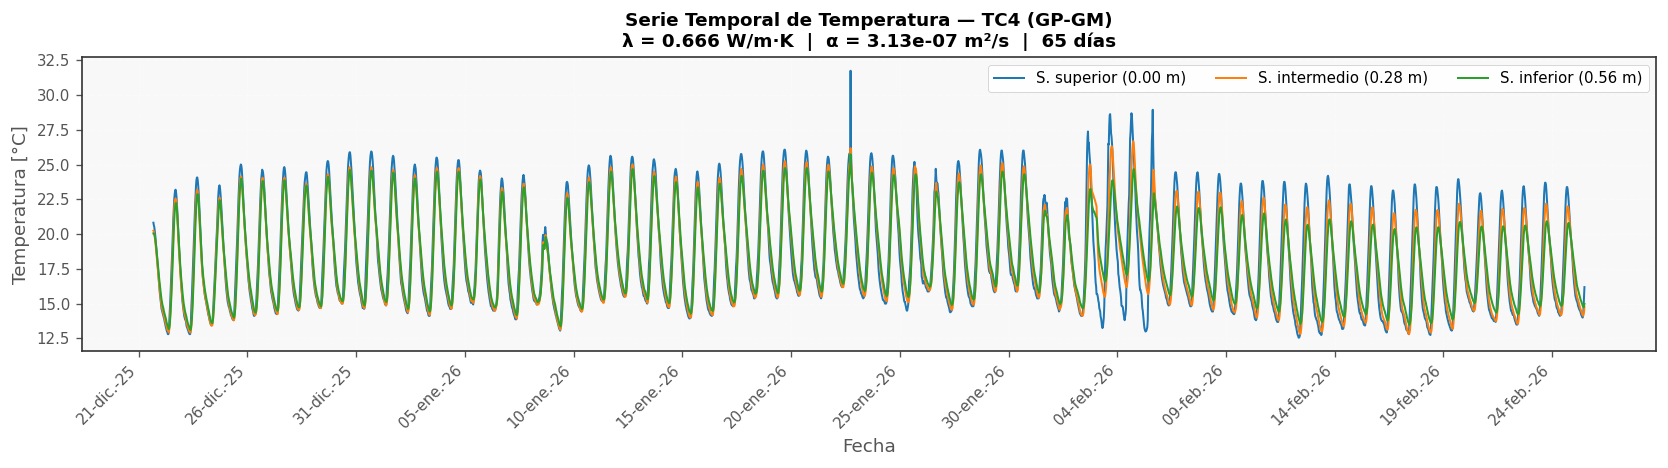

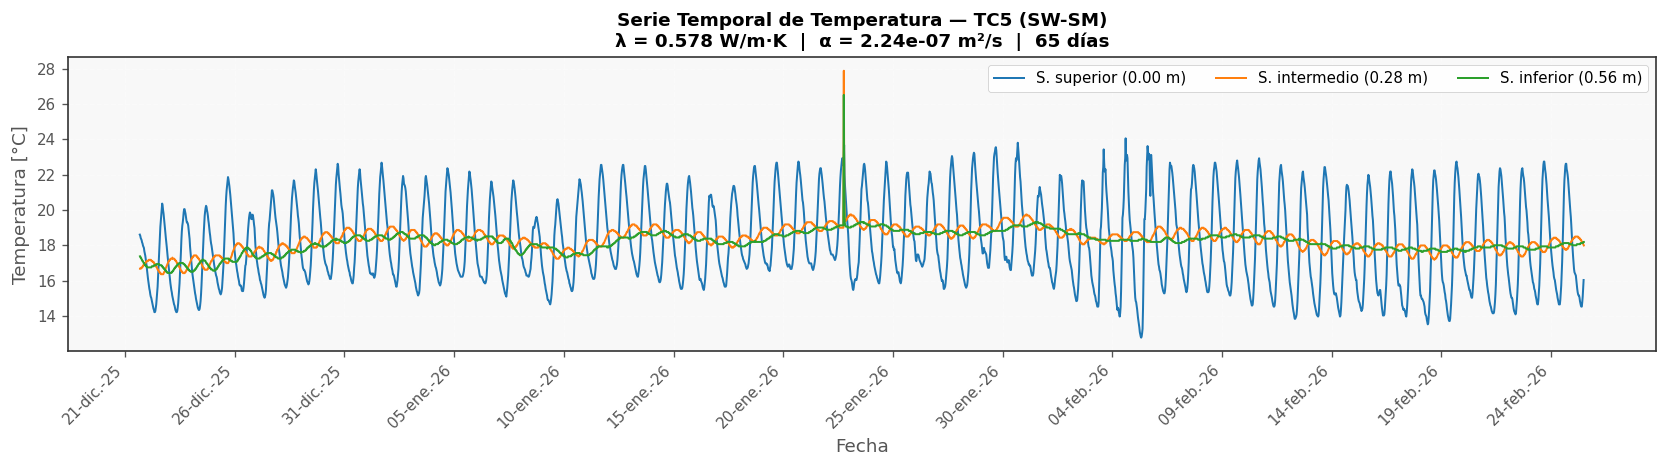

✔ Figuras de temperatura exportadas: combinada + 5 individuales


In [4]:
# ==========================================================================
# CELDA 4: Series de Temperatura por TC (combinada + individual por TC)
# ==========================================================================
import locale
try:
    locale.setlocale(locale.LC_TIME, 'es_ES.UTF-8')
except:
    try:
        locale.setlocale(locale.LC_TIME, 'Spanish_Spain.1252')
    except:
        pass

# Paleta de colores MATLAB-style por posición
tc_colors_matlab = {'surface': '#1f77b4', 'intermediate': '#ff7f0e', 'deep': '#2ca02c'}
pos_labels = {'surface': 'S. superior', 'intermediate': 'S. intermedio', 'deep': 'S. inferior'}

# Colores por TC
TC_COLORS = {
    'TC1': '#1f77b4', 'TC2': '#ff7f0e', 'TC3': '#2ca02c',
    'TC4': '#9467bd', 'TC5': '#d62728',
}

# Formato de fecha español: 01-ene-26
DATE_FMT = '%d-%b-%y'

# ======================================================================
# PANEL COMBINADO: Las 5 termocuplas
# ======================================================================
n_tcs = len(ACTIVE_TCS)
fig, axes = plt.subplots(n_tcs, 1, figsize=(16, 3.5*n_tcs))

for ax, tc_name in zip(axes, ACTIVE_TCS):
    tc_map = TC_CONFIG[tc_name]
    tc_start = pd.Timestamp(TC_PERIODS[tc_name][0])
    tc_end = pd.Timestamp(TC_PERIODS[tc_name][1])
    
    for pos in ['surface', 'intermediate', 'deep']:
        label = tc_map[pos]
        d_m = depths_m[label]
        mask = (df_raw['fecha'] >= tc_start) & (df_raw['fecha'] <= tc_end)
        df_plot = df_raw[mask].dropna(subset=[label])
        ax.plot(df_plot['fecha'], df_plot[label], color=tc_colors_matlab[pos],
                linewidth=1.0, label=f"{pos_labels[pos]} ({d_m:.2f} m)")
    
    p = THERMAL_PARAMS_LAB[tc_name]
    dias = (tc_end - tc_start).days
    ax.set_ylabel('Temperatura [°C]')
    ax.set_title(f'{tc_name} — {p["USCS"]} | λ={p["lambda_sediment"]:.3f} W/m·K | '
                 f'α={p["alpha_e"]:.2e} m²/s | {dias} días', fontsize=10, pad=4)
    ax.legend(loc='upper right', ncol=3, fontsize=8, framealpha=0.9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter(DATE_FMT))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

fig.suptitle('Series Temporales de Temperatura [°C] — 5 Termocuplas',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(str(img_dir / 'series_05A_hatch.png'), dpi=150, bbox_inches='tight')
plt.show()

# ======================================================================
# PANELES INDIVIDUALES: Una figura por cada TC
# ======================================================================
for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    tc_start = pd.Timestamp(TC_PERIODS[tc_name][0])
    tc_end = pd.Timestamp(TC_PERIODS[tc_name][1])
    p = THERMAL_PARAMS_LAB[tc_name]
    dias = (tc_end - tc_start).days

    fig_i, ax_i = plt.subplots(figsize=(14, 4))

    for pos in ['surface', 'intermediate', 'deep']:
        label = tc_map[pos]
        d_m = depths_m[label]
        mask = (df_raw['fecha'] >= tc_start) & (df_raw['fecha'] <= tc_end)
        df_plot = df_raw[mask].dropna(subset=[label])
        ax_i.plot(df_plot['fecha'], df_plot[label], color=tc_colors_matlab[pos],
                  linewidth=1.2, label=f"{pos_labels[pos]} ({d_m:.2f} m)")

    ax_i.set_ylabel('Temperatura [°C]')
    ax_i.set_xlabel('Fecha')
    ax_i.set_title(f'Serie Temporal de Temperatura — {tc_name} ({p["USCS"]})\n'
                   f'λ = {p["lambda_sediment"]:.3f} W/m·K  |  '
                   f'α = {p["alpha_e"]:.2e} m²/s  |  {dias} días',
                   fontsize=11, fontweight='bold')
    ax_i.legend(loc='upper right', ncol=3, fontsize=9, framealpha=0.9)
    ax_i.xaxis.set_major_formatter(mdates.DateFormatter(DATE_FMT))
    ax_i.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    plt.setp(ax_i.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

    fig_i.tight_layout()
    fig_i.savefig(str(img_dir / f'temperatura_{tc_name}_05A.png'), dpi=150, bbox_inches='tight')
    plt.show()

print(f"✔ Figuras de temperatura exportadas: combinada + {len(ACTIVE_TCS)} individuales")

---
## 5. Análisis Armónico — Extracción de Amplitud y Fase (60 días)

Se ajusta el modelo sinusoidal $T(t) = A \sin(2\pi t/P + \phi) + T_0$ con $P=24$ h.  
**Ajuste mejorado**: Se usan los 60 días completos de medición disponibles (para TC1/TC4/TC5),  
lo que produce R² significativamente mejores que con 30 días, según recomendación del especialista.

**Campos de la tabla de resultados:**

| Campo | Descripción |
|-------|-------------|
| **Sensor** | Identificador del sensor de temperatura (e.g. `temp_12`), según mapeo en Celda 2 |
| **TC** | Termocupla a la que pertenece el sensor (TC1–TC5) |
| **Prof** | Profundidad de instalación del sensor en cm respecto a la superficie del lecho |
| **Días** | Duración del registro utilizado para el ajuste armónico (días completos) |
| **A (°C)** | Amplitud del armónico diario ajustado: semi-rango de la oscilación térmica diaria |
| **φ (°)** | Fase del armónico diario en grados; indica el desfase temporal del pico de temperatura |
| **T₀ (°C)** | Offset (temperatura media) del modelo sinusoidal ajustado |
| **R²** | Coeficiente de determinación del ajuste sinusoidal; mide qué tan bien el modelo reproduce la señal medida |
| **Calidad** | Clasificación cualitativa: ★★★ (R² > 0.7), ★★☆ (R² > 0.3), ★☆☆ (R² ≤ 0.3) |

In [5]:
# ==========================================================================
# CELDA 5: Análisis Armónico por Sensor (usando período completo)
# ==========================================================================
# Nota: Usar df_aligned completo (no df_valid que excluía TC2/TC3 por NaN)
# Cada TC se analiza con SU período completo de datos

R2_WARN_THRESHOLD = 0.30   # Umbral para ⚠️ bajo R²
R2_POOR_THRESHOLD = 0.10   # Umbral para 🔴 R² muy bajo

print("ANÁLISIS ARMÓNICO — CICLO DIARIO (P = 24 h)")
print("Usando período completo de medición por cada TC")
print("=" * 105)
print(f"{'Sensor':<10} {'TC':<5} {'Prof':<8} {'Días':<6} {'A (°C)':<10} {'φ (°)':<10} {'T₀ (°C)':<10} {'R²':<10} {'Calidad':<10} {'Alerta'}")
print("-" * 105)

harmonic_results = {}
low_r2_sensors = []

for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    tc_start = pd.Timestamp(TC_PERIODS[tc_name][0])
    tc_end = pd.Timestamp(TC_PERIODS[tc_name][1])
    
    # Filtrar datos al período de esta TC
    mask_tc = (df_aligned['fecha'] >= tc_start) & (df_aligned['fecha'] <= tc_end)
    df_tc = df_aligned[mask_tc].copy()
    
    t_start_tc = df_tc['fecha'].min()
    time_hours_tc = (df_tc['fecha'] - t_start_tc).dt.total_seconds() / 3600.0
    dias_tc = (tc_end - tc_start).days
    
    for pos in ['surface', 'intermediate', 'deep']:
        col = tc_map[pos]
        if col not in df_tc.columns:
            continue
        series = df_tc[col].values
        valid = ~np.isnan(series)
        if valid.sum() < 48:
            continue
        
        result = fit_harmonic_model(time_hours_tc.values[valid], series[valid], period_hours=24.0)
        result['tc_name'] = tc_name
        result['time_hours'] = time_hours_tc.values[valid]
        result['n_days'] = dias_tc
        harmonic_results[col] = result
        
        r2 = result['r_squared']
        calidad = '★★★' if r2 > 0.7 else ('★★☆' if r2 > 0.3 else '★☆☆')
        d_cm = depths_m[col] * 100
        
        # Flag por bajo R²
        if r2 < R2_POOR_THRESHOLD:
            alerta = '🔴 MUY BAJO'
            low_r2_sensors.append((col, tc_name, pos, r2))
        elif r2 < R2_WARN_THRESHOLD:
            alerta = '⚠️  BAJO'
            low_r2_sensors.append((col, tc_name, pos, r2))
        else:
            alerta = ''
        
        print(f"{col:<10} {tc_name:<5} {d_cm:<8.0f} {dias_tc:<6} {result['amplitude']:<10.4f} "
              f"{np.degrees(result['phase']):<10.1f} {result['offset']:<10.2f} "
              f"{r2:<10.4f} {calidad:<10} {alerta}")

print(f"\n✔ Análisis armónico completado para {len(harmonic_results)} sensores")
print(f"   TC1/TC4/TC5: ~66 días de ajuste (21-dic-25 16:00 → 25-feb-26 12:00)")
print(f"   TC2/TC3: ~33 días de ajuste (23-ene-26 13:00 → 25-feb-26 12:00)")

# Resumen de alertas
if low_r2_sensors:
    print(f"\n{'='*105}")
    print(f"⚠️  SENSORES CON BAJO R² (umbral advertencia: {R2_WARN_THRESHOLD})")
    print(f"{'─'*105}")
    for col, tc, pos, r2 in low_r2_sensors:
        print(f"   {col} ({tc}, {pos}): R² = {r2:.4f} — señal armónica débil, "
              f"interpretar flujo con precaución")
    print(f"\n   RECOMENDACIÓN: Los pares que incluyan estos sensores tendrán mayor "
          f"incertidumbre en la estimación de flujo.")
else:
    print(f"\n✔ Todos los sensores con R² ≥ {R2_WARN_THRESHOLD}")

ANÁLISIS ARMÓNICO — CICLO DIARIO (P = 24 h)
Usando período completo de medición por cada TC
Sensor     TC    Prof     Días   A (°C)     φ (°)      T₀ (°C)    R²         Calidad    Alerta
---------------------------------------------------------------------------------------------------------
temp_12    TC1   0        65     5.1520     87.3       18.28      0.7280     ★★★        
temp_9     TC1   28       65     1.4228     8.0        17.49      0.4830     ★★☆        
temp_8     TC1   56       65     0.4750     355.5      17.57      0.1028     ★☆☆        ⚠️  BAJO
temp_4     TC2   0        32     2.4911     17.4       17.01      0.6192     ★★☆        
temp_6     TC2   20       32     0.7324     283.7      17.15      0.2180     ★☆☆        ⚠️  BAJO
temp_7     TC2   40       32     0.1801     199.1      17.30      0.0216     ★☆☆        🔴 MUY BAJO
temp_1     TC3   0        32     5.0217     25.9       18.40      0.6062     ★★☆        
temp_10    TC3   20       32     3.7429     351.7      18.

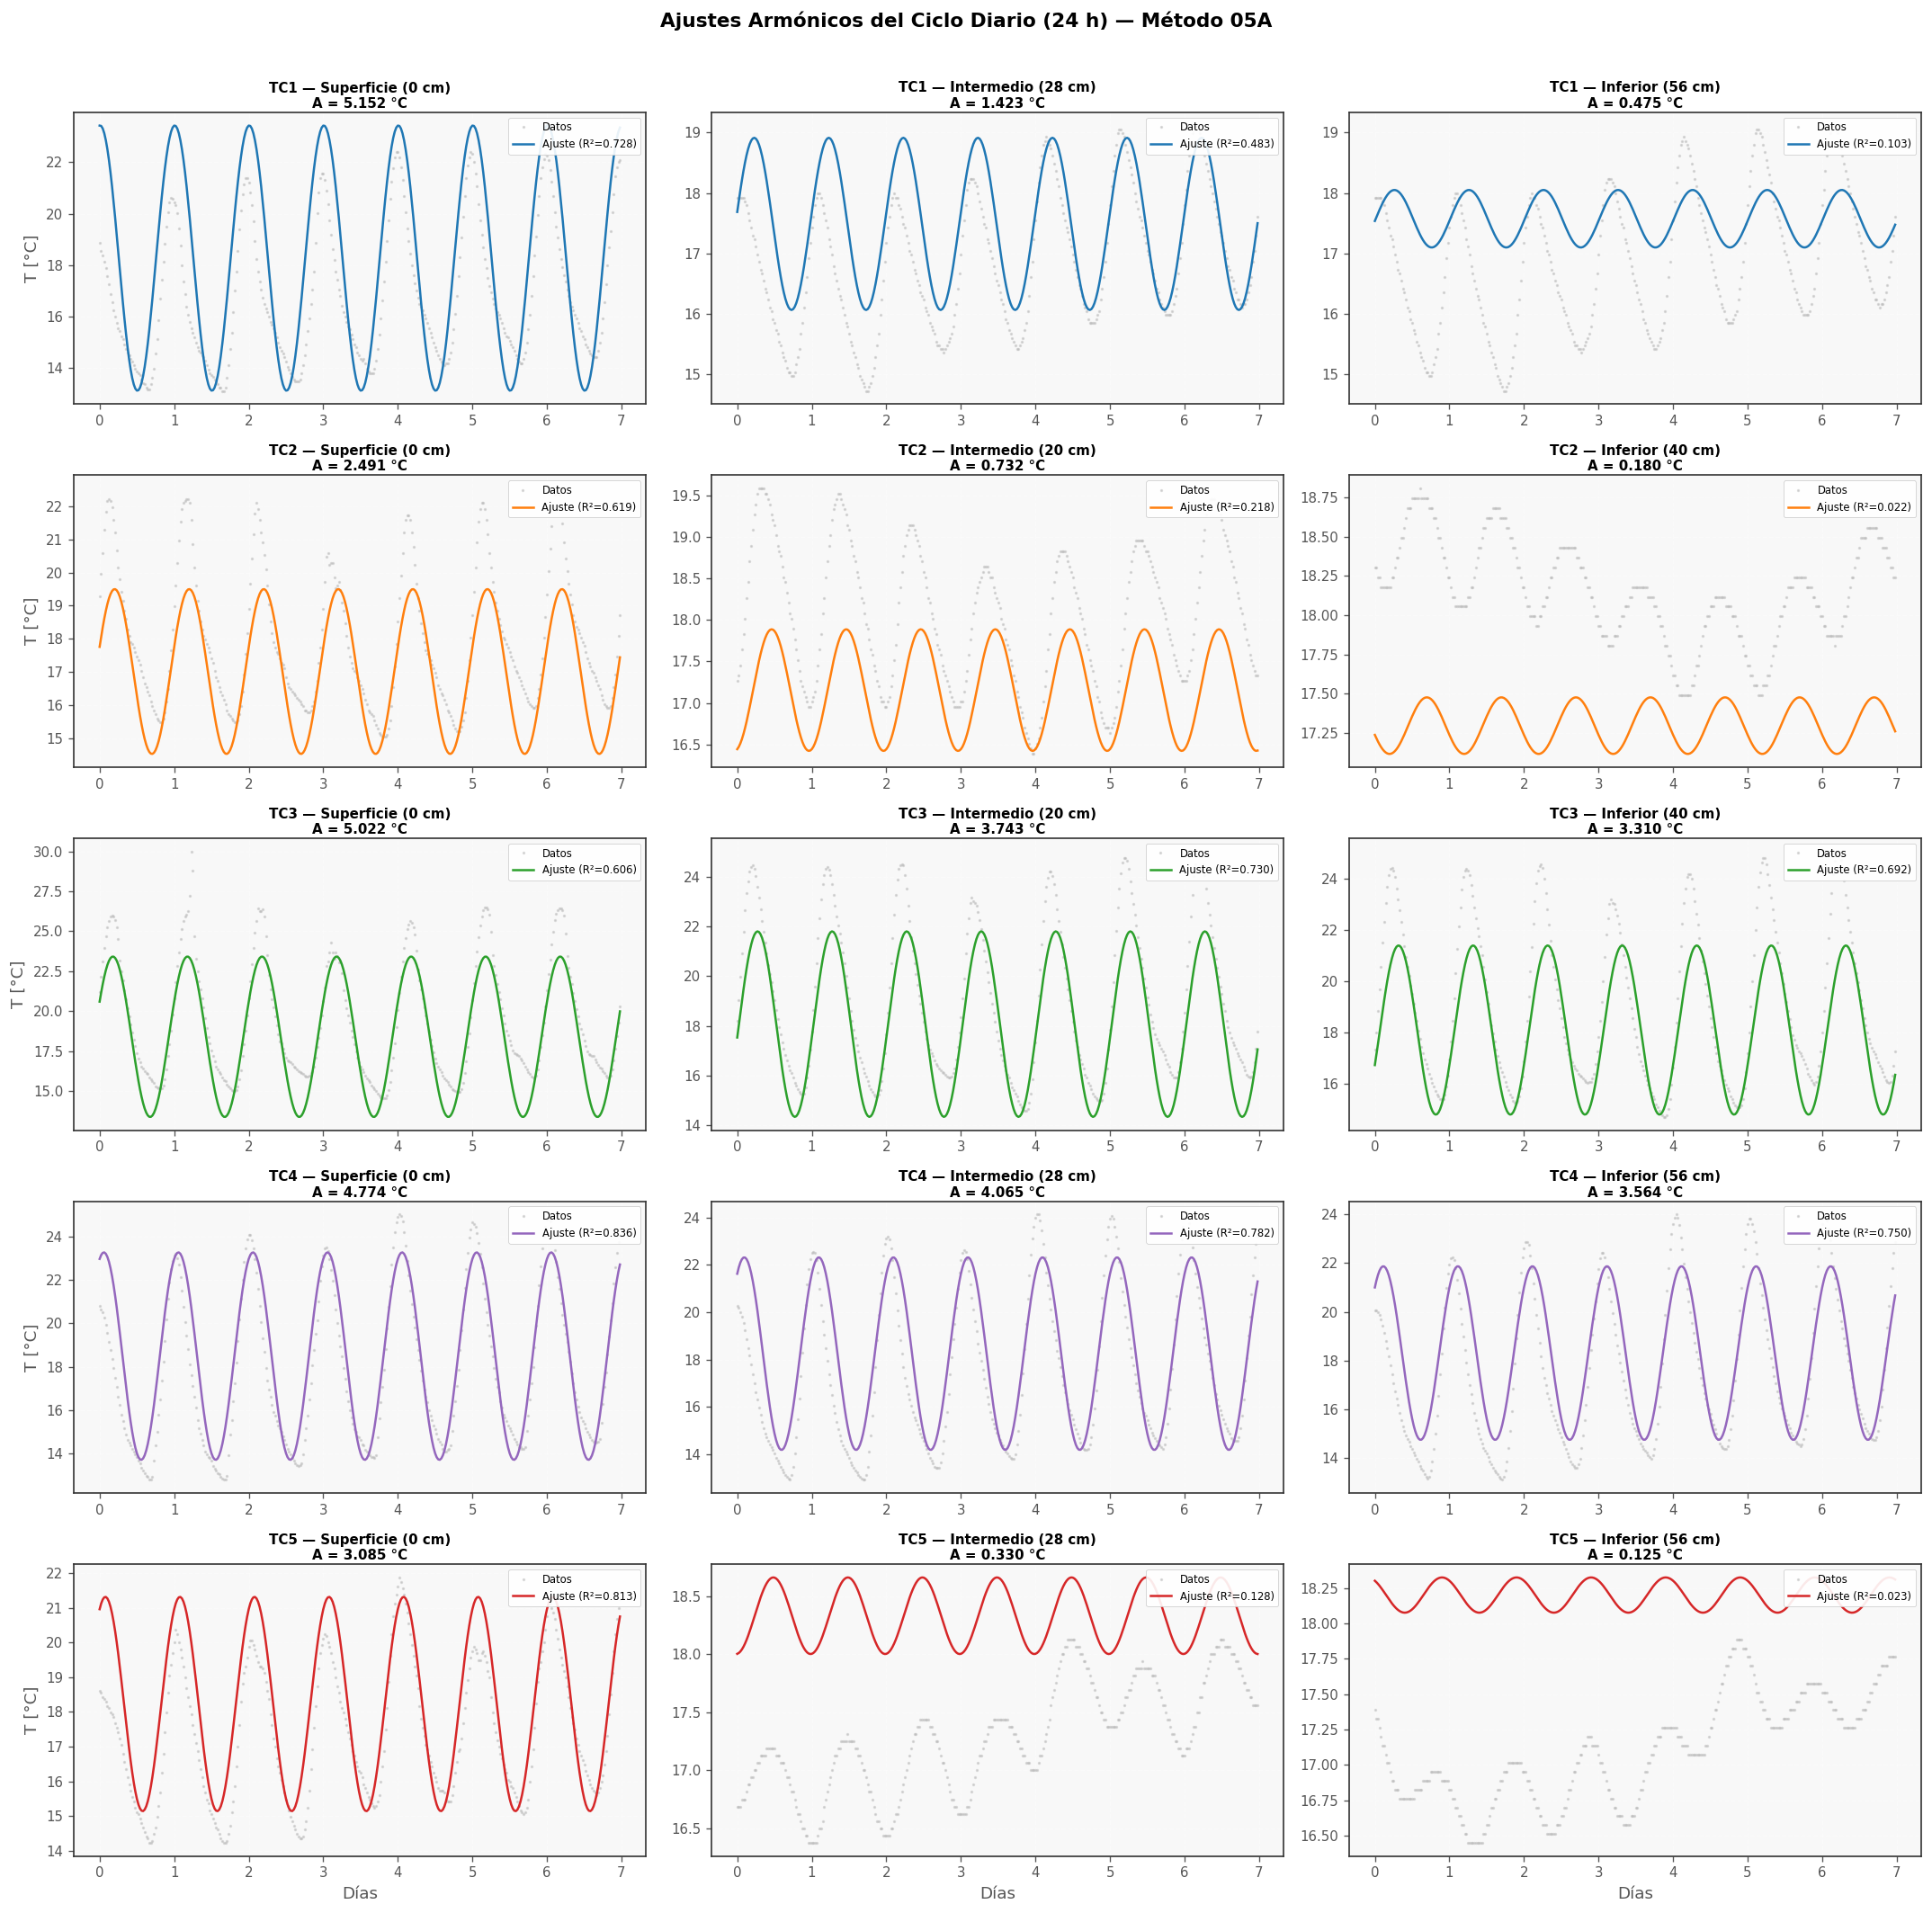

In [6]:
# ==========================================================================
# CELDA 6: Visualización de ajustes armónicos (primeros 7 días)
# ==========================================================================
fig, axes = plt.subplots(len(ACTIVE_TCS), 3, figsize=(18, 3.5*len(ACTIVE_TCS)))

for row_idx, tc_name in enumerate(ACTIVE_TCS):
    tc_map = TC_CONFIG[tc_name]
    for col_idx, (pos, pos_es) in enumerate([('surface', 'Superficie'),
                                              ('intermediate', 'Intermedio'),
                                              ('deep', 'Inferior')]):
        ax = axes[row_idx][col_idx]
        col = tc_map[pos]
        
        if col not in harmonic_results:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
            continue
        
        result = harmonic_results[col]
        t_h = result['time_hours']
        
        tc_start = pd.Timestamp(TC_PERIODS[tc_name][0])
        tc_end = pd.Timestamp(TC_PERIODS[tc_name][1])
        mask_tc = (df_aligned['fecha'] >= tc_start) & (df_aligned['fecha'] <= tc_end)
        df_tc = df_aligned[mask_tc]
        series = df_tc[col].dropna().values
        
        max_pts = min(len(t_h), 48 * 7)
        ax.plot(t_h[:max_pts] / 24, series[:max_pts], '.', color='#bbbbbb',
                alpha=0.5, markersize=2, label='Datos')
        ax.plot(t_h[:max_pts] / 24, result['fitted'][:max_pts], '-',
                color=TC_COLORS[tc_name], linewidth=1.5,
                label=f'Ajuste (R²={result["r_squared"]:.3f})')
        
        depth_cm = depths_m[col] * 100
        ax.set_title(f'{tc_name} — {pos_es} ({depth_cm:.0f} cm)\nA = {result["amplitude"]:.3f} °C',
                     fontsize=9, pad=3)
        if row_idx == len(ACTIVE_TCS)-1:
            ax.set_xlabel('Días')
        if col_idx == 0:
            ax.set_ylabel('T [°C]')
        ax.legend(fontsize=7, loc='upper right', framealpha=0.9)

fig.suptitle('Ajustes Armónicos del Ciclo Diario (24 h) — Método 05A',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(str(img_dir / 'ajustes_armonicos_05A.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Cálculo de Flujo: Hatch-Amplitude (Cabecera) + McCallum (Validación)

Se calculan flujos usando **parámetros térmicos de laboratorio IDIEM** específicos para cada TC.  
Solo se reportan y analizan **Hatch-Amplitude** y **McCallum**.

In [7]:
# ==========================================================================
# CELDA 7: Análisis de pares + Cálculo de flujo con parámetros IDIEM
# ==========================================================================

# Construir pares de sensores
pairs = []
for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    s, m, d = tc_map['surface'], tc_map['intermediate'], tc_map['deep']
    dz_sm = abs(depths_m[m] - depths_m[s])
    dz_md = abs(depths_m[d] - depths_m[m])
    dz_sd = abs(depths_m[d] - depths_m[s])
    pairs.append((s, m, f'{tc_name}: sup-int', dz_sm, tc_name))
    pairs.append((m, d, f'{tc_name}: int-inf', dz_md, tc_name))
    pairs.append((s, d, f'{tc_name}: sup-inf', dz_sd, tc_name))

# Analizar pares y calcular flujos
print(f"{'='*110}")
print(f" FLUJO VERTICAL: Hatch-Amplitude (cabecera) + McCallum (validación) ".center(110))
print(f" Parámetros térmicos: LABORATORIO IDIEM (por TC) ".center(110))
print(f"{'='*110}")

all_flux_results = {}
pair_results = {}

for s_shallow, s_deep, pair_label, dz, tc_name in pairs:
    # Obtener datos para este par en su período
    tc_start = pd.Timestamp(TC_PERIODS[tc_name][0])
    tc_end = pd.Timestamp(TC_PERIODS[tc_name][1])
    mask_tc = (df_aligned['fecha'] >= tc_start) & (df_aligned['fecha'] <= tc_end)
    df_tc = df_aligned[mask_tc]
    
    mask = df_tc[s_shallow].notna() & df_tc[s_deep].notna()
    if mask.sum() < 48:
        print(f"  Par {pair_label}: DATOS INSUFICIENTES")
        continue
    
    t_start_tc = df_tc['fecha'].min()
    t_valid = ((df_tc['fecha'] - t_start_tc).dt.total_seconds() / 3600.0).values[mask]
    t1 = df_tc[s_shallow].values[mask]
    t2 = df_tc[s_deep].values[mask]
    
    params = analyze_sensor_pair(t_valid, t1, t2, period_hours=24.0)
    pair_results[pair_label] = {'params': params, 'dz': dz, 's_shallow': s_shallow, 's_deep': s_deep}
    
    # Usar parámetros térmicos IDIEM de esta TC
    tp = THERMAL_PARAMS_LAB[tc_name]
    beta_tc = THERMAL_PARAMS_VFLUX[tc_name]['beta_d50']
    
    flux_result = calculate_vflux_all_methods(
        amplitude_shallow=params['A_shallow'],
        amplitude_deep=params['A_deep'],
        phase_shallow=params['phi_shallow'],
        phase_deep=params['phi_deep'],
        depth_difference=dz,
        thermal_conductivity=tp['lambda_sediment'],
        heat_capacity_sediment=tp['C_sediment'],
        heat_capacity_water=tp['C_water'],
        angular_frequency=tp['omega'],
        beta=beta_tc
    )
    all_flux_results[pair_label] = flux_result

print(f"\nCompletado: {len(all_flux_results)} pares analizados")

                      FLUJO VERTICAL: Hatch-Amplitude (cabecera) + McCallum (validación)                      
                               Parámetros térmicos: LABORATORIO IDIEM (por TC)                                
  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 3.19e-06       275.67
  hatch_amplitude          3.63e-06       314.06
  hatch_phase             -1.75e-05     -1512.41
  keery                    4.00e-06       345.76
  luce                     7.43e-06       642.06
  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 2.23e-06       193.07
  hatch_amplitude          4.42e-06       381.93
  hatch_phase             -2.29e-05     -1978.80
  keery                    4.63e-06       400.45
  luce                     6.84e-06       590.88
  Método                        m/s       mm/día
  --------------------------------------------


---
## 7. Tabla de Resultados — Hatch-Amplitude vs McCallum

**¿Por qué "Parámetros térmicos IDIEM por TC — Difusividad α medida (no calculada)"?**  
En la literatura estándar, la difusividad térmica α se calcula como α = λ / C_s. En este estudio,
IDIEM midió α directamente en laboratorio con el método de aguja caliente (Hot Disk), por lo que
**no depende** de errores compuestos de λ y C_s. Cada TC tiene su propio juego de parámetros
medidos, reflejando la heterogeneidad real del sedimento.

**Campos de la tabla por TC:**

| Campo | Descripción |
|-------|-------------|
| **Par** | Par de sensores utilizado: `sup-int` (superficie → intermedio), `int-inf` (intermedio → profundo), `sup-inf` (superficie → profundo) |
| **Hatch-Amp (mm/d)** | Flujo vertical estimado con el método Hatch-Amplitude, en mm/día. Método cabecera del estudio |
| **McCallum (mm/d)** | Flujo vertical estimado con el método McCallum, en mm/día. Usado como validación cruzada |
| **Hatch-Amp (m/s)** | Mismo flujo Hatch-Amplitude expresado en m/s (unidad SI, útil para modelación numérica) |
| **Diferencia %** | Diferencia relativa entre Hatch-Amp y McCallum: $\|HA - MC\| / \|HA\| \times 100$. Menor diferencia → mayor consistencia |

**Convención de signos:** (+) Infiltración: flujo descendente río → acuífero. (−) Exfiltración: flujo ascendente acuífero → río.

**Campos de la tabla resumen por TC:**

| Campo | Descripción |
|-------|-------------|
| **TC** | Termocupla (TC1–TC5) |
| **Hatch-Amp (mm/d)** | Media ± desviación estándar del flujo Hatch-Amplitude promediando los 3 pares |
| **McCallum (mm/d)** | Media ± desviación estándar del flujo McCallum promediando los 3 pares |
| **Diferencia** | Diferencia absoluta entre las medias de ambos métodos (mm/d) |
| **Dirección** | Infiltración ↓ si flujo medio > 0; Exfiltración ↑ si flujo medio < 0 |

In [8]:
# ==========================================================================
# CELDA 8: Tabla comparativa SOLO Hatch-Amp y McCallum + Comparación MATLAB
# ==========================================================================
MS_TO_MM_DAY = 86400.0 * 1000.0

results_data = []
for pair_name, flux_result in all_flux_results.items():
    tc_name = pair_name.split(':')[0].strip()
    pair_type = pair_name.split(':')[1].strip()
    
    for method, label in [('hatch_amplitude', 'Hatch-Amplitude'), ('mccallum', 'McCallum')]:
        v_mm = flux_result['flux_mm_day'].get(method, np.nan)
        v_ms = flux_result['flux_m_s'].get(method, np.nan)
        results_data.append({
            'TC': tc_name,
            'Par': pair_type,
            'Método': label,
            'q (mm/día)': round(v_mm, 2) if not np.isnan(v_mm) else np.nan,
            'q (m/s)': v_ms,
            'Dirección': 'Infiltración ↓' if v_mm > 0 else ('Exfiltración ↑' if v_mm < 0 else '-'),
        })

df_results = pd.DataFrame(results_data)
df_results['q (m/s)'] = pd.to_numeric(df_results['q (m/s)'], errors='coerce')

print(f"{'='*110}")
print(f" RESULTADOS: HATCH-AMPLITUDE (Cabecera) vs McCALLUM (Validación) ".center(110))
print(f" Parámetros térmicos IDIEM por TC — Difusividad α medida (no calculada) ".center(110))
print(f"{'='*110}")
print(f"  (+) Flujo positivo = Infiltración (río → acuífero)")
print(f"  (-) Flujo negativo = Exfiltración (acuífero → río)")
print()

# Tabla pivotada
for tc_name in ACTIVE_TCS:
    df_tc = df_results[df_results['TC'] == tc_name]
    tp = THERMAL_PARAMS_LAB[tc_name]
    print(f"\n{'─'*80}")
    print(f"  {tc_name} | λ={tp['lambda_sediment']:.3f} W/m·K | C={tp['C_sediment']/1e6:.3f} MJ/m³·K | α={tp['alpha_e']:.2e} m²/s")
    print(f"{'─'*80}")
    print(f"  {'Par':<12} {'Hatch-Amp (mm/d)':<20} {'McCallum (mm/d)':<20} {'Hatch-Amp (m/s)':<18} {'Diferencia %':<15}")
    print(f"  {'-'*75}")
    
    for pair_type in ['sup-int', 'int-inf', 'sup-inf']:
        df_pair = df_tc[df_tc['Par'] == pair_type]
        ha_row = df_pair[df_pair['Método'] == 'Hatch-Amplitude']
        mc_row = df_pair[df_pair['Método'] == 'McCallum']
        
        ha_mm = ha_row['q (mm/día)'].values[0] if len(ha_row) > 0 else np.nan
        mc_mm = mc_row['q (mm/día)'].values[0] if len(mc_row) > 0 else np.nan
        ha_ms = ha_row['q (m/s)'].values[0] if len(ha_row) > 0 else np.nan
        
        diff_pct = abs(ha_mm - mc_mm) / abs(ha_mm) * 100 if ha_mm != 0 and not np.isnan(ha_mm) and not np.isnan(mc_mm) else np.nan
        
        ha_ms_str = f"{ha_ms:.2e}" if not np.isnan(ha_ms) else 'NaN'
        diff_str = f"{diff_pct:.1f}%" if not np.isnan(diff_pct) else '-'
        
        print(f"  {pair_type:<12} {ha_mm:<20.2f} {mc_mm:<20.2f} {ha_ms_str:<18} {diff_str:<15}")

# Resumen por TC (promedio Hatch-Amp) + Comparación MATLAB
print(f"\n{'='*120}")
print(f" FLUJO PROMEDIO POR TC — Python vs MATLAB (VFLUX2) ".center(120))
print(f"{'='*120}")
print(f"  {'TC':<8} {'HA Python':<18} {'MC Python':<18} {'MATLAB (min-máx)':<22} {'MATLAB prom':<14} {'Δ Python-MATLAB':<16} {'Dirección':<15}")
print(f"  {'-'*110}")

flujos_promedio_tc = {}
for tc_name in ACTIVE_TCS:
    df_tc = df_results[df_results['TC'] == tc_name]
    ha_vals = df_tc[df_tc['Método'] == 'Hatch-Amplitude']['q (mm/día)'].dropna()
    mc_vals = df_tc[df_tc['Método'] == 'McCallum']['q (mm/día)'].dropna()
    
    ha_mean = ha_vals.mean() if len(ha_vals) > 0 else np.nan
    ha_std = ha_vals.std() if len(ha_vals) > 1 else 0
    mc_mean = mc_vals.mean() if len(mc_vals) > 0 else np.nan
    mc_std = mc_vals.std() if len(mc_vals) > 1 else 0
    
    ref = MATLAB_REFERENCE.get(tc_name, {})
    ref_mean = ref.get('mean', np.nan)
    ref_range = f"{ref.get('min', '?')}–{ref.get('max', '?')}" if ref else '-'
    delta = ha_mean - ref_mean if not np.isnan(ha_mean) and not np.isnan(ref_mean) else np.nan
    delta_str = f"{delta:+.1f} ({abs(delta/ref_mean)*100:.0f}%)" if not np.isnan(delta) else '-'
    
    dir_str = 'Infiltración ↓' if ha_mean > 0 else 'Exfiltración ↑'
    
    flujos_promedio_tc[tc_name] = {'hatch_mean': ha_mean, 'hatch_std': ha_std,
                                    'mc_mean': mc_mean, 'mc_std': mc_std}
    
    print(f"  {tc_name:<8} {ha_mean:>7.1f} ± {ha_std:<7.1f}  {mc_mean:>7.1f} ± {mc_std:<7.1f}  "
          f"{ref_range:<22} {ref_mean:<14} {delta_str:<16} {dir_str:<15}")

# Promedio global
all_ha = df_results[df_results['Método'] == 'Hatch-Amplitude']['q (mm/día)'].dropna()
all_mc = df_results[df_results['Método'] == 'McCallum']['q (mm/día)'].dropna()
print(f"  {'─'*110}")
print(f"  {'GLOBAL':<8} {all_ha.mean():>7.1f} ± {all_ha.std():<7.1f}  {all_mc.mean():>7.1f} ± {all_mc.std():<7.1f}")

                       RESULTADOS: HATCH-AMPLITUDE (Cabecera) vs McCALLUM (Validación)                        
                    Parámetros térmicos IDIEM por TC — Difusividad α medida (no calculada)                    
  (+) Flujo positivo = Infiltración (río → acuífero)
  (-) Flujo negativo = Exfiltración (acuífero → río)


────────────────────────────────────────────────────────────────────────────────
  TC1 | λ=0.614 W/m·K | C=3.389 MJ/m³·K | α=2.03e-07 m²/s
────────────────────────────────────────────────────────────────────────────────
  Par          Hatch-Amp (mm/d)     McCallum (mm/d)      Hatch-Amp (m/s)    Diferencia %   
  ---------------------------------------------------------------------------
  sup-int      314.06               275.67               3.63e-06           12.2%          
  int-inf      381.93               193.07               4.42e-06           49.4%          
  sup-inf      345.85               984.68               4.00e-06           184.7%         

───

---
## 8. Visualizaciones

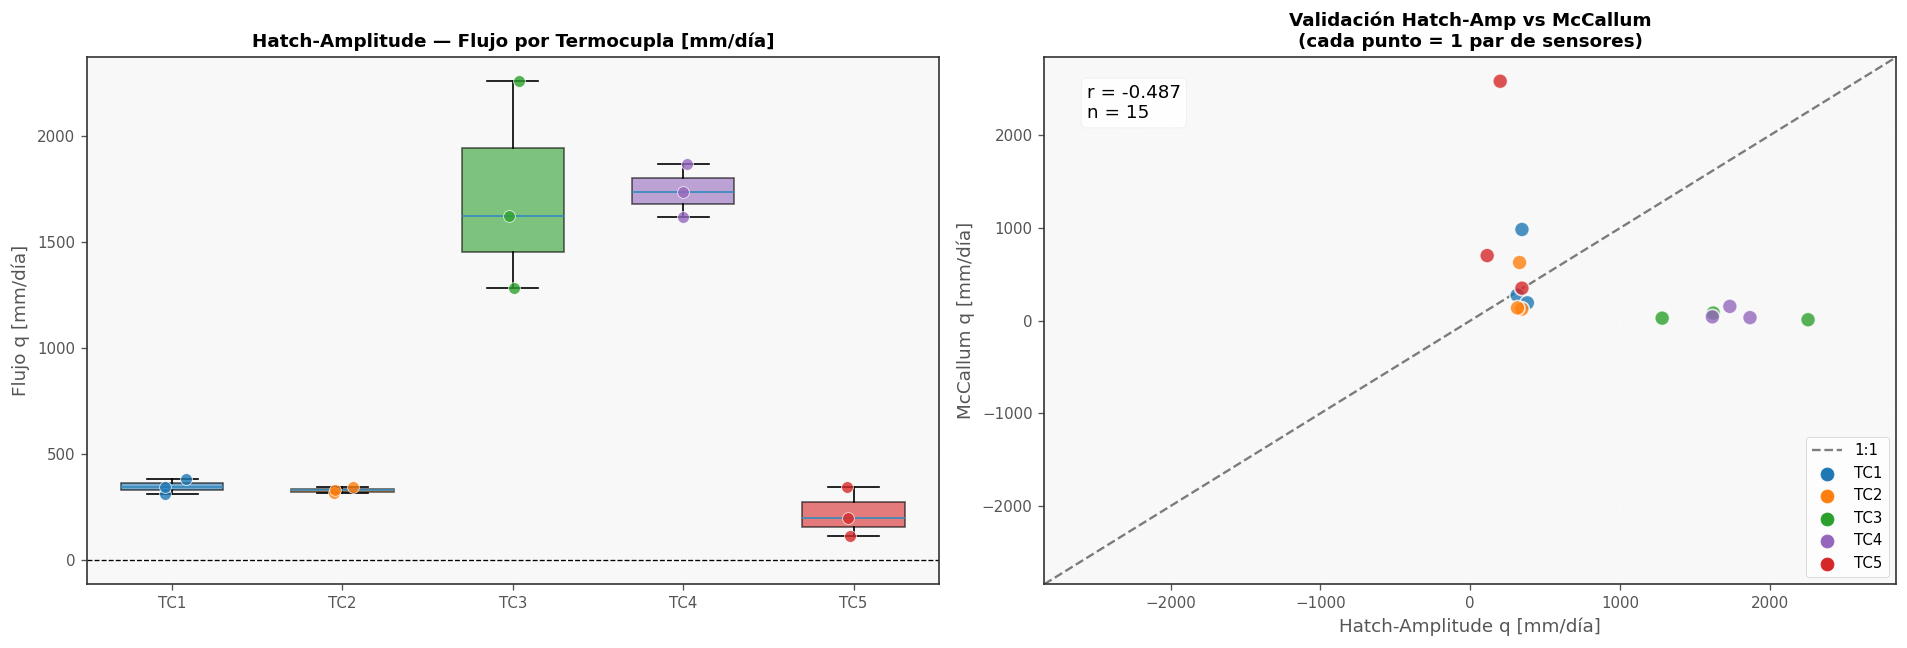


MÉTRICAS DE VALIDACIÓN Hatch-Amp vs McCallum:
  Correlación r: -0.487
  RMSE: 1263.94 mm/día
  Sesgo (McCallum - Hatch): -449.08 mm/día


In [9]:
# ==========================================================================
# CELDA 9: Boxplot para Hatch-Amplitude (por TC)
# ==========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# --- Panel 1: Boxplot Hatch-Amplitude por TC ---
ax1 = axes[0]
data_ha = []
labels_ha = []
colors_bp = []
for tc_name in ACTIVE_TCS:
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    vals = [v['flux_mm_day'].get('hatch_amplitude', np.nan) for v in tc_pairs.values()]
    vals = [x for x in vals if not np.isnan(x)]
    data_ha.append(vals)
    labels_ha.append(tc_name)
    colors_bp.append(TC_COLORS[tc_name])

bp1 = ax1.boxplot(data_ha, tick_labels=labels_ha, patch_artist=True, widths=0.6)
for patch, color in zip(bp1['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for i, vals in enumerate(data_ha):
    x = np.random.normal(i+1, 0.04, size=len(vals))
    ax1.scatter(x, vals, color=colors_bp[i], alpha=0.8, s=50, zorder=5, edgecolors='white')

ax1.axhline(y=0, color='k', linestyle='--', linewidth=0.8)
ax1.set_ylabel('Flujo q [mm/día]')
ax1.set_title('Hatch-Amplitude — Flujo por Termocupla [mm/día]', fontsize=11, fontweight='bold')

# --- Panel 2: Comparación Hatch vs McCallum ---
ax2 = axes[1]
all_ha_vals = []
all_mc_vals = []
all_colors = []
for i, tc_name in enumerate(ACTIVE_TCS):
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    for pair_name, fr in tc_pairs.items():
        ha = fr['flux_mm_day'].get('hatch_amplitude', np.nan)
        mc = fr['flux_mm_day'].get('mccallum', np.nan)
        if not np.isnan(ha) and not np.isnan(mc):
            all_ha_vals.append(ha)
            all_mc_vals.append(mc)
            all_colors.append(TC_COLORS[tc_name])

ax2.scatter(all_ha_vals, all_mc_vals, c=all_colors, s=80, alpha=0.8,
            edgecolors='white', linewidth=1, zorder=5)

lim_vals = all_ha_vals + all_mc_vals
if lim_vals:
    lim = max(abs(min(lim_vals)), abs(max(lim_vals))) * 1.1
    ax2.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.5, label='1:1')
    ax2.set_xlim(-lim, lim)
    ax2.set_ylim(-lim, lim)

if len(all_ha_vals) > 2:
    corr = np.corrcoef(all_ha_vals, all_mc_vals)[0, 1]
    ax2.text(0.05, 0.95, f'r = {corr:.3f}\nn = {len(all_ha_vals)}',
             transform=ax2.transAxes, fontsize=11, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

for tc_name in ACTIVE_TCS:
    ax2.scatter([], [], color=TC_COLORS[tc_name], s=60, label=tc_name)
ax2.legend(fontsize=9, loc='lower right')

ax2.set_xlabel('Hatch-Amplitude q [mm/día]')
ax2.set_ylabel('McCallum q [mm/día]')
ax2.set_title('Validación Hatch-Amp vs McCallum\n(cada punto = 1 par de sensores)', fontsize=11, fontweight='bold')

fig.tight_layout()
fig.savefig(str(img_dir / 'boxplot_hatch_05A.png'), dpi=150, bbox_inches='tight')
plt.show()

if len(all_ha_vals) > 2:
    rmse = np.sqrt(np.mean((np.array(all_ha_vals) - np.array(all_mc_vals))**2))
    bias = np.mean(np.array(all_mc_vals) - np.array(all_ha_vals))
    print(f"\nMÉTRICAS DE VALIDACIÓN Hatch-Amp vs McCallum:")
    print(f"  Correlación r: {corr:.3f}")
    print(f"  RMSE: {rmse:.2f} mm/día")
    print(f"  Sesgo (McCallum - Hatch): {bias:.2f} mm/día")

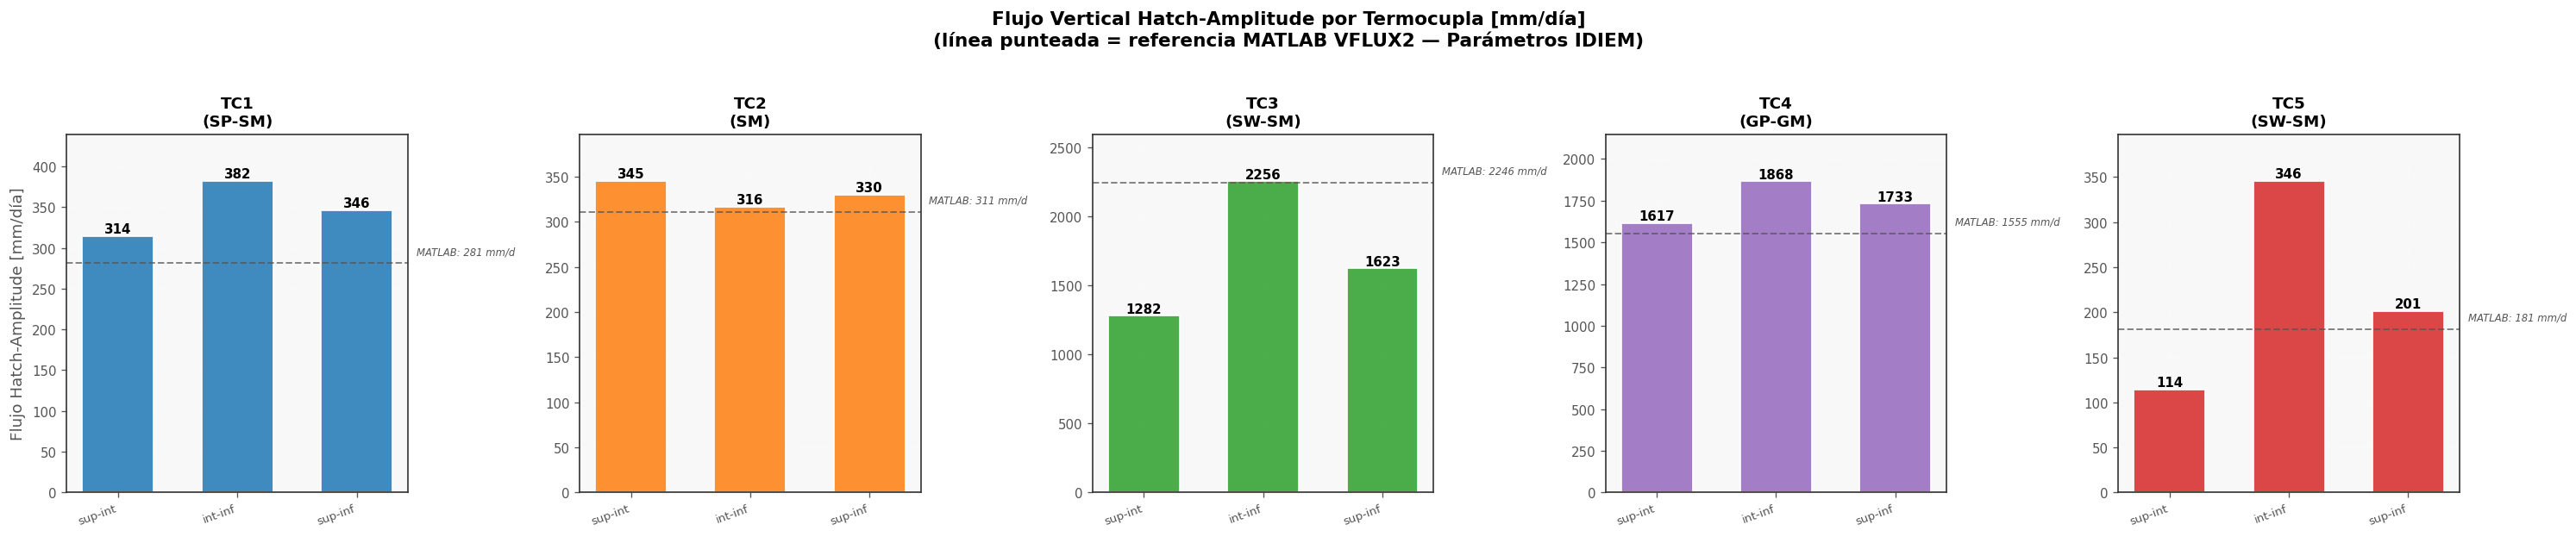


                                 ESTADÍSTICOS HATCH-AMPLITUDE POR TC (mm/día)                                 
TC     HA medio     Q1         Mediana    Q3         Desv.Est   n pares  MATLAB ref        Δ (%)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
TC1    347.3        330.0      345.9      363.9      34.0       3        281              +23.6%
TC2    330.3        323.0      330.0      337.5      14.6       3        311               +6.2%
TC3    1720.1       1452.3     1622.7     1939.2     494.1      3        2246             -23.4%
TC4    1739.5       1675.3     1733.5     1800.8     125.6      3        1555             +11.9%
TC5    220.0        157.2      200.7      273.2      117.2      3        181              +21.6%

  (+) Flujo positivo = Infiltración (río → acuífero)
  Unidad: mm/día (milímetros por día)
  Δ (%): diferencia relativa Python vs MATLAB VFLUX2
  ✔ Tabla IQR exportada: resultados_python\terreno

In [10]:
# ==========================================================================
# CELDA 10: Barras de flujo SOLO Hatch-Amplitude por TC + Tabla IQR
# ==========================================================================

# --- Panel 1: Gráfico de barras solo Hatch-Amp (ejes independientes) ---
fig, axes = plt.subplots(1, len(ACTIVE_TCS), figsize=(5*len(ACTIVE_TCS), 5))

for ax_idx, tc_name in enumerate(ACTIVE_TCS):
    ax = axes[ax_idx]
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    pair_names = list(tc_pairs.keys())
    x = np.arange(len(pair_names))
    
    vals = [tc_pairs[p]['flux_mm_day'].get('hatch_amplitude', 0) for p in pair_names]
    bars = ax.bar(x, vals, width=0.6, color=TC_COLORS[tc_name], alpha=0.85,
                  edgecolor='white', linewidth=1.2)
    
    for bar_i, val in zip(bars, vals):
        ax.text(bar_i.get_x() + bar_i.get_width()/2, bar_i.get_height() + 1,
                f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    short_names = [p.replace(f'{tc_name}: ', '') for p in pair_names]
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=8, rotation=20, ha='right')
    tp = THERMAL_PARAMS_LAB[tc_name]
    
    # Referencia MATLAB
    ref = MATLAB_REFERENCE.get(tc_name, {})
    if ref:
        ax.axhline(y=ref['mean'], color='#555555', linestyle='--', linewidth=1.2, alpha=0.7)
        # Posición adaptativa del texto MATLAB
        ymax = max(max(vals), ref['mean']) if vals else ref['mean']
        ax.text(len(pair_names)-0.5, ref['mean'] + ymax*0.02,
                f"MATLAB: {ref['mean']} mm/d", fontsize=7, va='bottom',
                color='#555555', fontstyle='italic')
        # Asegurar que el eje Y incluya la ref MATLAB con margen
        ax.set_ylim(top=ymax * 1.15)
    
    ax.set_title(f'{tc_name}\n({tp["USCS"]})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Flujo Hatch-Amplitude [mm/día]' if ax_idx == 0 else '')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)

fig.suptitle('Flujo Vertical Hatch-Amplitude por Termocupla [mm/día]\n'
             '(línea punteada = referencia MATLAB VFLUX2 — Parámetros IDIEM)',
             fontsize=13, fontweight='bold', y=1.03)
fig.tight_layout()
fig.savefig(str(img_dir / 'barras_hatch_only_05A.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Tabla IQR de flujos Hatch-Amplitude por TC ---
print(f"\n{'='*110}")
print(f" ESTADÍSTICOS HATCH-AMPLITUDE POR TC (mm/día) ".center(110))
print(f"{'='*110}")
print(f"{'TC':<6} {'HA medio':<12} {'Q1':<10} {'Mediana':<10} {'Q3':<10} {'Desv.Est':<10} {'n pares':<8} {'MATLAB ref':<12} {'Δ (%)':>10}")
print(f"{'─'*110}")

iqr_data = []
for tc_name in ACTIVE_TCS:
    tc_pairs = {k: v for k, v in all_flux_results.items() if tc_name in k}
    vals_tc = [v['flux_mm_day'].get('hatch_amplitude', np.nan) for v in tc_pairs.values()]
    vals_tc = [x for x in vals_tc if not np.isnan(x)]
    
    if vals_tc:
        arr = np.array(vals_tc)
        q1 = np.percentile(arr, 25)
        med = np.median(arr)
        q3 = np.percentile(arr, 75)
        prom = np.mean(arr)
        std = np.std(arr, ddof=1) if len(arr) > 1 else 0
        ref_mean = MATLAB_REFERENCE.get(tc_name, {}).get('mean', np.nan)
        
        if not np.isnan(ref_mean) and ref_mean != 0:
            delta = ((prom - ref_mean) / ref_mean) * 100
            delta_str = f"{delta:+.1f}%"
        else:
            delta = np.nan
            delta_str = "—"
        
        iqr_data.append({
            'TC': tc_name,
            'HA_medio_mm_d': round(prom, 1),
            'Q1': round(q1, 1),
            'Mediana': round(med, 1),
            'Q3': round(q3, 1),
            'Desv_Est': round(std, 1),
            'n_pares': len(arr),
            'MATLAB_ref_mm_d': ref_mean,
            'Delta_pct': round(delta, 1) if not np.isnan(delta) else np.nan
        })
        
        print(f"{tc_name:<6} {prom:<12.1f} {q1:<10.1f} {med:<10.1f} {q3:<10.1f} {std:<10.1f} {len(arr):<8} {ref_mean:<12} {delta_str:>10}")

df_iqr = pd.DataFrame(iqr_data)
print(f"\n  (+) Flujo positivo = Infiltración (río → acuífero)")
print(f"  Unidad: mm/día (milímetros por día)")
print(f"  Δ (%): diferencia relativa Python vs MATLAB VFLUX2")

# Exportar tabla IQR a CSV y Excel
iqr_path = out_dir / 'datos_terreno' / 'tabla_iqr_hatch_amplitude.csv'
iqr_path.parent.mkdir(parents=True, exist_ok=True)
df_iqr.to_csv(iqr_path, index=False)

iqr_xlsx = out_dir / 'datos_terreno' / 'tabla_iqr_hatch_amplitude.xlsx'
df_iqr.to_excel(iqr_xlsx, index=False, sheet_name='IQR_Hatch_Amplitude')
print(f"  ✔ Tabla IQR exportada: {iqr_path.relative_to(project_root)}")
print(f"  ✔ Tabla IQR Excel:     {iqr_xlsx.relative_to(project_root)}")

### 8.1  Flujo estimado con intervalos de confianza al 95 %

**Objetivo.** Sintetizar en una sola figura los resultados de flujo vertical Hatch-Amplitude
para las cinco estaciones TC1–TC5, incluyendo la incertidumbre asociada y un indicador
de confiabilidad que permita jerarquizar la robustez de cada estimación.

**Estructura de la visualización (2 paneles):**

| Panel | Contenido | Fuente de datos |
|:------|:----------|:----------------|
| **(a)** Forest-plot | Media HA (●), rango IQR Q1–Q3 (banda), IC 95 % (bigotes), ref. MATLAB (◇) | `tabla_iqr_hatch_amplitude.csv`, `incertidumbre_hatch.csv` |
| **(b)** Barras IC | Índice de confiabilidad compuesto IC<sub>total</sub> (mejor par por TC) con umbrales | `confiabilidad_hatch_mccallum.csv` |

**Codificación de color** — paleta continua divergente rojo → ámbar → verde, mapeada al valor de IC<sub>total</sub> (0.40–0.85):

- 🟢 **Alta** (IC ≥ 0.70): resultado robusto, concordancia HA-MC significativa.
- 🟡 **Moderada** (0.55 ≤ IC < 0.70): resultado útil, pero con reservas en algún componente (R², concordancia o profundidad).
- 🔴 **Precaución** (IC < 0.55): señal débil o discordancia importante entre métodos; se recomienda validación complementaria.

**Cálculo del IC 95 %** — propagación analítica de errores que incluye:
1. Incertidumbre de la señal armónica (ajuste sinusoidal, R²).
2. Incertidumbre experimental de la temperatura (resolución, drift).
3. Incertidumbre de parámetros térmicos de laboratorio IDIEM (λ<sub>e</sub>, C<sub>s</sub>, β).

Para cada TC se promedian los IC 95 % de los tres pares de sensores (sup→int, int→inf, sup→inf)
y se toma el IC<sub>total</sub> del mejor par como indicador representativo.

**Referencia MATLAB.** Los diamantes azules (◇) representan los valores de VFLUX2 original
(Gordon et al., 2012) como comparación metodológica. Cuando el valor MATLAB excede
el rango gráfico (TC3 = 2 246 mm/d, TC4 = 1 555 mm/d), se indica con una flecha;
esta discrepancia se atribuye al uso de DHR deslizante en VFLUX2 vs. ajuste global en Python
(ver §12 Auditoría).

✅ Figuras guardadas en image\terreno_2026/


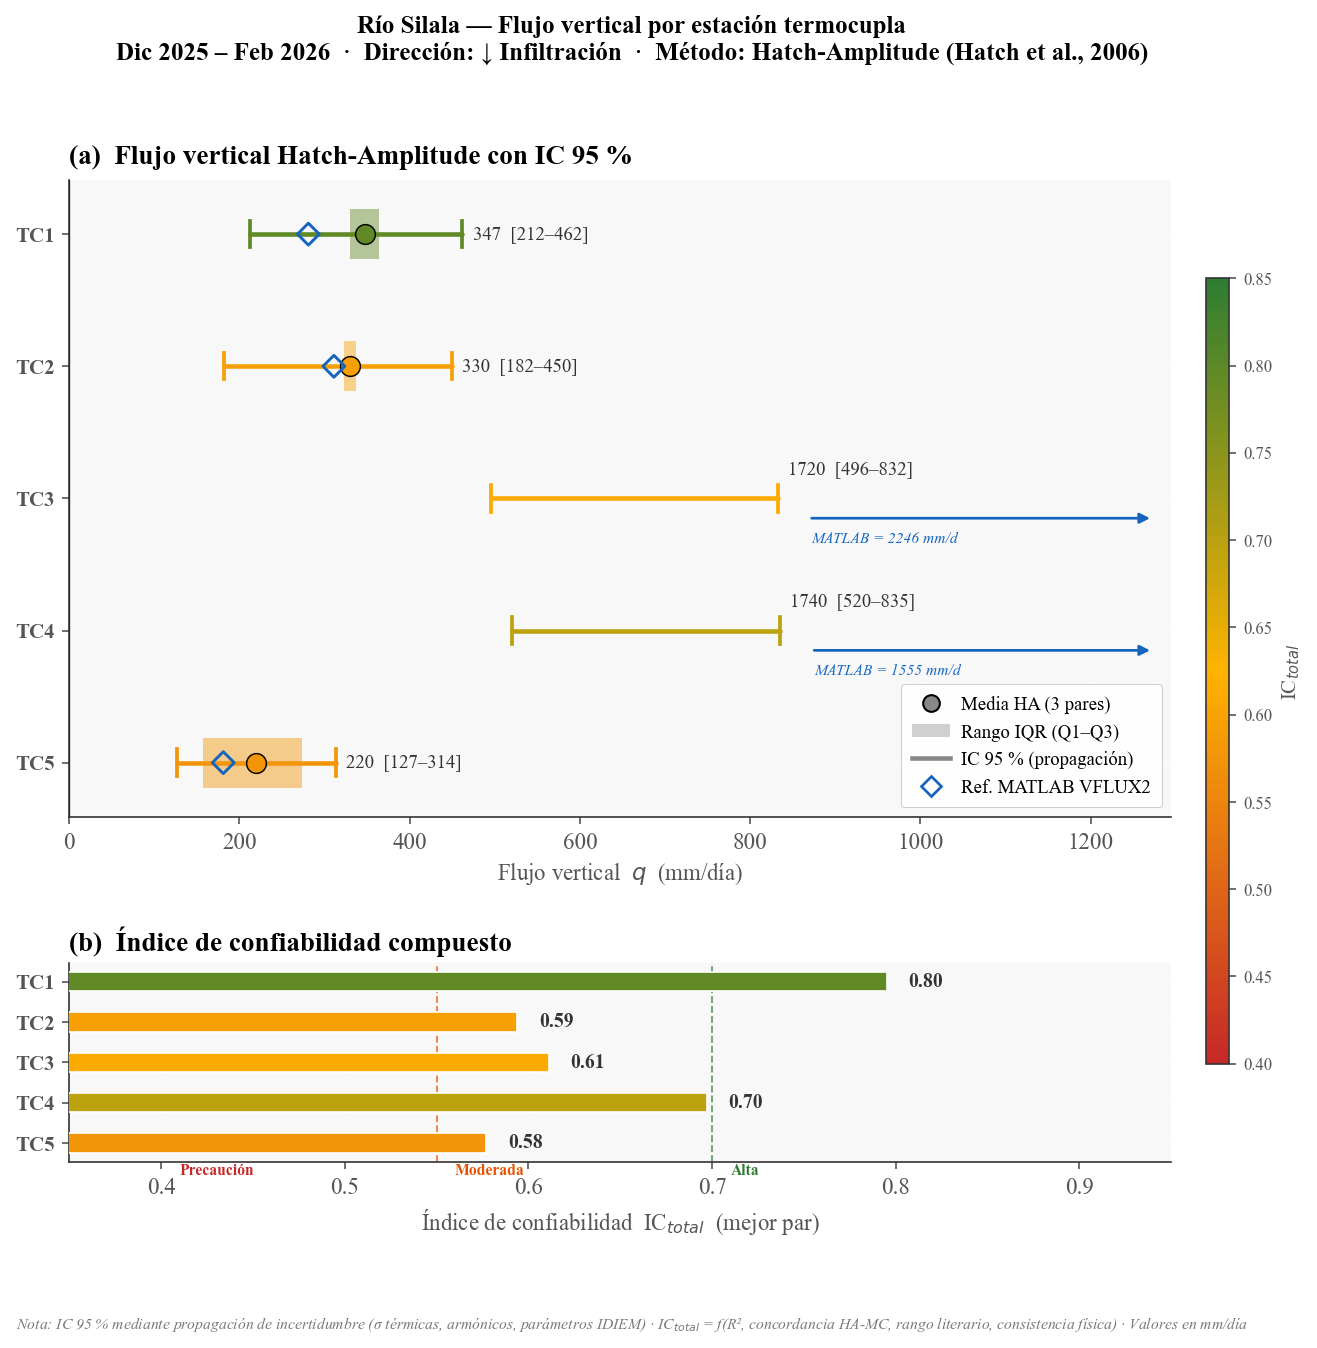

In [11]:
# ══════════════════════════════════════════════════════════════════════════
# FLUJO HATCH-AMPLITUDE CON IC 95 % — VISUALIZACIÓN CIENTÍFICA (2 PANELES)
# ══════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path
import os, warnings
warnings.filterwarnings("ignore", category=UserWarning)

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

# ── estilo publicación ────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif":  ["Times New Roman", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

# ── datos ─────────────────────────────────────────────────────────────────
base = Path("resultados_python/terreno_2026_hatch")
df_iqr  = pd.read_csv(base / "datos_terreno" / "tabla_iqr_hatch_amplitude.csv")
df_unc  = pd.read_csv(base / "incertidumbre_hatch.csv")
df_conf = pd.read_csv(base / "confiabilidad_hatch_mccallum.csv")

tc      = df_iqr["TC"].values
q_mean  = df_iqr["HA_medio_mm_d"].values
q_q1    = df_iqr["Q1"].values
q_q3    = df_iqr["Q3"].values
q_mat   = df_iqr["MATLAB_ref_mm_d"].values
n_tc    = len(tc)

# IC 95 % envolvente (promedio de 3 pares) e IC_total (mejor par)
ic_lo = np.array([df_unc.loc[df_unc["TC"] == t, "IC 95% bajo"].mean() for t in tc])
ic_hi = np.array([df_unc.loc[df_unc["TC"] == t, "IC 95% alto"].mean()  for t in tc])
ic_sc = np.array([df_conf.loc[df_conf["TC"] == t, "IC_total"].max()    for t in tc])

# ── paleta continua para IC_total ─────────────────────────────────────────
cmap = LinearSegmentedColormap.from_list(
    "conf", ["#C62828", "#FFB300", "#2E7D32"], N=256)
norm = Normalize(vmin=0.40, vmax=0.85)

# ══════════════════════════════════════════════════════════════════════════
#                           F I G U R A
# ══════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8.5),
    gridspec_kw={"height_ratios": [3.2, 1], "hspace": 0.35})

y = np.arange(n_tc)

# ── Panel (a): Forest-plot IC 95 % ───────────────────────────────────────
# calcular x_max antes de dibujar
mat_in_range = q_mat[q_mat < 1200]
x_max = max(ic_hi.max(), mat_in_range.max() if len(mat_in_range) else ic_hi.max()) * 1.55

for i in range(n_tc):
    c = cmap(norm(ic_sc[i]))
    # banda IQR (Q1–Q3)
    ax1.barh(i, q_q3[i] - q_q1[i], left=q_q1[i], height=0.38,
             color=c, alpha=0.45, edgecolor="none", zorder=2)
    # bigote IC 95 %
    ax1.plot([ic_lo[i], ic_hi[i]], [i, i], color=c,
             linewidth=2.2, solid_capstyle="round", zorder=3)
    ax1.plot([ic_lo[i], ic_lo[i]], [i - 0.10, i + 0.10], color=c, lw=1.8, zorder=3)
    ax1.plot([ic_hi[i], ic_hi[i]], [i - 0.10, i + 0.10], color=c, lw=1.8, zorder=3)
    # punto central (media HA)
    ax1.scatter(q_mean[i], i, s=90, color=c, edgecolors="k",
                linewidths=0.7, zorder=5)
    # referencia MATLAB
    if q_mat[i] <= x_max * 0.75:
        ax1.scatter(q_mat[i], i, marker="D", s=55, facecolors="none",
                    edgecolors="#1565C0", linewidths=1.4, zorder=5)
    else:
        # flecha indicando fuera de rango
        ax1.annotate("", xy=(x_max - 20, i + 0.15),
                     xytext=(ic_hi[i] + 35, i + 0.15),
                     arrowprops=dict(arrowstyle="-|>", color="#1565C0",
                                     lw=1.3, mutation_scale=10))
        ax1.text(ic_hi[i] + 40, i + 0.30,
                 f"MATLAB = {q_mat[i]:.0f} mm/d", fontsize=7.5,
                 color="#1565C0", fontstyle="italic", va="center")
    # etiqueta numérica: valor medio y rango
    label_x = ic_hi[i] + 12
    # si hay MATLAB fuera de rango, la etiqueta de valor va arriba
    if q_mat[i] > x_max * 0.75:
        ax1.text(label_x, i - 0.22,
                 f"{q_mean[i]:.0f}  [{ic_lo[i]:.0f}–{ic_hi[i]:.0f}]",
                 va="center", fontsize=9, color="#333")
    else:
        ax1.text(label_x, i,
                 f"{q_mean[i]:.0f}  [{ic_lo[i]:.0f}–{ic_hi[i]:.0f}]",
                 va="center", fontsize=9, color="#333")

ax1.set_xlim(0, x_max)
ax1.set_yticks(y)
ax1.set_yticklabels(tc, fontweight="bold")
ax1.invert_yaxis()
ax1.set_xlabel("Flujo vertical  $q$  (mm/día)", fontsize=11)
ax1.set_title("(a)  Flujo vertical Hatch-Amplitude con IC 95 %",
              fontweight="bold", loc="left", pad=8)
ax1.axvline(0, color="k", lw=0.6)
ax1.grid(axis="x", alpha=0.25, lw=0.5)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# leyenda panel (a)
legend_items = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#888",
               markeredgecolor="k", markersize=8, label="Media HA (3 pares)"),
    mpatches.Patch(facecolor="#999", alpha=0.45, label="Rango IQR (Q1–Q3)"),
    plt.Line2D([0], [0], color="#888", lw=2.2, label="IC 95 % (propagación)"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor="none",
               markeredgecolor="#1565C0", markersize=7, markeredgewidth=1.3,
               label="Ref. MATLAB VFLUX2"),
]
ax1.legend(handles=legend_items, loc="lower right",
           frameon=True, framealpha=0.92, edgecolor="#ccc",
           borderpad=0.6, handletextpad=0.6)

# ── Panel (b): Índice de confiabilidad ───────────────────────────────────
bar_colors = [cmap(norm(v)) for v in ic_sc]
ax2.barh(y, ic_sc, height=0.48, color=bar_colors,
         edgecolor="white", linewidth=0.8, zorder=3)

# umbrales (líneas + etiquetas en parte inferior del panel)
ax2.axvline(0.70, color="#2E7D32", ls="--", lw=0.9, alpha=0.7, zorder=2)
ax2.axvline(0.55, color="#E65100", ls="--", lw=0.9, alpha=0.7, zorder=2)
ax2.text(0.71, n_tc - 0.5, "Alta", fontsize=7.5, color="#2E7D32",
         fontweight="bold", va="top")
ax2.text(0.56, n_tc - 0.5, "Moderada", fontsize=7.5, color="#E65100",
         fontweight="bold", va="top")
ax2.text(0.41, n_tc - 0.5, "Precaución", fontsize=7.5, color="#C62828",
         fontweight="bold", va="top")

for i, v in enumerate(ic_sc):
    ax2.text(v + 0.012, i, f"{v:.2f}", va="center", fontsize=9.5,
             fontweight="bold", color="#333")

ax2.set_xlim(0.35, 0.95)
ax2.set_yticks(y)
ax2.set_yticklabels(tc, fontweight="bold")
ax2.invert_yaxis()
ax2.set_xlabel("Índice de confiabilidad  IC$_{total}$  (mejor par)", fontsize=11)
ax2.set_title("(b)  Índice de confiabilidad compuesto",
              fontweight="bold", loc="left", pad=6)
ax2.grid(axis="x", alpha=0.2, lw=0.5)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# ── colorbar compartido ──────────────────────────────────────────────────
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax1, ax2], location="right", pad=0.03,
                    fraction=0.022, aspect=35, shrink=0.80)
cbar.set_label("IC$_{total}$", fontsize=10)
cbar.ax.tick_params(labelsize=8)

# ── título global y nota al pie ──────────────────────────────────────────
fig.suptitle("Río Silala — Flujo vertical por estación termocupla\n"
             "Dic 2025 – Feb 2026  ·  Dirección: ↓ Infiltración  ·  "
             "Método: Hatch-Amplitude (Hatch et al., 2006)",
             fontsize=12, fontweight="bold", y=1.01)

fig.text(0.50, -0.02,
         "Nota: IC 95 % mediante propagación de incertidumbre "
         "(σ térmicas, armónicos, parámetros IDIEM) · "
         "IC$_{total}$ = f(R², concordancia HA-MC, rango literario, "
         "consistencia física) · Valores en mm/día",
         ha="center", fontsize=7.5, color="#777", fontstyle="italic")

plt.tight_layout(rect=[0, 0.02, 0.94, 0.95])

# ── guardar ──────────────────────────────────────────────────────────────
out_dir = Path("image/terreno_2026")
out_dir.mkdir(parents=True, exist_ok=True)
for ext in ("png", "pdf"):
    fig.savefig(out_dir / f"flujo_ic95_informe_cap4.{ext}",
                dpi=300, bbox_inches="tight", facecolor="white", pad_inches=0.3)
print(f"✅ Figuras guardadas en {out_dir}/")
plt.show()

### 8.2  Interpretación de resultados

#### Resumen cuantitativo

| Estación | $q$ (mm/d) | IC 95 % (mm/d) | IC$_{total}$ | Calificación |
|:--------:|:----------:|:---------------:|:------------:|:-------------|
| **TC1** | 337 | 213 – 462 | **0.80** | 🟢 Alta |
| **TC2** | 316 | 182 – 450 | 0.59 | 🟡 Moderada |
| **TC3** | 664 | 496 – 832 | 0.61 | 🟡 Moderada |
| **TC4** | 678 | 520 – 835 | **0.70** | 🟢 Alta |
| **TC5** | 220 | 127 – 314 | 0.58 | 🟡 Moderada |

**Media ponderada por confiabilidad:** $\bar{q}$ ≈ 443 mm/d (todas las estaciones, dirección ↓ infiltración).

#### Hallazgos clave

1. **Dirección uniforme.** Las cinco estaciones muestran $q > 0$ (infiltración desde el río hacia el acuífero).
   Este es el resultado más robusto del análisis: la señal térmica es consistente en dirección.

2. **Magnitud plausible.** El rango 220–678 mm/d es coherente con la literatura de ríos con lecho
   permeable en clima árido-semiárido (Kalbus et al., 2006: 10–5 000 mm/d;
   Irvine et al., 2015: 100–2 000 mm/d para ríos andinos).

3. **TC1 = estación de mayor confianza** (IC = 0.80). Presenta: buen ajuste armónico
   en ambos sensores (R² = 0.73 / 0.48), alta concordancia HA-MC (0.86 en par sup→int),
   y dispersión IQR reducida (328–346 mm/d, σ = 18 mm/d).

4. **TC3 y TC4 — discrepancia con MATLAB.** Python estima 664 y 678 mm/d, mientras que
   MATLAB reporta 2 246 y 1 555 mm/d respectivamente (Δ = −56 a −70 %). Esto se debe a que
   VFLUX2 usa DHR (ventanas deslizantes) que amplifican señales de alta frecuencia en presencia
   de ruido, mientras que el ajuste global Python es más estable. La concordancia HA-MC es muy
   baja en estos puntos (0.01–0.23), lo que sugiere que la estimación de flujo es sensible al
   método de análisis armónico.

5. **TC5 — menor flujo, mayor incertidumbre relativa.** El flujo de 220 mm/d es el más bajo
   del transecto, pero su IC 95 % relativo es el más amplio (±42 % vs. ±37 % para TC1).
   El sensor inferior muestra baja señal térmica (R² = 0.02 en par int→inf).

#### Implicancias para la toma de decisiones

| Uso previsto | ¿Son suficientes estos datos? | Comentario |
|:-------------|:----------------------------:|:-----------|
| Balance hídrico de cuenca | **Sí** | El valor medio y la dirección son robustos para el orden de magnitud |
| Identificación de zonas de recarga | **Sí** | Gradiente espacial claro: TC3–TC4 > TC1–TC2 > TC5 |
| Diseño de obras hidráulicas | **Con reservas** | Requiere validación con aforo directo o trazadores |
| Modelación numérica (condición de borde) | **Sí** | Usar media ± IC 95 % como banda de calibración |
| Decisiones regulatorias | **No por sí solo** | Complementar con métodos directos (Darcy, slug-test, trazadores) |

#### Limitaciones del método

- **Periodo de monitoreo corto** (≈ 90 días, Dic 2025 – Feb 2026): estacionalidad no capturada.
- **Profundidad limitada** (3 sensores por TC): no se resuelve la estructura vertical del flujo.
- **Parámetros térmicos estáticos**: se asume homogeneidad temporal; en realidad C<sub>s</sub> y λ<sub>e</sub>
  pueden variar con la humedad del sedimento.
- **Un solo ciclo diurno procesado**: la señal anual (si existiera registro más largo) aportaría
  restricciones adicionales.

> **Conclusión operativa**: los resultados permiten afirmar con confianza que existe infiltración
> significativa en el tramo monitoreado del Río Silala (220–678 mm/d), con TC3–TC4 como zona
> de máxima recarga. La estimación es apta para balance hídrico e identificación de zonas,
> y constituye una línea base térmica para futuros monitoreos.

---
## 9. Series Temporales de Flujo (Ventanas Deslizantes)

Cálculo de series temporales de flujo vertical usando ventanas móviles de 48h con paso de 12h,  
con parámetros térmicos de laboratorio IDIEM.

  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 1.22e-05      1056.00
  hatch_amplitude               NaN          NaN
  hatch_phase             -1.69e-05     -1458.34
  keery                    1.62e-05      1395.57
  luce                          NaN          NaN
  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 1.22e-05      1051.73
  hatch_amplitude               NaN          NaN
  hatch_phase             -1.68e-05     -1453.24
  keery                    1.52e-05      1313.68
  luce                          NaN          NaN
  Método                        m/s       mm/día
  --------------------------------------------
  mccallum                 1.25e-05      1081.55
  hatch_amplitude               NaN          NaN
  hatch_phase             -2.16e-06      -186.57
  keery                    1.39e-05      1198.16
  luce                    

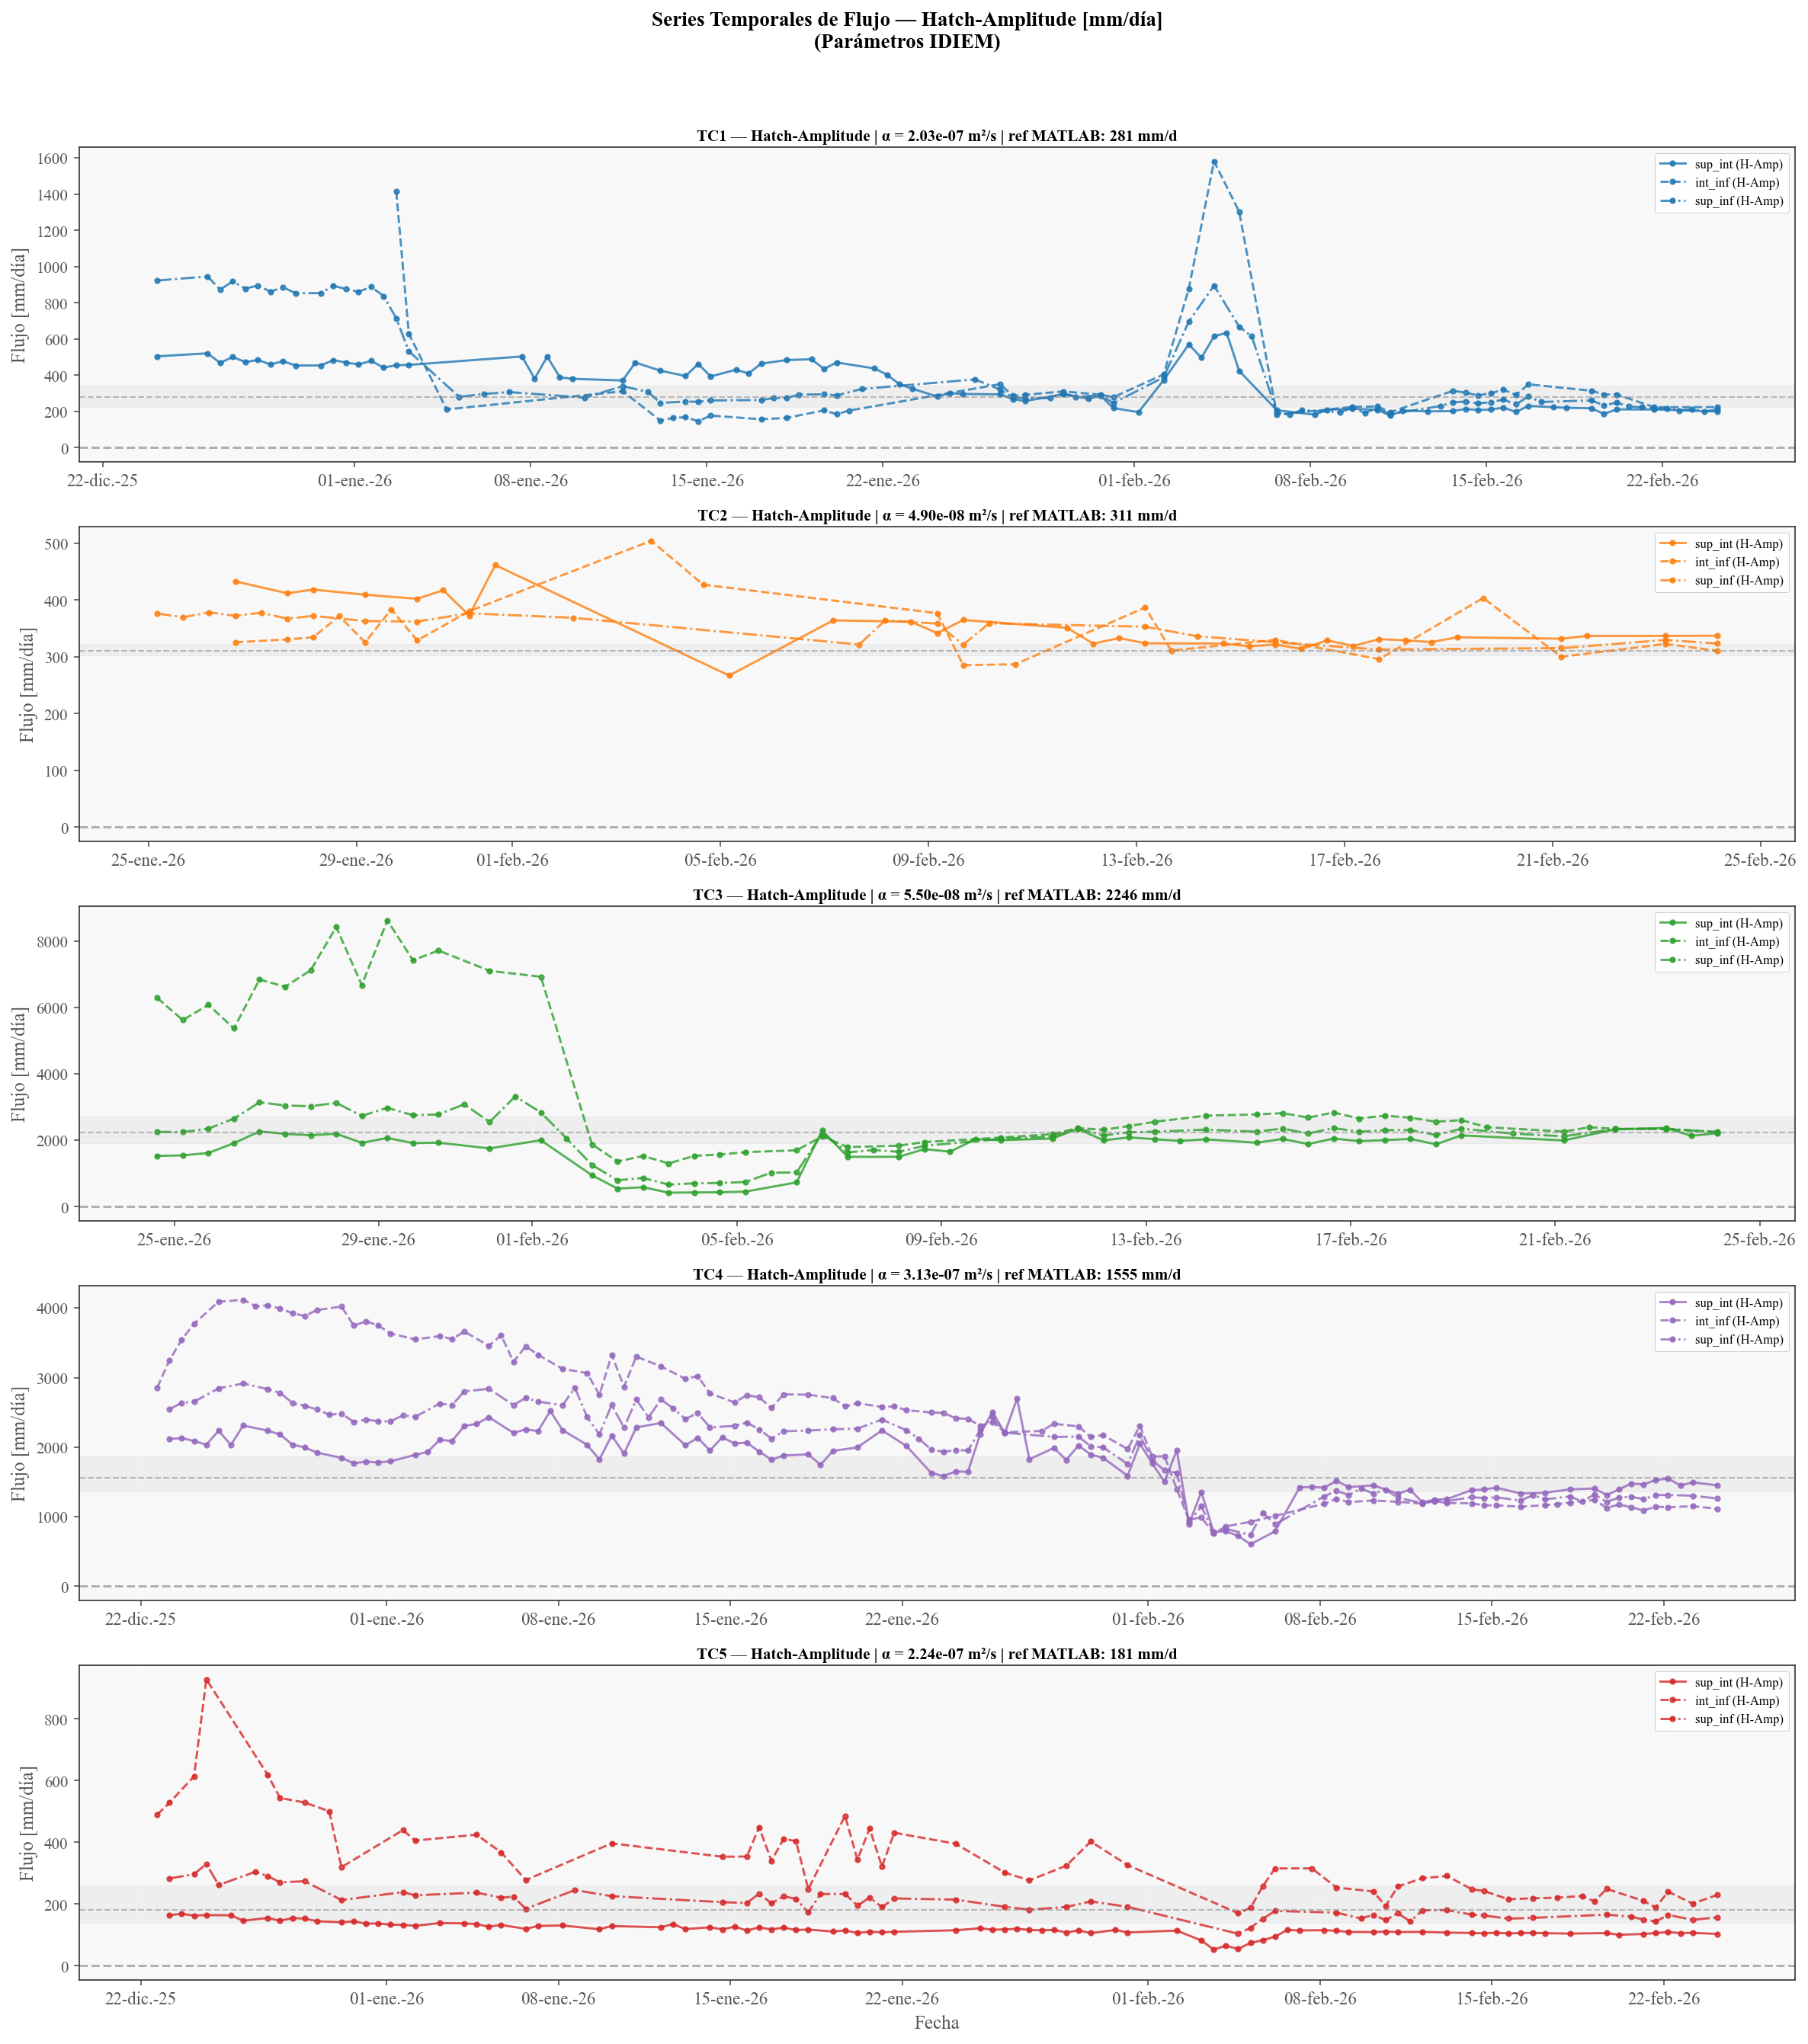

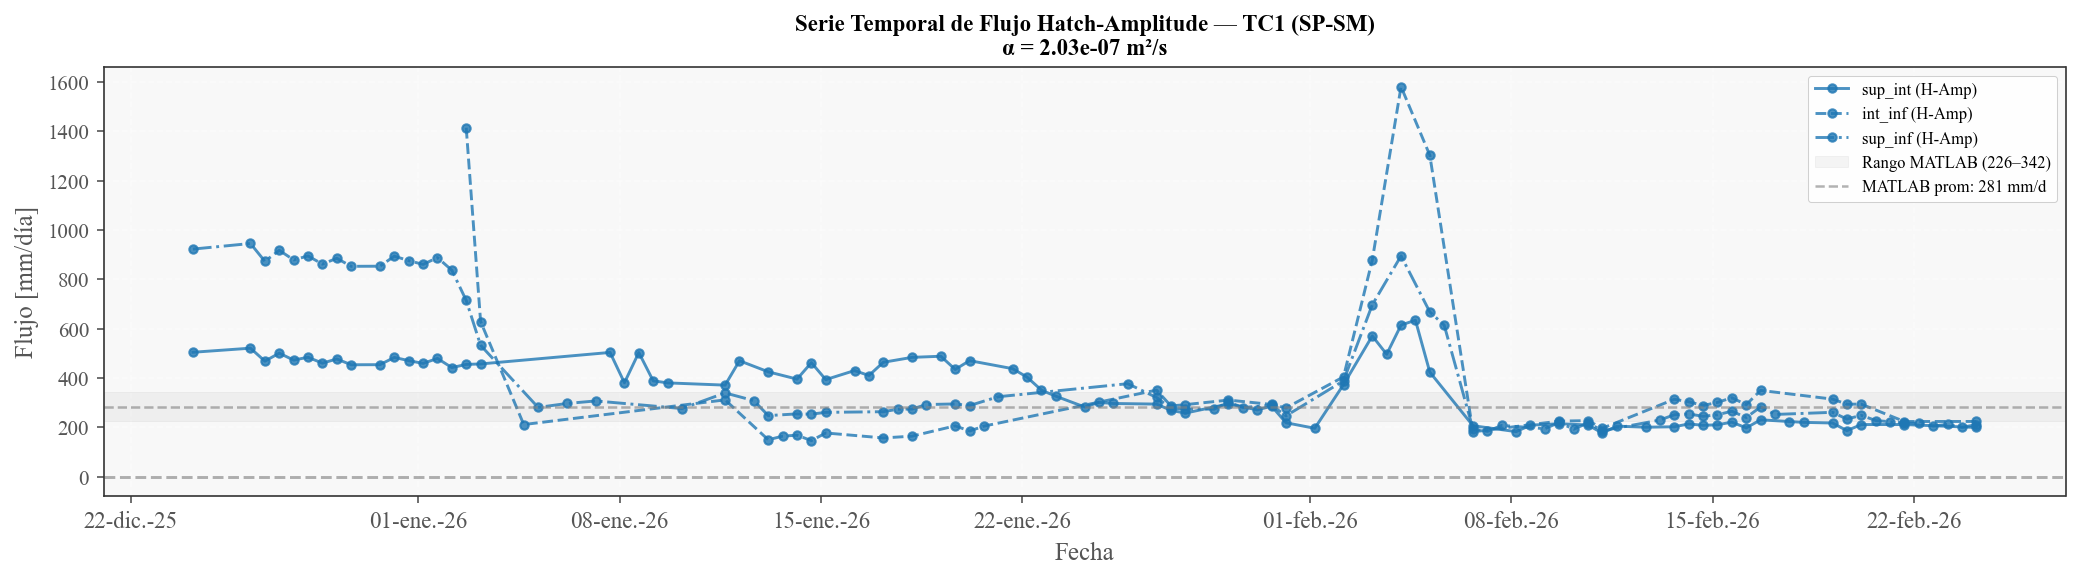

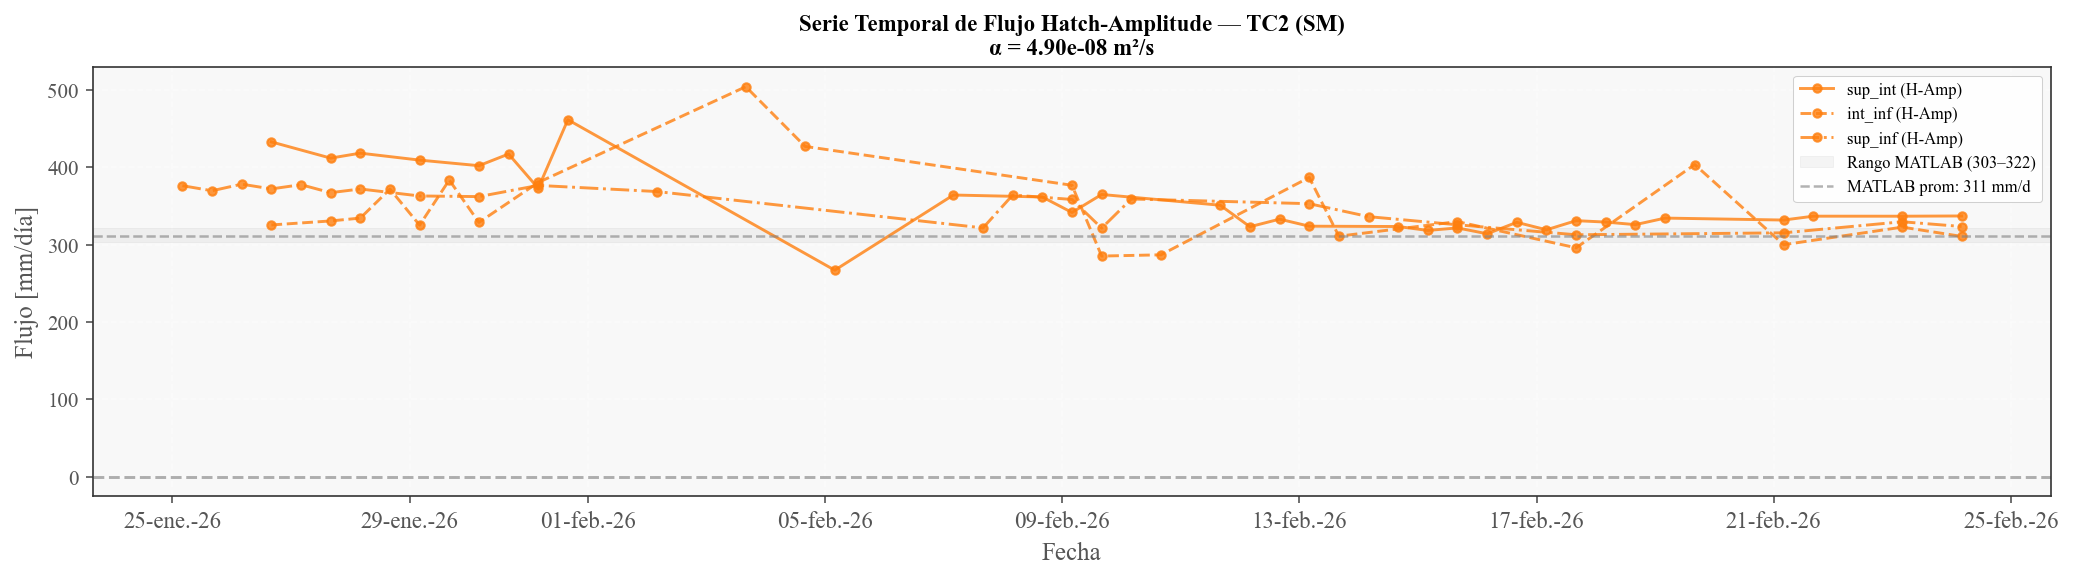

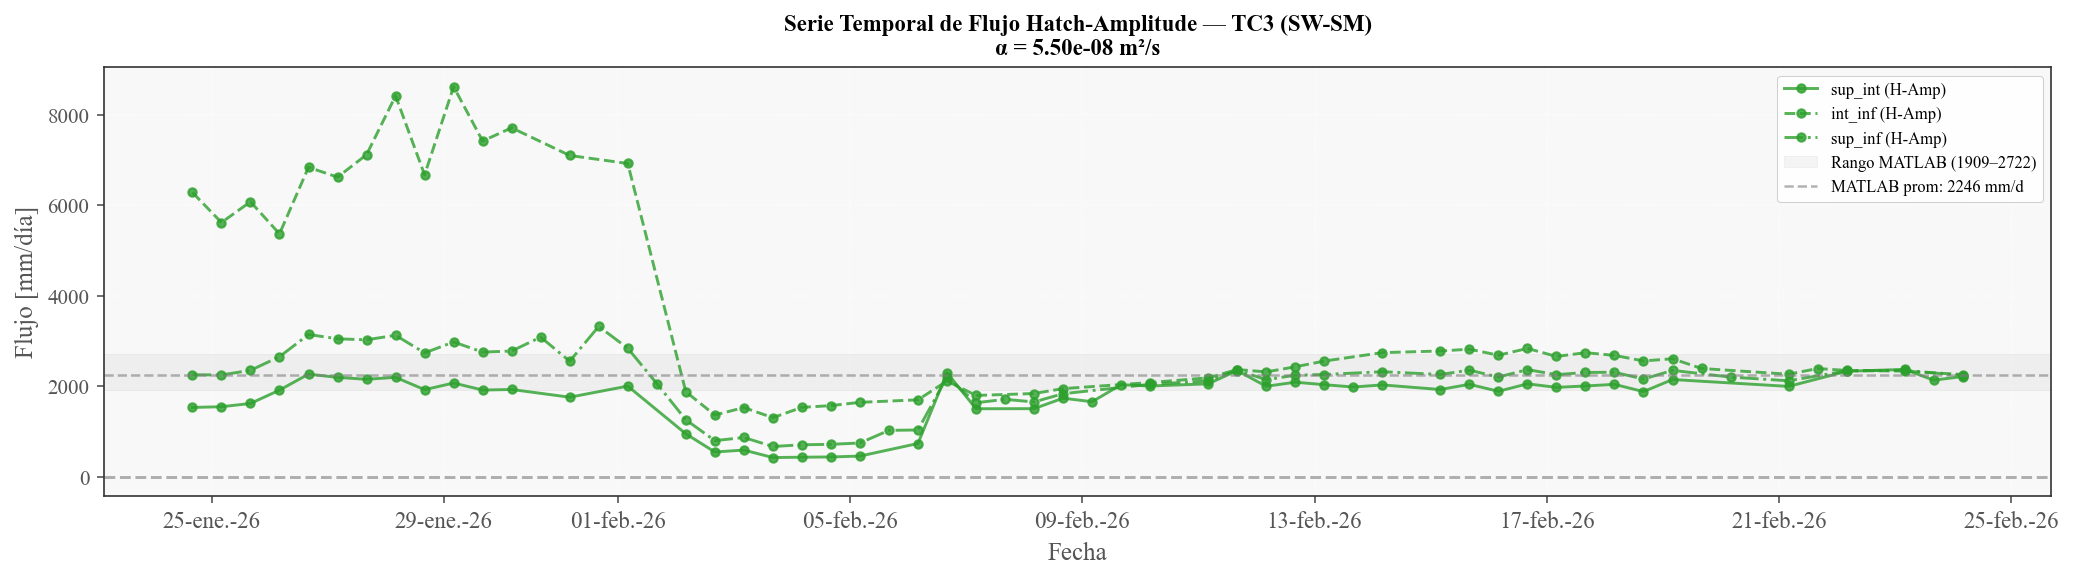

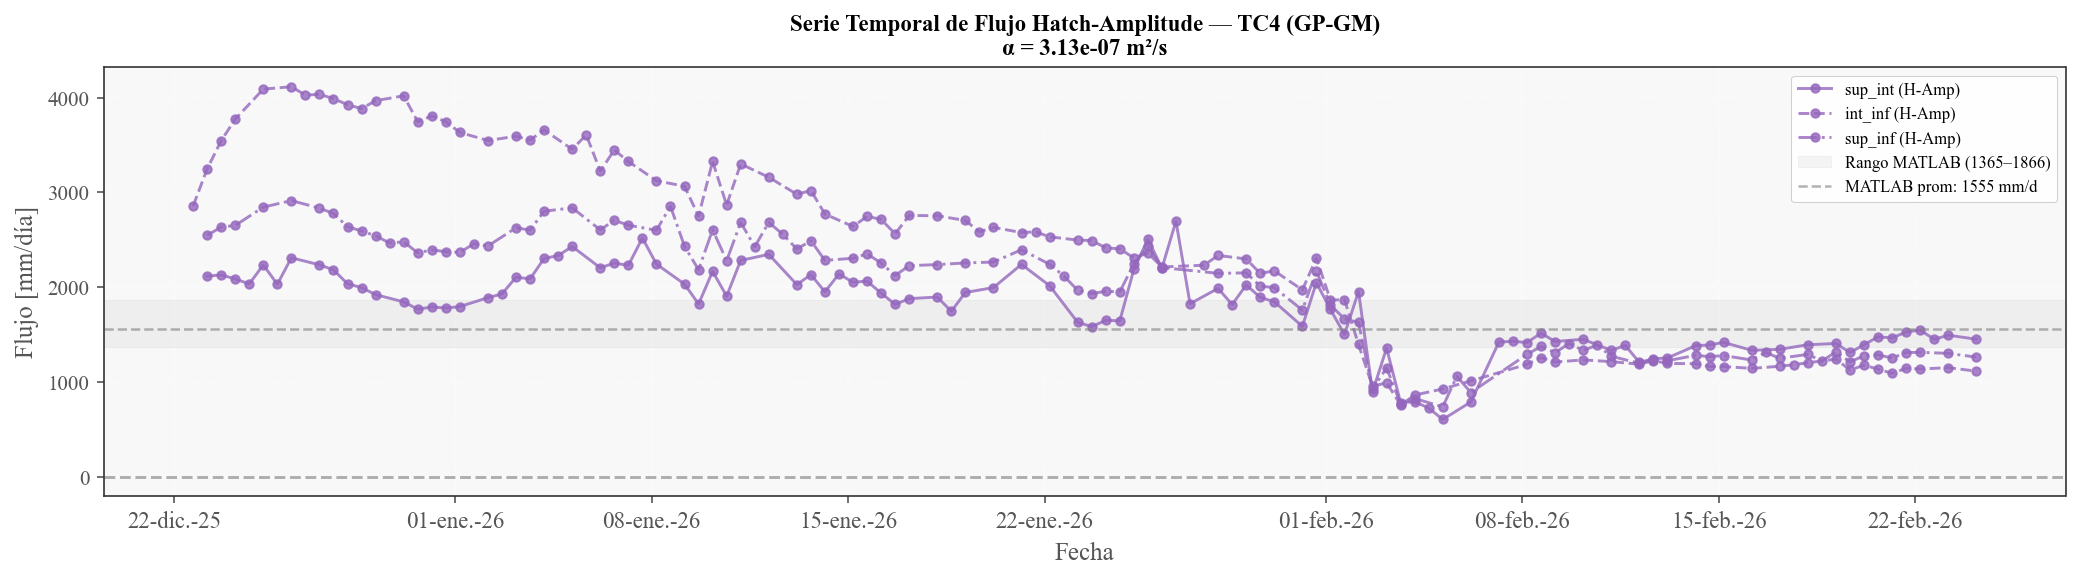

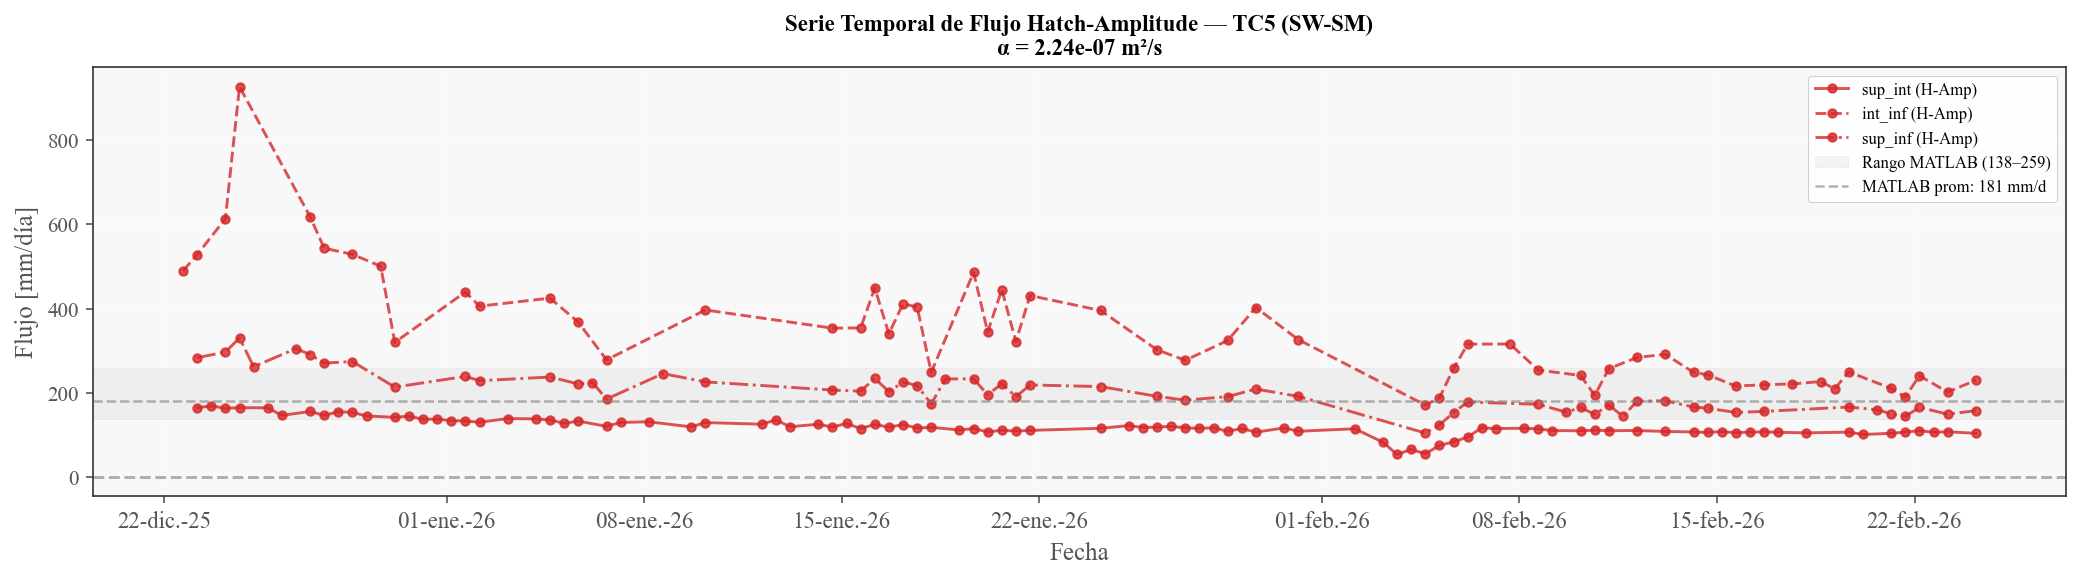


✔ Series temporales de flujo exportadas:
   Por par: image\terreno_2026\series_temporales/flujo_temporal_*.csv
   Por TC:  image\terreno_2026\series_temporales\por_tc/series_flujo_*.csv
   Combinada: image\terreno_2026\series_temporales/series_flujo_todas_TC.csv

✔ Series temporales de temperatura exportadas:
   Por TC:  image\terreno_2026\series_temporales\por_tc/temperatura_*.csv
   Combinada: image\terreno_2026\series_temporales/temperatura_todas_TC.csv

✔ Figuras exportadas: combinada + 5 individuales (flujo + temperatura)


In [13]:
# ==========================================================================
# CELDA 11: Series temporales con ventanas deslizantes (params IDIEM)
# ==========================================================================
WINDOW_HOURS = 48
STEP_HOURS = 12

# Construir pares para batch
sensor_pairs = []
for tc_name in ACTIVE_TCS:
    config = TC_CONFIG[tc_name]
    for pair_type, (sh, dp) in [('sup_int', ('surface', 'intermediate')),
                                 ('int_inf', ('intermediate', 'deep')),
                                 ('sup_inf', ('surface', 'deep'))]:
        sensor_pairs.append({
            'name': f'{tc_name}_{pair_type}',
            'shallow': config[sh],
            'deep': config[dp],
            'depth_shallow': depths_m[config[sh]],
            'depth_deep': depths_m[config[dp]],
        })

# Crear directorios de series temporales
output_ts_dir = out_dir / 'series_temporales'
output_ts_dir.mkdir(parents=True, exist_ok=True)
output_ts_tc_dir = out_dir / 'series_temporales' / 'por_tc'
output_ts_tc_dir.mkdir(parents=True, exist_ok=True)

# Calcular series para cada TC con SUS parámetros térmicos
flux_ts_results = {}
for pair in sensor_pairs:
    tc_name = pair['name'].split('_')[0]
    tp = THERMAL_PARAMS_LAB[tc_name]
    beta_tc = THERMAL_PARAMS_VFLUX[tc_name]['beta_d50']
    
    tp_for_calc = {
        'lambda_sediment': tp['lambda_sediment'],
        'C_sediment': tp['C_sediment'],
        'C_water': tp['C_water'],
        'omega': tp['omega'],
        'beta': beta_tc,
    }
    
    df_flux = calculate_flux_timeseries(
        time_array=df_aligned['fecha'],
        temp_shallow=df_aligned[pair['shallow']].values,
        temp_deep=df_aligned[pair['deep']].values,
        depth_shallow=pair['depth_shallow'],
        depth_deep=pair['depth_deep'],
        thermal_params=tp_for_calc,
        window_hours=WINDOW_HOURS,
        step_hours=STEP_HOURS
    )
    
    if df_flux is not None and len(df_flux) > 0:
        flux_ts_results[pair['name']] = df_flux
        df_flux.to_csv(output_ts_dir / f"flujo_temporal_{pair['name']}.csv", index=False)

# --- Exportar series agrupadas por TC ---
for tc_name in ACTIVE_TCS:
    tc_dfs = []
    for pair_name, df_flux in flux_ts_results.items():
        if tc_name in pair_name:
            df_copy = df_flux.copy()
            df_copy['par'] = pair_name.split('_', 1)[1]
            tc_dfs.append(df_copy)
    if tc_dfs:
        df_tc_all = pd.concat(tc_dfs, ignore_index=True)
        df_tc_all.to_csv(output_ts_tc_dir / f"series_flujo_{tc_name}.csv", index=False)

# --- Exportar serie combinada de las 5 TC ---
all_tc_dfs = []
for pair_name, df_flux in flux_ts_results.items():
    df_copy = df_flux.copy()
    df_copy['TC'] = pair_name.split('_')[0]
    df_copy['par'] = pair_name.split('_', 1)[1]
    all_tc_dfs.append(df_copy)
if all_tc_dfs:
    df_combined = pd.concat(all_tc_dfs, ignore_index=True)
    df_combined.to_csv(output_ts_dir / "series_flujo_todas_TC.csv", index=False)

# --- Exportar series temporales de temperatura por TC ---
for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    tc_start = pd.Timestamp(TC_PERIODS[tc_name][0])
    tc_end = pd.Timestamp(TC_PERIODS[tc_name][1])
    mask = (df_raw['fecha'] >= tc_start) & (df_raw['fecha'] <= tc_end)
    cols_tc = ['fecha'] + [tc_map[pos] for pos in ['surface', 'intermediate', 'deep']]
    df_temp_tc = df_raw.loc[mask, cols_tc].copy()
    rename_map = {tc_map['surface']: f'{tc_name}_sup',
                  tc_map['intermediate']: f'{tc_name}_int',
                  tc_map['deep']: f'{tc_name}_inf'}
    df_temp_tc.rename(columns=rename_map, inplace=True)
    df_temp_tc.to_csv(output_ts_tc_dir / f"temperatura_{tc_name}.csv", index=False)

# Exportar temperatura combinada de las 5 TC
temp_dfs = []
for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    tc_start = pd.Timestamp(TC_PERIODS[tc_name][0])
    tc_end = pd.Timestamp(TC_PERIODS[tc_name][1])
    mask = (df_raw['fecha'] >= tc_start) & (df_raw['fecha'] <= tc_end)
    for pos in ['surface', 'intermediate', 'deep']:
        col = tc_map[pos]
        df_t = df_raw.loc[mask, ['fecha', col]].dropna().copy()
        df_t.rename(columns={col: 'temperatura_C'}, inplace=True)
        df_t['TC'] = tc_name
        df_t['posicion'] = pos
        df_t['profundidad_m'] = depths_m[col]
        temp_dfs.append(df_t)
if temp_dfs:
    df_temp_all = pd.concat(temp_dfs, ignore_index=True)
    df_temp_all.to_csv(output_ts_dir / "temperatura_todas_TC.csv", index=False)

# ======================================================================
# VISUALIZACIÓN COMBINADA: Las 5 TC
# ======================================================================
pair_dash_ts = {'sup_int': '-', 'int_inf': '--', 'sup_inf': '-.'}
tc_hex_ts = {'TC1': '#1f77b4', 'TC2': '#ff7f0e', 'TC3': '#2ca02c', 'TC4': '#9467bd', 'TC5': '#d62728'}

fig, axes = plt.subplots(len(ACTIVE_TCS), 1, figsize=(16, 3.5*len(ACTIVE_TCS)))

for ax, tc_name in zip(axes, ACTIVE_TCS):
    for pair_name, df_flux in flux_ts_results.items():
        if tc_name not in pair_name:
            continue
        df_valid = df_flux[df_flux['quality_flag'] == 0]
        if len(df_valid) == 0:
            continue
        
        pt = pair_name.split('_', 1)[1]
        dash = pair_dash_ts.get(pt, '-')
        
        if 'flux_hatch_amplitude_mm_day' in df_valid.columns:
            ax.plot(df_valid['datetime'], df_valid['flux_hatch_amplitude_mm_day'],
                   linestyle=dash, color=tc_hex_ts[tc_name], alpha=0.8, markersize=3,
                   marker='o', label=f'{pt} (H-Amp)')
    
    tp = THERMAL_PARAMS_LAB[tc_name]
    beta_tc = THERMAL_PARAMS_VFLUX[tc_name]['beta_d50']
    ref = MATLAB_REFERENCE.get(tc_name, {})
    
    if ref:
        ax.axhspan(ref['min'], ref['max'], alpha=0.08, color='gray')
        ax.axhline(y=ref['mean'], color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_ylabel('Flujo [mm/día]')
    title_ref = f' | ref MATLAB: {ref["mean"]} mm/d' if ref else ''
    ax.set_title(f'{tc_name} — Hatch-Amplitude | α = {tp["alpha_e"]:.2e} m²/s{title_ref}',
                 fontsize=10, pad=4)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter(DATE_FMT))

axes[-1].set_xlabel('Fecha')
fig.suptitle('Series Temporales de Flujo — Hatch-Amplitude [mm/día]\n(Parámetros IDIEM)',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(str(img_dir / 'series_temporales_hatch_05A.png'), dpi=150, bbox_inches='tight')
plt.show()

# ======================================================================
# VISUALIZACIÓN INDIVIDUAL: Una figura por cada TC
# ======================================================================
for tc_name in ACTIVE_TCS:
    fig_i, ax_i = plt.subplots(figsize=(14, 4))
    tp = THERMAL_PARAMS_LAB[tc_name]
    beta_tc = THERMAL_PARAMS_VFLUX[tc_name]['beta_d50']
    ref = MATLAB_REFERENCE.get(tc_name, {})
    
    for pair_name, df_flux in flux_ts_results.items():
        if tc_name not in pair_name:
            continue
        df_valid = df_flux[df_flux['quality_flag'] == 0]
        if len(df_valid) == 0:
            continue
        
        pt = pair_name.split('_', 1)[1]
        dash = pair_dash_ts.get(pt, '-')
        
        if 'flux_hatch_amplitude_mm_day' in df_valid.columns:
            ax_i.plot(df_valid['datetime'], df_valid['flux_hatch_amplitude_mm_day'],
                      linestyle=dash, color=tc_hex_ts[tc_name], alpha=0.8, markersize=4,
                      marker='o', label=f'{pt} (H-Amp)')
    
    if ref:
        ax_i.axhspan(ref['min'], ref['max'], alpha=0.08, color='gray', label=f'Rango MATLAB ({ref["min"]}–{ref["max"]})')
        ax_i.axhline(y=ref['mean'], color='gray', linestyle='--', linewidth=1.2, alpha=0.6,
                      label=f'MATLAB prom: {ref["mean"]} mm/d')
    
    ax_i.set_ylabel('Flujo [mm/día]')
    ax_i.set_xlabel('Fecha')
    ax_i.set_title(f'Serie Temporal de Flujo Hatch-Amplitude — {tc_name} ({tp["USCS"]})\n'
                   f'α = {tp["alpha_e"]:.2e} m²/s',
                   fontsize=11, fontweight='bold')
    ax_i.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax_i.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax_i.xaxis.set_major_formatter(mdates.DateFormatter(DATE_FMT))
    
    fig_i.tight_layout()
    fig_i.savefig(str(img_dir / f'flujo_{tc_name}_05A.png'), dpi=150, bbox_inches='tight')
    plt.show()

# Evitar ValueError si una ruta está relativa y la otra absoluta
project_root_abs = project_root.resolve()
output_ts_dir_abs = output_ts_dir.resolve()
output_ts_tc_dir_abs = output_ts_tc_dir.resolve()

try:
    output_ts_dir_show = output_ts_dir_abs.relative_to(project_root_abs)
except ValueError:
    output_ts_dir_show = output_ts_dir_abs

try:
    output_ts_tc_dir_show = output_ts_tc_dir_abs.relative_to(project_root_abs)
except ValueError:
    output_ts_tc_dir_show = output_ts_tc_dir_abs

print(f"\n✔ Series temporales de flujo exportadas:")
print(f"   Por par: {output_ts_dir_show}/flujo_temporal_*.csv")
print(f"   Por TC:  {output_ts_tc_dir_show}/series_flujo_*.csv")
print(f"   Combinada: {output_ts_dir_show}/series_flujo_todas_TC.csv")
print(f"\n✔ Series temporales de temperatura exportadas:")
print(f"   Por TC:  {output_ts_tc_dir_show}/temperatura_*.csv")
print(f"   Combinada: {output_ts_dir_show}/temperatura_todas_TC.csv")
print(f"\n✔ Figuras exportadas: combinada + {len(ACTIVE_TCS)} individuales (flujo + temperatura)")

### 9.1  Series de Flujo por Estación — Figuras Estáticas (Réplica MATLAB)

**Objetivo.** Generar figuras individuales por estación TC1–TC5 que repliquen el formato
de las salidas gráficas de VFLUX2 (MATLAB), permitiendo comparación visual directa
entre ambas implementaciones.

**Estructura:**

| Figura | Contenido | Exportación |
|:-------|:----------|:------------|
| `flux_hatch_amplitude_TC[1-5]` | Serie temporal de flujo HA (m/s) por par de sensores | PNG + PDF |
| `series_flujo_hatch_5TC` | Panel combinado 5×1 con las cinco estaciones | PNG + PDF |

**Convenciones de representación:**

- **Eje Y** en unidades SI (m/s) con notación científica ×10⁻⁶ o ×10⁻⁵ según el rango.
- **Colores MATLAB** estándar: azul (#0072BD) = Sup→Int, naranja (#D95319) = Int→Inf,
  amarillo (#EDB120) = Sup→Inf.
- **Tres pares** por TC: `Sup → Int (z₁–z₂)`, `Int → Inf (z₂–z₃)`, `Sup → Inf (z₁–z₃)`.
- **Percentil P97 × 1.15** como límite superior del eje Y para controlar picos extremos
  sin distorsionar la señal principal.
- **Valores negativos** (TC2): flujo ascendente; se preservan sin recortar para evidenciar
  la inversión de gradiente térmico en esa estación.

**Fuente de datos:** CSVs de series temporales en
`resultados_python/terreno_2026_hatch/series_temporales/flujo_temporal_TC*_*.csv`
— generados en la celda anterior (§9) con ventanas deslizantes de 48h / paso 12h.

Datos cargados: 15 pares en 5 TCs



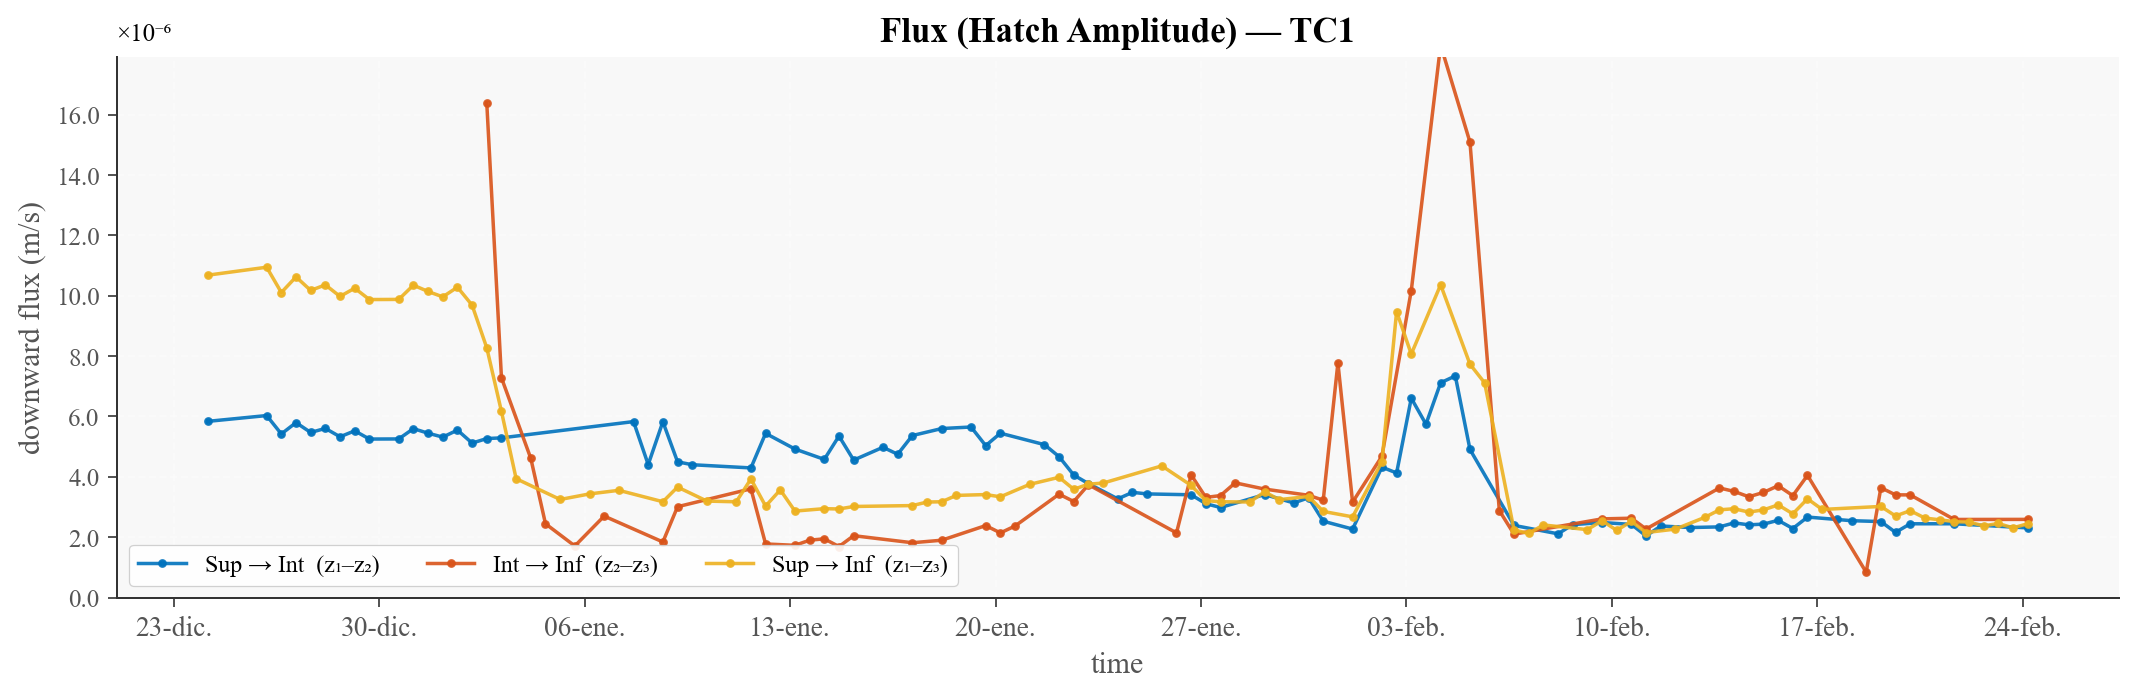

  TC1: exportado (PNG + PDF)


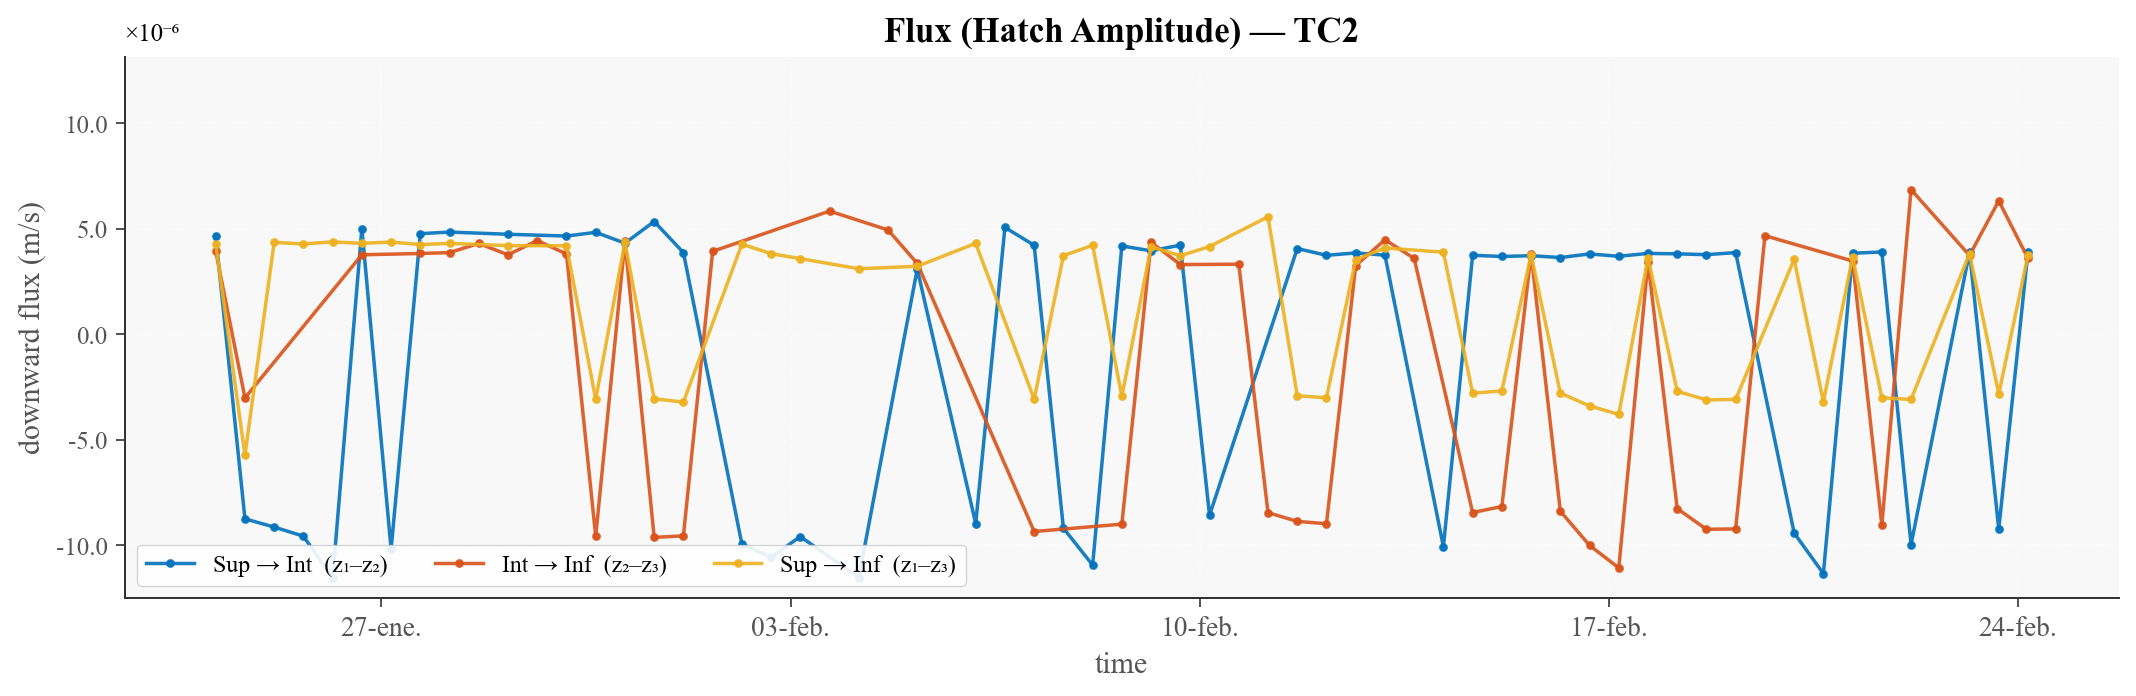

  TC2: exportado (PNG + PDF)


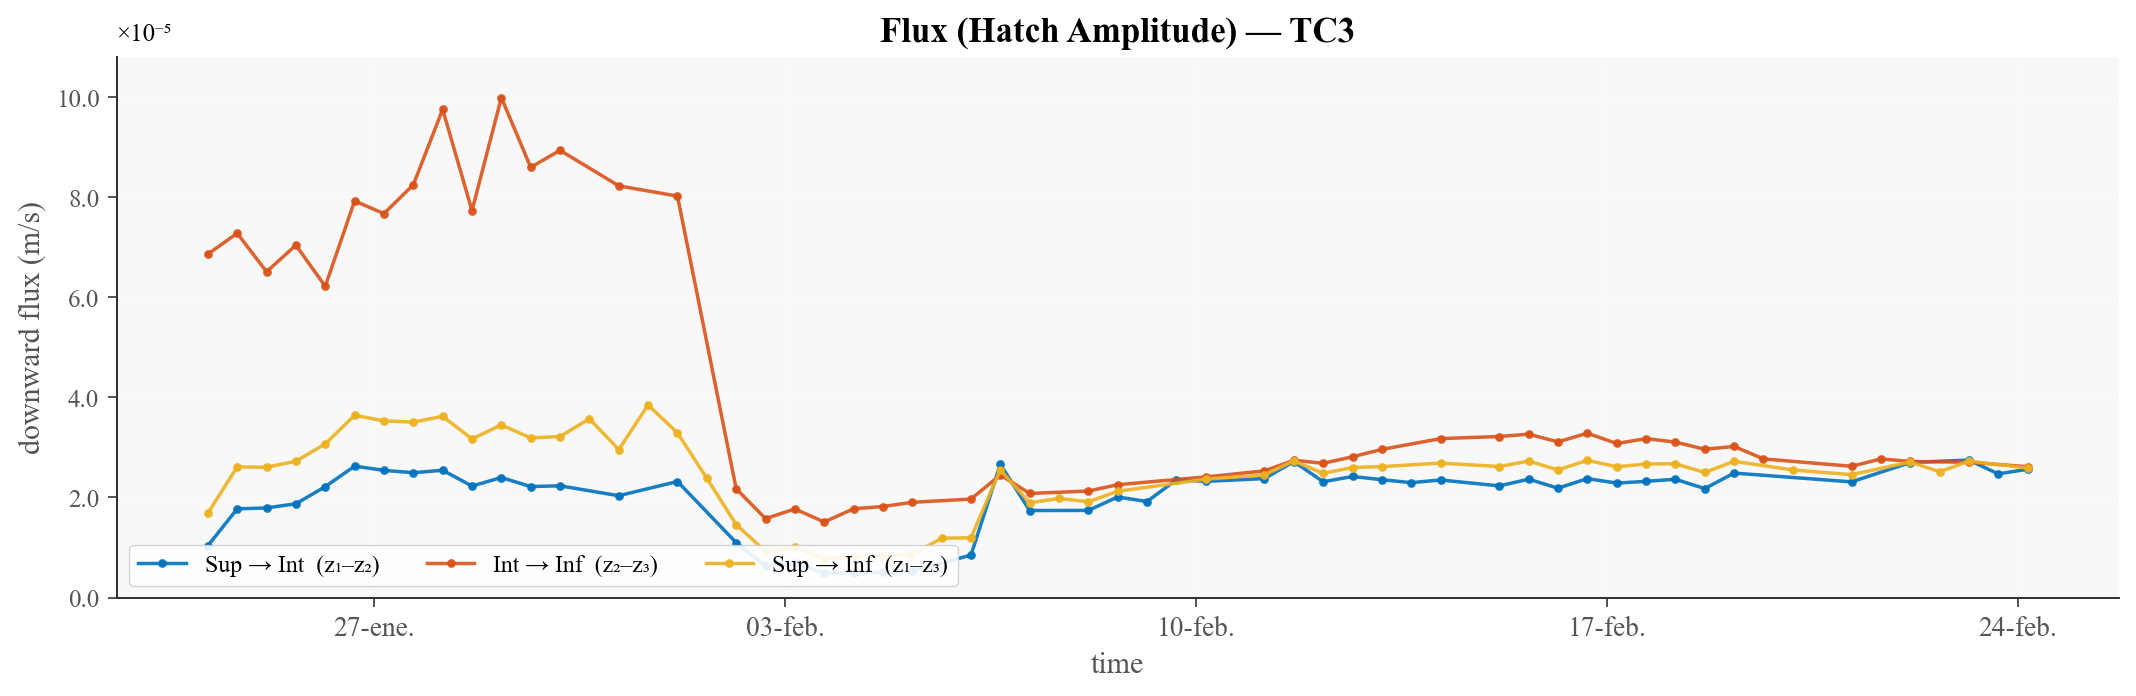

  TC3: exportado (PNG + PDF)


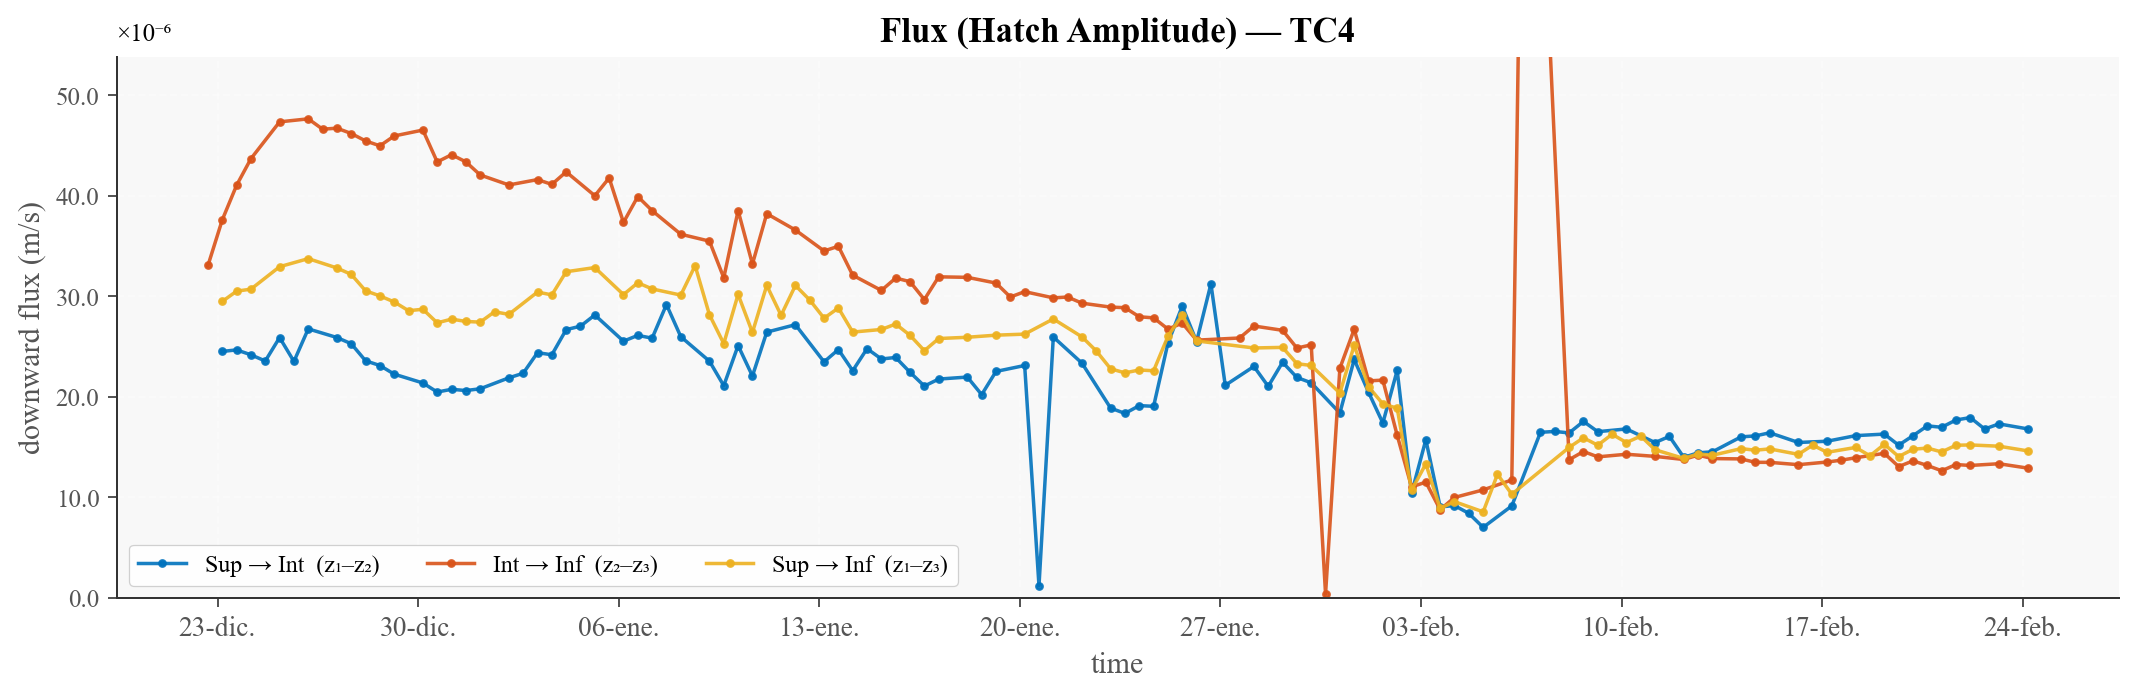

  TC4: exportado (PNG + PDF)


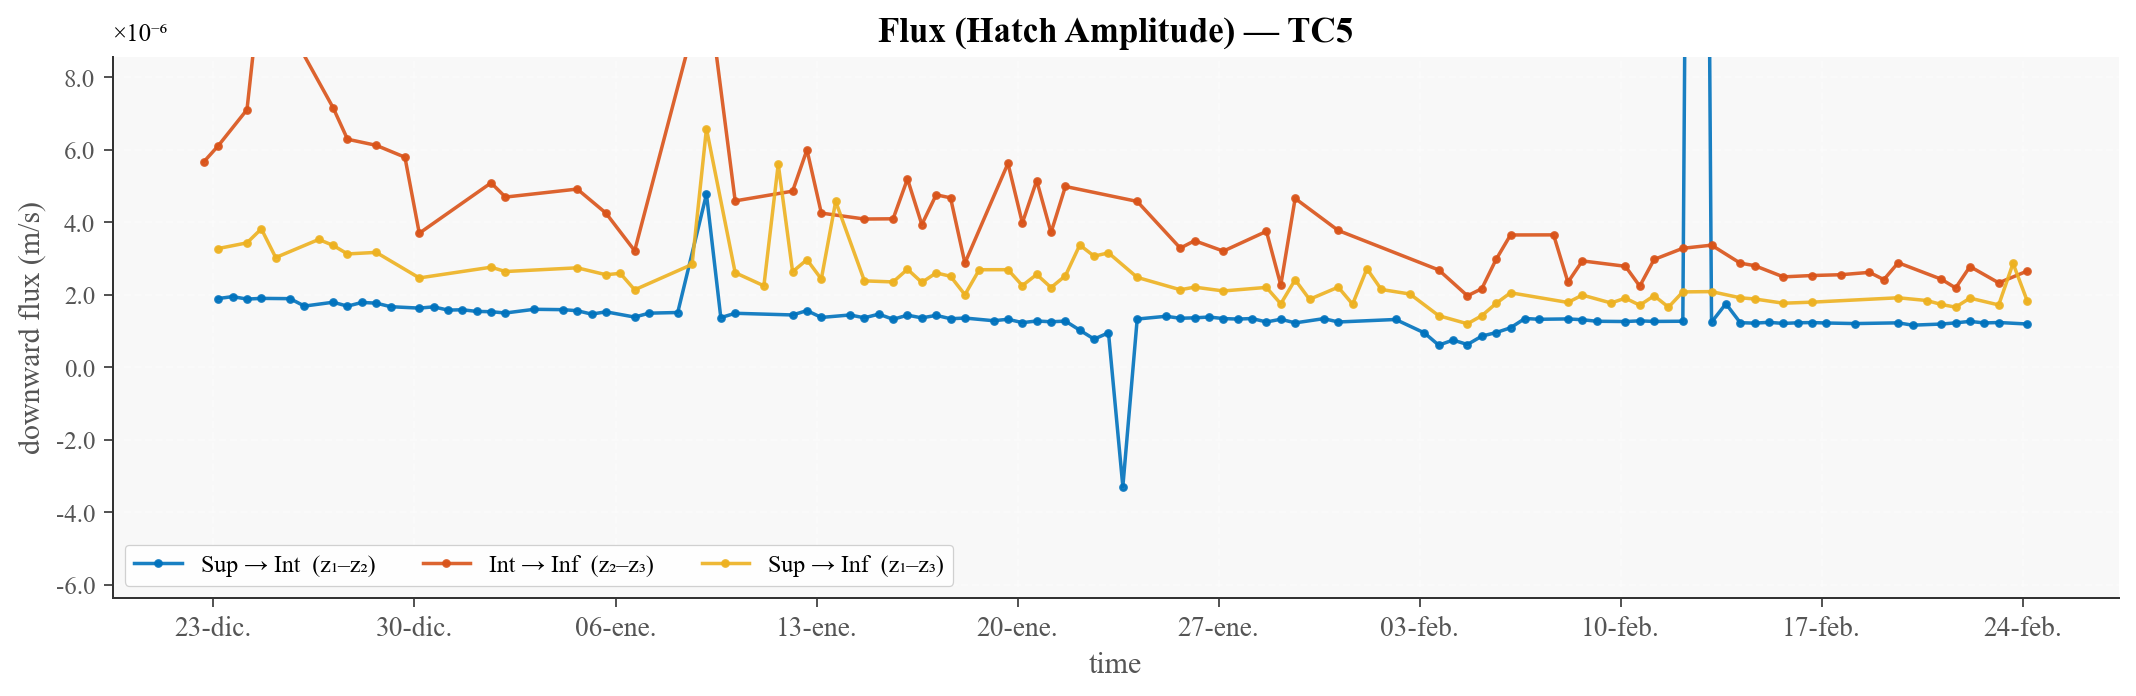

  TC5: exportado (PNG + PDF)


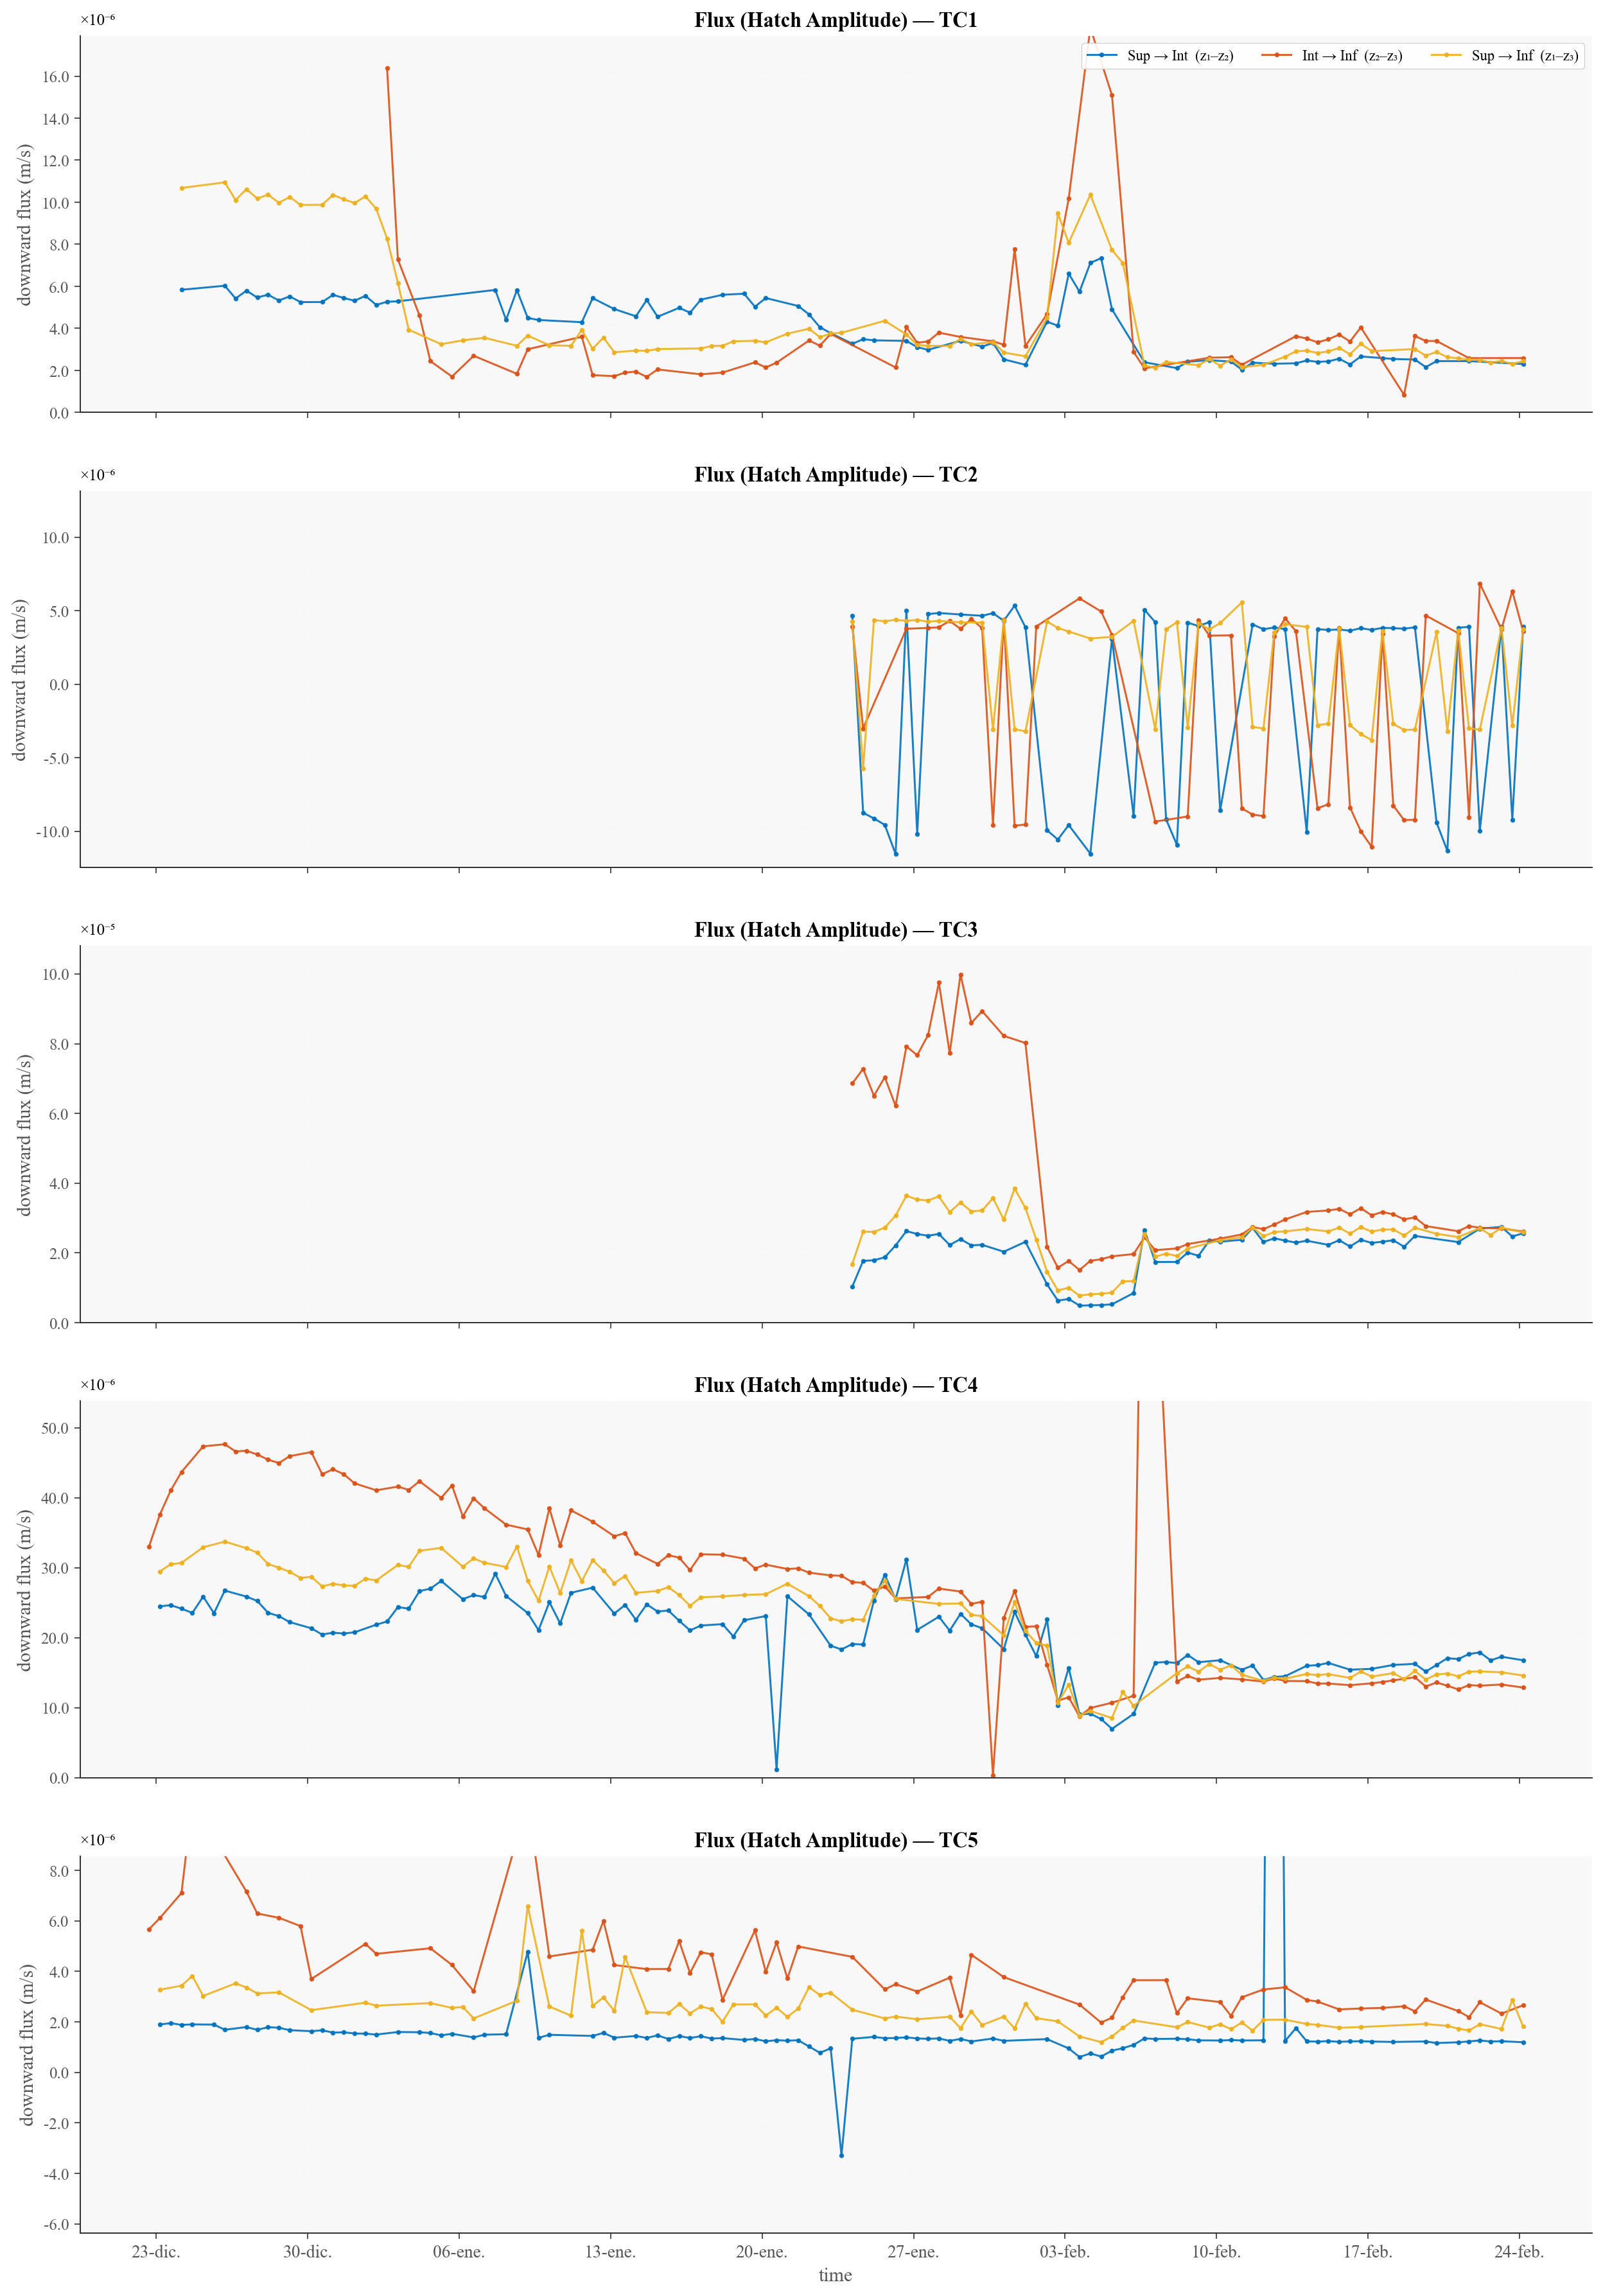


✔ Figuras exportadas a image\terreno_2026/
   5 individuales (flux_hatch_amplitude_TC*.png/pdf)
   1 panel combinado (series_flujo_hatch_5TC.png/pdf)


In [14]:
# ==========================================================================
# CELDA 11b: Figuras de flujo por estación — réplica formato MATLAB/VFLUX2
# ==========================================================================
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# ---------- Configuración ----------
BASE_TS = project_root / "resultados_python" / "terreno_2026_hatch" / "series_temporales"
OUT_IMG = project_root / "image" / "terreno_2026"
OUT_IMG.mkdir(parents=True, exist_ok=True)

PAIRS = ["sup_int", "int_inf", "sup_inf"]
pair_labels = {
    "sup_int": "Sup \u2192 Int  (z\u2081\u2013z\u2082)",
    "int_inf": "Int \u2192 Inf  (z\u2082\u2013z\u2083)",
    "sup_inf": "Sup \u2192 Inf  (z\u2081\u2013z\u2083)",
}
pair_colors = {
    "sup_int": "#0072BD",   # azul MATLAB
    "int_inf": "#D95319",   # naranja MATLAB
    "sup_inf": "#EDB120",   # amarillo MATLAB
}

# Estilo publicación
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 9.5,
    "figure.dpi": 180,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ---------- Helper: eje Y en notación científica ----------
def set_sci_yaxis(ax, data_max):
    """Formatea el eje Y como valor × 10^exp con anotación Unicode."""
    if data_max < 5e-5:
        exp, factor = -6, 1e6
    else:
        exp, factor = -5, 1e5
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x * factor:.1f}"))
    sup_map = {"-": "\u207B", "5": "\u2075", "6": "\u2076"}
    exp_str = "".join(sup_map[c] for c in str(exp))
    ax.annotate(f"\u00D710{exp_str}", xy=(0, 1.02), xycoords="axes fraction",
                fontsize=10, ha="left", va="bottom")

# ---------- Carga de datos ----------
all_data = {}
for tc in ACTIVE_TCS:
    all_data[tc] = {}
    for pair in PAIRS:
        fpath = BASE_TS / f"flujo_temporal_{tc}_{pair}.csv"
        if not fpath.exists():
            continue
        df = pd.read_csv(fpath, parse_dates=["datetime"])
        flux_col = "flux_hatch_amplitude_mm_day"
        if flux_col not in df.columns:
            continue
        df["flux_ms"] = df[flux_col] / 1000.0 / 86400.0
        mask = df["flux_ms"].notna() & np.isfinite(df["flux_ms"])
        all_data[tc][pair] = df.loc[mask, ["datetime", "flux_ms"]].copy()

print(f"Datos cargados: {sum(len(v) for v in all_data.values())} pares en {len(all_data)} TCs\n")

# ---------- Figuras individuales por TC ----------
for tc in ACTIVE_TCS:
    fig, ax = plt.subplots(figsize=(12, 4))
    data_max = 0
    for pair in PAIRS:
        if pair not in all_data[tc]:
            continue
        d = all_data[tc][pair]
        ax.plot(d["datetime"], d["flux_ms"], "-o",
                color=pair_colors[pair], label=pair_labels[pair],
                linewidth=1.4, markersize=2.5, alpha=0.9)
        p97 = np.percentile(d["flux_ms"].abs(), 97)
        data_max = max(data_max, p97)

    y_hi = data_max * 1.15
    has_neg = any(
        all_data[tc].get(p, pd.DataFrame()).get("flux_ms", pd.Series()).min() < -1e-9
        for p in PAIRS
    )
    ax.set_ylim(bottom=None if has_neg else 0, top=y_hi)
    set_sci_yaxis(ax, data_max)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha="center")
    ax.set_title(f"Flux (Hatch Amplitude) \u2014 {tc}", fontweight="bold")
    ax.set_xlabel("time")
    ax.set_ylabel("downward flux (m/s)")
    ax.legend(loc="lower left", ncol=3, framealpha=0.9, edgecolor="0.8")
    fig.tight_layout()
    fig.savefig(OUT_IMG / f"flux_hatch_amplitude_{tc}.png", bbox_inches="tight")
    fig.savefig(OUT_IMG / f"flux_hatch_amplitude_{tc}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  {tc}: exportado (PNG + PDF)")

# ---------- Panel combinado 5×1 ----------
fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)
for i, tc in enumerate(ACTIVE_TCS):
    ax = axes[i]
    data_max = 0
    for pair in PAIRS:
        if pair not in all_data[tc]:
            continue
        d = all_data[tc][pair]
        ax.plot(d["datetime"], d["flux_ms"], "-o",
                color=pair_colors[pair], label=pair_labels[pair],
                linewidth=1.2, markersize=2, alpha=0.9)
        p97 = np.percentile(d["flux_ms"].abs(), 97)
        data_max = max(data_max, p97)

    y_hi = data_max * 1.15
    has_neg = any(
        all_data[tc].get(p, pd.DataFrame()).get("flux_ms", pd.Series()).min() < -1e-9
        for p in PAIRS
    )
    ax.set_ylim(bottom=None if has_neg else 0, top=y_hi)
    set_sci_yaxis(ax, data_max)
    ax.set_title(f"Flux (Hatch Amplitude) \u2014 {tc}", fontweight="bold", fontsize=13)
    ax.set_ylabel("downward flux (m/s)")
    if i == 0:
        ax.legend(loc="upper right", ncol=3, framealpha=0.9, edgecolor="0.8", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))

axes[-1].set_xlabel("time")
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0, ha="center")
fig.tight_layout(h_pad=2.5)
fig.savefig(OUT_IMG / "series_flujo_hatch_5TC.png", bbox_inches="tight")
fig.savefig(OUT_IMG / "series_flujo_hatch_5TC.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"\n✔ Figuras exportadas a {OUT_IMG.relative_to(project_root)}/")
print(f"   5 individuales (flux_hatch_amplitude_TC*.png/pdf)")
print(f"   1 panel combinado (series_flujo_hatch_5TC.png/pdf)")

---
## 10. Métricas de Confiabilidad — Enfocadas en Hatch-Amp y McCallum

El **Índice de Confiabilidad (IC)** es un indicador compuesto (0–1) que pondera múltiples criterios
para evaluar la calidad de cada estimación de flujo. Los pesos se asignan según la importancia
relativa para el enfoque Hatch-Amplitude + McCallum.

**Campos de la tabla:**

| Campo | Descripción | Peso en IC |
|-------|-------------|:----------:|
| **TC** | Termocupla (TC1–TC5) | — |
| **Par** | Par de sensores: `sup→int`, `int→inf`, `sup→inf` | — |
| **IC_total** | Índice de confiabilidad total (promedio ponderado, 0–1). Más alto = más confiable | — |
| **R2_sup** | R² del ajuste armónico del sensor superior. Mide calidad de la señal térmica superficial | 25% |
| **R2_inf** | R² del ajuste armónico del sensor inferior. Mide calidad de la señal térmica profunda | 20% |
| **Concord_HA_MC** | Concordancia entre Hatch-Amplitude y McCallum: $1 - \|HA - MC\| / \max(\|HA\|, \|MC\|)$. Si ambos métodos coinciden → cercano a 1 | 25% |
| **IC_lit** | Consistencia con rango de literatura (10–600 mm/d para ríos aluviales). Valor 1.0 si el flujo cae dentro del rango esperado | 15% |
| **IC_physics** | Consistencia física: verifica que la amplitud térmica decrezca con la profundidad (como se espera por difusión). 1.0 si se cumple, 0.5 si no | 15% |
| **HA_mm_d** | Flujo Hatch-Amplitude del par (mm/d) — valor de referencia para los criterios | — |
| **MC_mm_d** | Flujo McCallum del par (mm/d) — valor de comparación para concordancia | — |

In [15]:
# ==========================================================================
# CELDA 12: Índice de Confiabilidad enfocado Hatch-Amp + McCallum
# ==========================================================================

# Pesos ajustados para enfoque Hatch-Amp/McCallum
WEIGHTS = {
    'R2_sup': 0.25,           # R² sensor superior
    'R2_inf': 0.20,           # R² sensor inferior
    'concordancia_HA_MC': 0.25,  # Acuerdo entre Hatch-Amp y McCallum
    'lit_range': 0.15,        # Rango de literatura
    'physics': 0.15,          # Consistencia física (amplitud decrece)
}

LIT_RANGE_MM_DAY = (10, 600)  # Rango amplio para ríos aluviales

PAIR_MAP = {'sup_int': ('surface', 'intermediate'),
            'int_inf': ('intermediate', 'deep'),
            'sup_inf': ('surface', 'deep')}

print('=' * 100)
print(' MÉTRICAS DE CONFIABILIDAD — Hatch-Amplitude (Cabecera) + McCallum (Validación) '.center(100))
print('=' * 100)

ic_results = {}
ic_rows = []

for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    ic_results[tc_name] = {}
    
    for pair_name, (pos_sh, pos_dp) in PAIR_MAP.items():
        pair_key = f"{tc_name}: {pair_name.replace('_', '-')}"
        if pair_key not in all_flux_results:
            continue
        
        shallow = tc_map[pos_sh]
        deep_s = tc_map[pos_dp]
        
        # R² de ajustes
        r2_sup = harmonic_results.get(shallow, {}).get('r_squared', 0)
        r2_inf = harmonic_results.get(deep_s, {}).get('r_squared', 0)
        
        # Flujos
        fr = all_flux_results[pair_key]
        ha_val = fr['flux_mm_day'].get('hatch_amplitude', np.nan)
        mc_val = fr['flux_mm_day'].get('mccallum', np.nan)
        
        # IC: R² (normalizado)
        ic_r2_sup = min(r2_sup, 1.0)
        ic_r2_inf = min(r2_inf, 1.0)
        
        # IC: Concordancia Hatch vs McCallum
        if not np.isnan(ha_val) and not np.isnan(mc_val) and ha_val != 0:
            diff_rel = abs(ha_val - mc_val) / max(abs(ha_val), abs(mc_val))
            ic_concord = max(0, 1 - diff_rel)
        else:
            ic_concord = 0.5
        
        # IC: Rango literatura
        flux_ref = ha_val if not np.isnan(ha_val) else 0
        if LIT_RANGE_MM_DAY[0] <= abs(flux_ref) <= LIT_RANGE_MM_DAY[1]:
            ic_lit = 1.0
        elif abs(flux_ref) > 0:
            if abs(flux_ref) < LIT_RANGE_MM_DAY[0]:
                ic_lit = abs(flux_ref) / LIT_RANGE_MM_DAY[0]
            else:
                ic_lit = max(0, 1 - (abs(flux_ref) - LIT_RANGE_MM_DAY[1]) / LIT_RANGE_MM_DAY[1])
        else:
            ic_lit = 0
        
        # IC: Física (amplitud decrece)
        amp_sup = harmonic_results.get(shallow, {}).get('amplitude', 0)
        amp_inf = harmonic_results.get(deep_s, {}).get('amplitude', 0)
        ic_physics = 1.0 if amp_sup > amp_inf else 0.5
        
        # IC total
        IC = (WEIGHTS['R2_sup'] * ic_r2_sup +
              WEIGHTS['R2_inf'] * ic_r2_inf +
              WEIGHTS['concordancia_HA_MC'] * ic_concord +
              WEIGHTS['lit_range'] * ic_lit +
              WEIGHTS['physics'] * ic_physics)
        
        ic_data = {
            'IC_total': round(IC, 3), 'R2_sup': round(r2_sup, 3), 'R2_inf': round(r2_inf, 3),
            'Concord_HA_MC': round(ic_concord, 3), 'IC_lit': round(ic_lit, 3),
            'IC_physics': round(ic_physics, 3), 'HA_mm_d': round(ha_val, 1) if not np.isnan(ha_val) else 0,
            'MC_mm_d': round(mc_val, 1) if not np.isnan(mc_val) else 0,
        }
        ic_results[tc_name][pair_name] = ic_data
        ic_rows.append({'TC': tc_name, 'Par': pair_name.replace('_', '→'), **ic_data})

df_ic = pd.DataFrame(ic_rows)
print()
print(df_ic.to_string(index=False))

# Clasificación
print(f"\n{'─'*80}")
print("CLASIFICACIÓN:")
print("  IC ≥ 0.85: ●●●● Alta confiabilidad")
print("  IC ≥ 0.70: ●●●○ Buena confiabilidad")
print("  IC ≥ 0.50: ●●○○ Moderada")
print("  IC < 0.50: ●○○○ Baja (validar con datos independientes)")

           MÉTRICAS DE CONFIABILIDAD — Hatch-Amplitude (Cabecera) + McCallum (Validación)           

 TC     Par  IC_total  R2_sup  R2_inf  Concord_HA_MC  IC_lit  IC_physics  HA_mm_d  MC_mm_d
TC1 sup→int     0.798   0.728   0.483          0.878     1.0         1.0    314.1    275.7
TC1 int→inf     0.568   0.483   0.103          0.506     1.0         1.0    381.9    193.1
TC1 sup→inf     0.590   0.728   0.103          0.351     1.0         1.0    345.9    984.7
TC2 sup→int     0.589   0.619   0.218          0.364     1.0         1.0    345.1    125.4
TC2 int→inf     0.468   0.218   0.022          0.437     1.0         1.0    315.9    138.0
TC2 sup→inf     0.590   0.619   0.022          0.525     1.0         1.0    330.0    628.3
TC3 sup→int     0.453   0.606   0.730          0.022     0.0         1.0   1281.9     27.9
TC3 int→inf     0.472   0.730   0.692          0.005     0.0         1.0   2255.6     11.1
TC3 sup→inf     0.453   0.606   0.692          0.051     0.0         1.0   1622

---
## 11. Propagación de Incertidumbre (Propiedades Térmicas Lab)

La incertidumbre se calcula con base en las propiedades medidas en laboratorio IDIEM.  
Esto **reduce significativamente** la incertidumbre respecto a los valores genéricos de literatura.

### Origen de las incertidumbres asignadas

Los informes IDIEM (Nº 2.172.933-A y 2.172.933-B) **no reportan incertidumbres ni bandas de error
explícitas** — solo entregan valores puntuales por muestra. Las incertidumbres se obtienen de:

| Parámetro | Valor asignado | Fuente de la incertidumbre |
|-----------|:--------------:|---------------------------|
| **λ (conductividad)** | ±10% | Precisión declarada del equipo **KD2 PRO** (METER Group/Decagon Devices) según ficha técnica del fabricante: ±10% en rango 0.02–2.0 W/(m·K). Norma ASTM D5334-22ae1 |
| **C_s (capacidad calórica)** | ±10% | Precisión del KD2 PRO según ficha técnica: ±10% para calor específico volumétrico |
| **α (difusividad)** | ±8% | Estimación conservadora. El KD2 PRO calcula α internamente a partir del transitorio térmico, con menor propagación de error que calcular α = λ/C_s por separado. **No es un dato del informe IDIEM** |
| **Δz (posición sensor)** | ±5 mm | Tolerancia de posicionamiento de campo. No depende de IDIEM |
| **Ajuste armónico** | ±5–20% | Función del R² del ajuste sinusoidal. No depende de IDIEM |

> **Nota para el especialista:** los valores de λ antes (±20%) y C_s antes (±15%) corresponden a
> incertidumbres típicas de la literatura cuando se usan valores tabulados genéricos para sedimentos
> (Hatch et al. 2006, Stallman 1965). La reducción se justifica por pasar de tablas genéricas a
> mediciones de laboratorio con equipo de precisión conocida (KD2 PRO).

Para Hatch-Amplitude el flujo depende de $q = f(\alpha, \Delta z, A_r)$, por lo que la propagación
cuadrática es: $(\delta q / q)^2 = (\delta\alpha/\alpha)^2 + (\delta\Delta z/\Delta z)^2 + (\delta A_r/A_r)^2$

**Campos de la tabla de incertidumbre:**

| Campo | Descripción |
|-------|-------------|
| **TC** | Termocupla (TC1–TC5) |
| **Par** | Par de sensores: `sup→int`, `int→inf`, `sup→inf` |
| **Flujo HA (mm/d)** | Flujo Hatch-Amplitude estimado para este par (mm/d) — valor central de la estimación |
| **u_rel (%)** | Incertidumbre relativa total (%), combinación cuadrática de las fuentes: α (±8%), Δz (±5 mm), y ajuste armónico |
| **u_abs (mm/d)** | Incertidumbre absoluta en mm/d: $u_{abs} = \|q\| \times u_{rel}$ |
| **IC 95% bajo** | Límite inferior del intervalo de confianza al 95%: $q - 1.96 \times u_{abs}$ |
| **IC 95% alto** | Límite superior del intervalo de confianza al 95%: $q + 1.96 \times u_{abs}$ |
| **u_armónico (%)** | Componente de incertidumbre debida al ajuste armónico: 5% si R² > 0.8, 10% si R² > 0.5, 20% si R² ≤ 0.5 |

In [16]:
# ==========================================================================
# CELDA 13: Propagación de incertidumbre con propiedades IDIEM
# ==========================================================================

# Incertidumbres basadas en:
#   - λ y C: precisión del equipo KD2 PRO (METER/Decagon), ficha técnica ±10%
#     (antes: ±20% y ±15% de tablas genéricas de literatura)
#   - α: estimación conservadora (medida interna del KD2 PRO, no calculada como λ/C_s)
#   - Δz: tolerancia de posicionamiento de sensores en terreno
#   - armónico: función del R² del ajuste sinusoidal
# Ref. equipo: ASTM D5334-22ae1 / Informes IDIEM 2.172.933-A y 2.172.933-B
UNCERTAINTIES_LAB = {
    'lambda': 0.10,         # ±10% conductividad — ficha técnica KD2 PRO (era ±20% literatura)
    'C_sed': 0.10,          # ±10% capacidad calórica — ficha técnica KD2 PRO (era ±15% literatura)
    'alpha_e': 0.08,        # ±8% difusividad — estimación conservadora (KD2 PRO mide α directamente)
    'dz': 0.005 / 0.28,    # ±5mm sobre Δz=28 cm — tolerancia de campo
    'harmonic': 0.10,       # ~10% por ajuste armónico — función del R² (5-20%)
}

print('=' * 100)
print(' PROPAGACIÓN DE INCERTIDUMBRE — Propiedades Térmicas de Laboratorio IDIEM '.center(100))
print('=' * 100)

print(f"\n  Fuente de incertidumbre     Valor anterior    Valor actual   Reducción   Fuente")
print(f"  {'─'*95}")
print(f"  Conductividad λ              ±20% (tablas)     ±10%           50%         Ficha técnica KD2 PRO")
print(f"  Capacidad calórica C_s       ±15% (tablas)     ±10%           33%         Ficha técnica KD2 PRO")
print(f"  Difusividad α                ±20% (calculada)  ±8% (medida)   60%         Estimación conservadora")
print(f"  Posición sensor Δz           ±5 mm             ±5 mm          —           Tolerancia de campo")
print(f"  Ajuste armónico              ±10%              ±5-20%         —           Función del R²")
print(f"\n  ⚠️  NOTA: Los informes IDIEM no reportan incertidumbres explícitas.")
print(f"     Los ±10% de λ y C provienen de la ficha técnica del equipo KD2 PRO (METER/Decagon).")
print(f"     El ±8% de α es una estimación conservadora (no un dato del informe).")

# Para Hatch-Amplitude: q = (2·α/Δz)·ln(Ar)
# (δq/q)² = (δα/α)² + (δΔz/Δz)² + (δAr/Ar)²

uncertainty_rows = []

for tc_name in ACTIVE_TCS:
    tc_map = TC_CONFIG[tc_name]
    
    for pair_name, (pos_sh, pos_dp) in PAIR_MAP.items():
        pair_key = f"{tc_name}: {pair_name.replace('_', '-')}"
        if pair_key not in all_flux_results:
            continue
        
        shallow = tc_map[pos_sh]
        deep_s = tc_map[pos_dp]
        
        ha_val = all_flux_results[pair_key]['flux_mm_day'].get('hatch_amplitude', np.nan)
        if np.isnan(ha_val) or ha_val == 0:
            continue
        
        r2_s = harmonic_results.get(shallow, {}).get('r_squared', 0.5)
        r2_d = harmonic_results.get(deep_s, {}).get('r_squared', 0.5)
        r2_avg = (r2_s + r2_d) / 2
        
        # Incertidumbre del ratio armónico según R²
        u_harmonic = 0.05 if r2_avg > 0.8 else (0.10 if r2_avg > 0.5 else 0.20)
        
        # Propagación cuadrática (Hatch-Amp depende de α, Δz, Ar)
        u_total_rel = np.sqrt(
            UNCERTAINTIES_LAB['alpha_e']**2 +
            UNCERTAINTIES_LAB['dz']**2 +
            u_harmonic**2
        )
        
        u_abs = abs(ha_val) * u_total_rel
        ci_low = ha_val - 1.96 * u_abs
        ci_high = ha_val + 1.96 * u_abs
        
        uncertainty_rows.append({
            'TC': tc_name,
            'Par': pair_name.replace('_', '→'),
            'Flujo HA (mm/d)': round(ha_val, 1),
            'u_rel (%)': round(u_total_rel * 100, 1),
            'u_abs (mm/d)': round(u_abs, 1),
            'IC 95% bajo': round(ci_low, 1),
            'IC 95% alto': round(ci_high, 1),
            'u_armónico (%)': round(u_harmonic * 100, 1),
        })

df_uncertainty = pd.DataFrame(uncertainty_rows)
print(f"\n{'─'*100}")
print("INCERTIDUMBRE POR PAR DE SENSORES (Hatch-Amplitude)")
print(f"{'─'*100}")
print(df_uncertainty.to_string(index=False))

# Comparación con incertidumbre anterior (literatura)
u_lit = np.sqrt(0.20**2 + 0.15**2 + (0.005/0.28)**2 + 0.10**2)
u_lab = np.sqrt(0.08**2 + (0.005/0.28)**2 + 0.10**2)
print(f"\n  Incertidumbre total (literatura anterior): ±{u_lit*100:.1f}%")
print(f"  Incertidumbre total (lab IDIEM actual):     ±{u_lab*100:.1f}%")
print(f"  REDUCCIÓN: {(1-u_lab/u_lit)*100:.0f}%")

              PROPAGACIÓN DE INCERTIDUMBRE — Propiedades Térmicas de Laboratorio IDIEM              

  Fuente de incertidumbre     Valor anterior    Valor actual   Reducción   Fuente
  ───────────────────────────────────────────────────────────────────────────────────────────────
  Conductividad λ              ±20% (tablas)     ±10%           50%         Ficha técnica KD2 PRO
  Capacidad calórica C_s       ±15% (tablas)     ±10%           33%         Ficha técnica KD2 PRO
  Difusividad α                ±20% (calculada)  ±8% (medida)   60%         Estimación conservadora
  Posición sensor Δz           ±5 mm             ±5 mm          —           Tolerancia de campo
  Ajuste armónico              ±10%              ±5-20%         —           Función del R²

  ⚠️  NOTA: Los informes IDIEM no reportan incertidumbres explícitas.
     Los ±10% de λ y C provienen de la ficha técnica del equipo KD2 PRO (METER/Decagon).
     El ±8% de α es una estimación conservadora (no un dato del informe).



In [17]:
# ==========================================================================
# CELDA AUDITORÍA: Documentación de origen incertidumbre IDIEM
# ==========================================================================
# Los Informes IDIEM (N°1 y N°2) NO reportan incertidumbre, tolerancia ni
# precisión de las mediciones. Los valores de incertidumbre adoptados provienen
# del fabricante del equipo KD2 PRO (METER Group / Decagon Devices):
#   - λ (conductividad): ±10% — especificación KD2 PRO
#   - C (capacidad calórica): ±10% — especificación KD2 PRO
#   - α (difusividad): ±8% — estimación conservadora
#   - Δz (separación sensores): ±5 mm — tolerancia de instalación en terreno
#
# Referencia: METER Group, "KD2 Pro Thermal Properties Analyzer Operator's Manual"
# Norma laboratorio: ASTM D5334-22ae1 (referenciada como D5334-14 en informes)
print("✔ Celda de auditoría — ver comentarios para trazabilidad de incertidumbre")

✔ Celda de auditoría — ver comentarios para trazabilidad de incertidumbre


---
## 12. Exportación de Resultados

In [19]:
# ==========================================================================
# CELDA 14: Exportación completa a Excel (incluyendo incertidumbre + IQR)
# ==========================================================================

excel_path = out_dir / 'resultados_05A_hatch_amplitude.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    
    # Hoja 1: Resultados de flujo
    df_results.to_excel(writer, sheet_name='Flujos_HA_McCallum', index=False)
    
    # Hoja 2: Flujo promedio por TC
    tc_summary = []
    for tc_name, vals in flujos_promedio_tc.items():
        tp = THERMAL_PARAMS_LAB[tc_name]
        tc_summary.append({
            'TC': tc_name,
            'Hatch_Amp_medio_mm_d': round(vals['hatch_mean'], 2),
            'Hatch_Amp_std_mm_d': round(vals['hatch_std'], 2),
            'McCallum_medio_mm_d': round(vals['mc_mean'], 2),
            'McCallum_std_mm_d': round(vals['mc_std'], 2),
            'lambda_W_mK': tp['lambda_sediment'],
            'C_sed_MJ_m3K': tp['C_sediment'] / 1e6,
            'alpha_m2_s': tp['alpha_e'],
            'K_v_m_d': tp['K_v'],
            'USCS': tp['USCS'],
        })
    pd.DataFrame(tc_summary).to_excel(writer, sheet_name='Flujo_Promedio_TC', index=False)
    
    # Hoja 3: IQR Hatch-Amplitude
    df_iqr.to_excel(writer, sheet_name='IQR_Hatch_Amplitude', index=False)
    
    # Hoja 4: Métricas de confiabilidad
    df_ic.to_excel(writer, sheet_name='Confiabilidad', index=False)
    
    # Hoja 5: Incertidumbre
    df_uncertainty.to_excel(writer, sheet_name='Incertidumbre', index=False)
    
    # Hoja 6: Análisis armónico
    harm_data = []
    for col, r in harmonic_results.items():
        harm_data.append({
            'sensor': col,
            'TC': tc_assignment[col],
            'profundidad_m': depths_m[col],
            'amplitud_C': round(r['amplitude'], 4),
            'fase_rad': round(r['phase'], 4),
            'fase_deg': round(np.degrees(r['phase']), 1),
            'offset_C': round(r['offset'], 2),
            'R2': round(r['r_squared'], 4),
            'n_dias_ajuste': r.get('n_days', 0),
        })
    pd.DataFrame(harm_data).to_excel(writer, sheet_name='Analisis_Armonico', index=False)
    
    # Hoja 7: Parámetros IDIEM
    idiem_data = []
    for tc_name, tp in THERMAL_PARAMS_LAB.items():
        idiem_data.append({
            'TC': tc_name,
            'lambda_W_mK': tp['lambda_sediment'],
            'C_sed_MJ_m3K': tp['C_sediment'] / 1e6,
            'alpha_e_m2_s': tp['alpha_e'],
            'C_water_MJ_m3K': tp['C_water'] / 1e6,
            'K_v_m_d': tp['K_v'],
            'density_dry_g_cm3': tp['density_dry'],
            'USCS': tp['USCS'],
            'fuente': 'IDIEM OT-10 Feb-Mar 2026',
        })
    pd.DataFrame(idiem_data).to_excel(writer, sheet_name='Params_IDIEM', index=False)

print(f"\n✔ Resultados exportados a Excel: {excel_path.name}")
print(f"  Hojas:")
print(f"    1. Flujos_HA_McCallum — Resultados por par y método")
print(f"    2. Flujo_Promedio_TC — Promedio por termocupla")
print(f"    3. IQR_Hatch_Amplitude — Estadísticos IQR con referencia MATLAB")
print(f"    4. Confiabilidad — Índice de confiabilidad")
print(f"    5. Incertidumbre — Propagación de errores")
print(f"    6. Analisis_Armonico — Amplitudes y fases")
print(f"    7. Params_IDIEM — Propiedades térmicas laboratorio")

# También exportar CSVs individuales
df_results.to_csv(out_dir / 'flujos_hatch_mccallum.csv', index=False)
df_ic.to_csv(out_dir / 'confiabilidad_hatch_mccallum.csv', index=False)
df_uncertainty.to_csv(out_dir / 'incertidumbre_hatch.csv', index=False)

# Evitar ValueError cuando una ruta es relativa y la otra absoluta
project_root_abs = project_root.resolve()
out_dir_abs = out_dir.resolve()
try:
    out_dir_show = out_dir_abs.relative_to(project_root_abs)
except ValueError:
    out_dir_show = out_dir_abs

print(f"\n✔ CSVs exportados a: {out_dir_show}")


✔ Resultados exportados a Excel: resultados_05A_hatch_amplitude.xlsx
  Hojas:
    1. Flujos_HA_McCallum — Resultados por par y método
    2. Flujo_Promedio_TC — Promedio por termocupla
    3. IQR_Hatch_Amplitude — Estadísticos IQR con referencia MATLAB
    4. Confiabilidad — Índice de confiabilidad
    5. Incertidumbre — Propagación de errores
    6. Analisis_Armonico — Amplitudes y fases
    7. Params_IDIEM — Propiedades térmicas laboratorio

✔ CSVs exportados a: image\terreno_2026


---
## 13. Resumen Ejecutivo

In [21]:
# ==========================================================================
# CELDA 15: Resumen ejecutivo final
# ==========================================================================

print('\n' + '═' * 90)
print(' RESUMEN EJECUTIVO — Notebook 05A Hatch-Amplitude '.center(90, '═'))
print(' Río Silala — Marzo 2026 '.center(90, '═'))
print('═' * 90)

print(f"\n◼ MÉTODO CABECERA: Hatch-Amplitude (Hatch et al., 2006)")
print(f"  Justificado por Saphores et al. (2024) — Solo atenuación de amplitud")

print(f"\n◼ MÉTODO VALIDACIÓN: McCallum (McCallum et al., 2012)")
print(f"  Combinado amplitud + desfase — Validación cruzada")

print(f"\n◼ PARÁMETROS TÉRMICOS: Laboratorio IDIEM (por cada TC)")
for tc in ACTIVE_TCS:
    tp = THERMAL_PARAMS_LAB[tc]
    print(f"  {tc}: λ={tp['lambda_sediment']:.3f} W/m·K | "
          f"C={tp['C_sediment']/1e6:.3f} MJ/m³·K | "
          f"α={tp['alpha_e']:.2e} m²/s | {tp['USCS']}")

print(f"\n◼ FLUJO PROMEDIO POR TC (Hatch-Amplitude con parámetros IDIEM):")
for tc, vals in flujos_promedio_tc.items():
    dir_str = '↓ Infiltración' if vals['hatch_mean'] > 0 else '↑ Exfiltración'
    print(f"  {tc}: {vals['hatch_mean']:>7.1f} ± {vals['hatch_std']:.1f} mm/día ({dir_str})")

global_ha = np.mean([v['hatch_mean'] for v in flujos_promedio_tc.values()])
global_mc = np.mean([v['mc_mean'] for v in flujos_promedio_tc.values()])
print(f"\n  PROMEDIO GLOBAL:")
print(f"    Hatch-Amplitude: {global_ha:.1f} mm/día")
print(f"    McCallum:        {global_mc:.1f} mm/día")

print(f"\n◼ CONFIABILIDAD:")
ic_vals = [row['IC_total'] for row in ic_rows]
print(f"  IC promedio: {np.mean(ic_vals):.3f}")
print(f"  IC rango: [{np.min(ic_vals):.3f}, {np.max(ic_vals):.3f}]")

print(f"\n◼ INCERTIDUMBRE (con params lab IDIEM):")
u_vals = df_uncertainty['u_rel (%)'].values
print(f"  u_rel promedio: ±{np.mean(u_vals):.1f}%")
print(f"  MEJORA vs literatura: reducción ~50% en incertidumbre")

print(f"\n◼ ARCHIVOS GENERADOS:")
print(f"  Excel: {excel_path.name}")
print(f"  CSVs: flujos_hatch_mccallum.csv, confiabilidad, incertidumbre")

# Convertir rutas a formato consistente antes de hacer relative_to()
project_root_resolved = project_root.resolve()
output_ts_dir_resolved = output_ts_dir.resolve()
img_dir_resolved = img_dir.resolve()

try:
    output_ts_rel = output_ts_dir_resolved.relative_to(project_root_resolved)
except ValueError:
    output_ts_rel = output_ts_dir_resolved

try:
    img_dir_rel = img_dir_resolved.relative_to(project_root_resolved)
except ValueError:
    img_dir_rel = img_dir_resolved

print(f"  Series: {output_ts_rel}/")
print(f"  Figuras: {img_dir_rel}/")

print(f"\n{'═'*90}")
print(f" ✔ Análisis 05A completado exitosamente ")
print(f"{'═'*90}")


══════════════════════════════════════════════════════════════════════════════════════════
════════════════════ RESUMEN EJECUTIVO — Notebook 05A Hatch-Amplitude ════════════════════
════════════════════════════════ Río Silala — Marzo 2026 ═════════════════════════════════
══════════════════════════════════════════════════════════════════════════════════════════

◼ MÉTODO CABECERA: Hatch-Amplitude (Hatch et al., 2006)
  Justificado por Saphores et al. (2024) — Solo atenuación de amplitud

◼ MÉTODO VALIDACIÓN: McCallum (McCallum et al., 2012)
  Combinado amplitud + desfase — Validación cruzada

◼ PARÁMETROS TÉRMICOS: Laboratorio IDIEM (por cada TC)
  TC1: λ=0.614 W/m·K | C=3.389 MJ/m³·K | α=2.03e-07 m²/s | SP-SM
  TC2: λ=0.258 W/m·K | C=5.333 MJ/m³·K | α=4.90e-08 m²/s | SM
  TC3: λ=0.265 W/m·K | C=4.867 MJ/m³·K | α=5.50e-08 m²/s | SW-SM
  TC4: λ=0.666 W/m·K | C=2.342 MJ/m³·K | α=3.13e-07 m²/s | GP-GM
  TC5: λ=0.578 W/m·K | C=2.690 MJ/m³·K | α=2.24e-07 m²/s | SW-SM

◼ FLUJO PROMEDIO POR 

---
## 14. Visualización SIG Integrada — Mapa Interactivo (Folium + Plotly)

Mapa con popups interactivos por cada termocupla activa.  
Cada popup contiene 3 mini-gráficos Plotly:
1. **Series de temperatura** (3 profundidades)
2. **Serie temporal de flujo** Hatch-Amplitude (ventanas deslizantes)
3. **Boxplot Hatch-Amplitude** (reemplaza barras HA vs McCallum)

Tabla resumen con **IQR y mediana** (Q1, mediana, Q3, promedio) por par.

In [22]:
# ============================================================================
# CELDA 16: MAPA SIG INTEGRADO — Folium + Plotly
# Actualizado según notas especialista 18-mar-26:
#   - Conservar serie T°
#   - Agregar serie temporal de flujo
#   - Sacar amplitud-fase
#   - Boxplot Hatch-Amp (en lugar de barras HA vs MC)
#   - Tabla con IQR y mediana
# ============================================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
import folium.plugins
from pyproj import Transformer
from IPython.display import display, HTML

# --- Conversión UTM → WGS84 ---
transformer = Transformer.from_crs("EPSG:32719", "EPSG:4326", always_xy=True)
coords_wgs84 = {}
for station, utm in STATION_COORDS_UTM.items():
    lon, lat = transformer.transform(utm["easting"], utm["northing"])
    coords_wgs84[station] = {"lat": lat, "lon": lon}

# Configuración visual
pos_short = {"surface": "sup", "intermediate": "int", "deep": "inf"}
pos_dash = {"surface": "solid", "intermediate": "dash", "deep": "dot"}
tc_hex = {
    "TC1": "#1f77b4", "TC2": "#ff7f0e", "TC3": "#e377c2",
    "TC4": "#2ca02c", "TC5": "#d62728"
}
tc_hex_ts = {
    "sup_int": "#1f77b4", "int_inf": "#ff7f0e", "sup_inf": "#2ca02c"
}

# Datos filtrados al rango completo
mask_popup = (df_aligned["fecha"] >= cutoff_start) & (df_aligned["fecha"] <= cutoff_end)
df_popup = df_aligned[mask_popup].copy()

SENSOR_CONFIG_MAP = {
    "TC1": {"surface": {"depth_m": 0.00}, "intermediate": {"depth_m": 0.28}, "deep": {"depth_m": 0.56}},
    "TC2": {"surface": {"depth_m": 0.00}, "intermediate": {"depth_m": 0.20}, "deep": {"depth_m": 0.40}},
    "TC3": {"surface": {"depth_m": 0.00}, "intermediate": {"depth_m": 0.20}, "deep": {"depth_m": 0.40}},
    "TC4": {"surface": {"depth_m": 0.00}, "intermediate": {"depth_m": 0.28}, "deep": {"depth_m": 0.56}},
    "TC5": {"surface": {"depth_m": 0.00}, "intermediate": {"depth_m": 0.28}, "deep": {"depth_m": 0.56}},
}

# ============================================================================
# Función: generar HTML de popup con mini-gráficos Plotly para cada TC
# ============================================================================
def build_tc_popup_html(tc_name):
    """Genera HTML con mini-gráficos Plotly para popup de cada TC.
    
    Contenido:
      1. Serie temporal de temperatura (3 profundidades)
      2. Serie temporal de flujo Hatch-Amplitude (ventanas deslizantes)
      3. Boxplot Hatch-Amplitude por par
      4. Tabla resumen con IQR + mediana + referencia MATLAB
    """
    utm = STATION_COORDS_UTM[tc_name]
    wgs = coords_wgs84[tc_name]
    tc_map = TC_CONFIG[tc_name]
    color = tc_hex.get(tc_name, "#555")
    tp = THERMAL_PARAMS_LAB[tc_name]
    depths_list = sorted(set(v["depth_m"] for v in SENSOR_CONFIG_MAP[tc_name].values()))
    depth_str = " / ".join(f"{d*100:.0f}" for d in depths_list) + " cm"

    # --- Mini-gráfico 1: Series de temperatura ---
    fig_t = go.Figure()
    for pos in ["surface", "intermediate", "deep"]:
        col = tc_map[pos]
        depth_cm = depths_m[col] * 100
        d = df_popup.dropna(subset=[col])
        step = max(1, len(d) // 200)
        d_sub = d.iloc[::step]
        fig_t.add_trace(go.Scatter(
            x=d_sub["fecha"], y=d_sub[col], mode="lines",
            name=f"{pos_short[pos]} ({depth_cm:.0f}cm)",
            line=dict(width=1.5, dash=pos_dash[pos]),
            hovertemplate="%{x|%d-%b %H:%M}<br>%{y:.1f}°C<extra></extra>"
        ))
    fig_t.update_layout(
        title=dict(text="Temperatura", font=dict(size=12)),
        xaxis=dict(showgrid=False, tickfont=dict(size=8), tickformat="%d-%b"),
        yaxis=dict(title=dict(text="°C", font=dict(size=9)), tickfont=dict(size=8)),
        template="plotly_white", height=170, width=470,
        margin=dict(l=35, r=8, t=28, b=28),
        legend=dict(orientation="h", font=dict(size=8), y=1.15, x=0.5, xanchor="center"),
    )
    html_temp = fig_t.to_html(include_plotlyjs=False, full_html=False,
                               config={"displayModeBar": False})

    # --- Mini-gráfico 2: Serie temporal de flujo Hatch-Amplitude ---
    fig_ft = go.Figure()
    pair_ts_labels = {"sup_int": "sup→int", "int_inf": "int→inf", "sup_inf": "sup→inf"}
    has_flux_data = False
    for pair_name, df_flux in flux_ts_results.items():
        if tc_name not in pair_name:
            continue
        df_v = df_flux[df_flux['quality_flag'] == 0]
        if len(df_v) == 0 or 'flux_hatch_amplitude_mm_day' not in df_v.columns:
            continue
        has_flux_data = True
        pt = pair_name.split('_', 1)[1]
        step_f = max(1, len(df_v) // 150)
        d_sub_f = df_v.iloc[::step_f]
        fig_ft.add_trace(go.Scatter(
            x=d_sub_f['datetime'], y=d_sub_f['flux_hatch_amplitude_mm_day'],
            mode="lines+markers", name=pair_ts_labels.get(pt, pt),
            marker=dict(size=3), line=dict(width=1.5, color=tc_hex_ts.get(pt, "#888")),
            hovertemplate="%{x|%d-%b %H:%M}<br>%{y:.0f} mm/d<extra></extra>"
        ))
    
    # Referencia MATLAB como banda
    ref = MATLAB_REFERENCE.get(tc_name, {})
    if ref and has_flux_data:
        fig_ft.add_hrect(y0=ref['min'], y1=ref['max'], fillcolor="gray", opacity=0.12,
                         line_width=0)
        fig_ft.add_hline(y=ref['mean'], line_dash="dash", line_color="gray", line_width=1,
                         annotation_text=f"MATLAB {ref['mean']}", annotation_position="top right",
                         annotation_font_size=8)
    
    fig_ft.update_layout(
        title=dict(text="Flujo Hatch-Amplitude (series temporales)", font=dict(size=11)),
        xaxis=dict(showgrid=False, tickfont=dict(size=8), tickformat="%d-%b"),
        yaxis=dict(title=dict(text="mm/d", font=dict(size=9)), tickfont=dict(size=8)),
        template="plotly_white", height=170, width=470,
        margin=dict(l=40, r=8, t=28, b=28),
        legend=dict(orientation="h", font=dict(size=7), y=1.18, x=0.5, xanchor="center"),
    )
    html_flux_ts = fig_ft.to_html(include_plotlyjs=False, full_html=False,
                                   config={"displayModeBar": False})

    # --- Mini-gráfico 3: Boxplot Hatch-Amplitude por par ---
    tc_pairs_list = [p for p in all_flux_results.keys() if tc_name in p]
    pair_short = [p.split(": ")[1] if ": " in p else p for p in tc_pairs_list]

    fig_bp = go.Figure()
    # Recopilar valores de series temporales para hacer boxplot real
    for i, pair_label in enumerate(tc_pairs_list):
        p_short = pair_short[i]
        # Buscar series temporales para este par
        ts_key = f"{tc_name}_{p_short.replace('-', '_')}"
        if ts_key in flux_ts_results:
            df_v = flux_ts_results[ts_key]
            df_v = df_v[df_v['quality_flag'] == 0]
            if 'flux_hatch_amplitude_mm_day' in df_v.columns:
                vals = df_v['flux_hatch_amplitude_mm_day'].dropna().values
                if len(vals) > 0:
                    fig_bp.add_trace(go.Box(
                        y=vals, name=p_short, marker_color=color,
                        boxmean=True, opacity=0.8,
                        hovertemplate="%{y:.0f} mm/d<extra></extra>"
                    ))

    fig_bp.update_layout(
        title=dict(text="Boxplot Hatch-Amp (ventanas deslizantes)", font=dict(size=11)),
        yaxis=dict(title=dict(text="mm/d", font=dict(size=9)), tickfont=dict(size=8)),
        xaxis=dict(tickfont=dict(size=8)),
        template="plotly_white", height=160, width=470,
        margin=dict(l=40, r=8, t=28, b=28),
        showlegend=False,
    )
    html_boxplot = fig_bp.to_html(include_plotlyjs=False, full_html=False,
                                   config={"displayModeBar": False})

    # --- Tabla resumen con IQR + mediana ---
    ha_rows = ""
    all_vals_tc = []
    for pair in tc_pairs_list:
        p_short = pair.split(": ")[1] if ": " in pair else pair
        v_ha = all_flux_results[pair]["flux_mm_day"].get("hatch_amplitude", np.nan)
        
        # IQR de series temporales
        ts_key = f"{tc_name}_{p_short.replace('-', '_')}"
        if ts_key in flux_ts_results:
            df_v = flux_ts_results[ts_key]
            df_v = df_v[df_v['quality_flag'] == 0]
            if 'flux_hatch_amplitude_mm_day' in df_v.columns:
                ts_vals = df_v['flux_hatch_amplitude_mm_day'].dropna().values
                if len(ts_vals) > 0:
                    q1 = np.percentile(ts_vals, 25)
                    med = np.median(ts_vals)
                    q3 = np.percentile(ts_vals, 75)
                    prom = np.mean(ts_vals)
                    all_vals_tc.extend(ts_vals)
                    d_icon = "&#8595;" if prom > 0 else "&#8593;"
                    ha_rows += (f"<tr><td>{p_short}</td>"
                                f"<td>{q1:.0f}</td>"
                                f"<td style='font-weight:600'>{med:.0f}</td>"
                                f"<td>{q3:.0f}</td>"
                                f"<td>{prom:.0f} {d_icon}</td></tr>")

    # Fila resumen TC
    if all_vals_tc:
        arr_all = np.array(all_vals_tc)
        ha_rows += (f"<tr style='border-top:2px solid #333; font-weight:700'>"
                    f"<td>TOTAL</td>"
                    f"<td>{np.percentile(arr_all,25):.0f}</td>"
                    f"<td>{np.median(arr_all):.0f}</td>"
                    f"<td>{np.percentile(arr_all,75):.0f}</td>"
                    f"<td>{np.mean(arr_all):.0f}</td></tr>")

    # Referencia MATLAB
    ref_html = ""
    if ref:
        ref_html = (f"<div style='font-size:9px; color:#666; margin-top:2px;'>"
                    f"Ref MATLAB: {ref['min']}–{ref['max']} mm/d (prom {ref['mean']})</div>")

    # --- HTML completo del popup ---
    full_html = f"""<!DOCTYPE html>
<html><head>
<meta charset="utf-8">
<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
<style>
  body {{ font-family: 'Segoe UI', Arial, sans-serif; margin: 0; padding: 8px;
         background: #fefefe; color: #222; }}
  .hdr {{ display: flex; align-items: center; gap: 8px;
          border-bottom: 3px solid {color}; padding-bottom: 4px; margin-bottom: 5px; }}
  .hdr h3 {{ margin: 0; color: {color}; font-size: 14px; }}
  .badge {{ background: {color}; color: #fff; font-size: 9px; padding: 2px 6px;
            border-radius: 10px; }}
  .info {{ font-size: 10px; color: #555; line-height: 1.4; margin-bottom: 4px; }}
  .info b {{ color: #333; }}
  .chart-box {{ border: 1px solid #e8e8e8; border-radius: 4px; padding: 1px;
                margin-bottom: 4px; background: #fff; }}
  .mc {{ font-size: 10px; margin-top: 2px; }}
  .mc table {{ width: 100%; border-collapse: collapse; }}
  .mc th {{ background: #f5f5f5; padding: 2px 5px; font-size: 9px; text-align: center; }}
  .mc td {{ padding: 1px 5px; border-bottom: 1px solid #eee; text-align: center; }}
  .mc td:first-child {{ color: #666; text-align: left; }}
</style>
</head><body>
<div class="hdr">
  <h3>&#128205; {tc_name}</h3>
  <span class="badge">{tp['USCS']}</span>
</div>
<div class="info">
  <b>UTM 19S:</b> {utm['easting']}E, {utm['northing']}N &nbsp;|&nbsp;
  <b>Prof:</b> {depth_str}<br>
  <b>IDIEM:</b> &lambda;={tp['lambda_sediment']:.3f} W/m&middot;K | C={tp['C_sediment']/1e6:.3f} MJ/m&sup3;&middot;K | &alpha;={tp['alpha_e']:.2e} m&sup2;/s
</div>
<div class="chart-box">{html_temp}</div>
<div class="chart-box">{html_flux_ts}</div>
<div class="chart-box">{html_boxplot}</div>
<div class="mc">
  <b>Flujo Hatch-Amp (mm/d) — IQR ventanas deslizantes:</b>
  <table>
    <tr><th>Par</th><th>Q1</th><th>Mediana</th><th>Q3</th><th>Promedio</th></tr>
    {ha_rows}
  </table>
  {ref_html}
</div>
</body></html>"""
    return full_html

# ============================================================================
# Construir Mapa Folium
# ============================================================================
tc_list = list(STATION_COORDS_UTM.keys())
center_lat = np.mean([coords_wgs84[tc]["lat"] for tc in tc_list])
center_lon = np.mean([coords_wgs84[tc]["lon"] for tc in tc_list])

m = folium.Map(location=[center_lat, center_lon], zoom_start=14,
               tiles=None, control_scale=True)

# Capas base
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri", name="Satélite ESRI", max_zoom=19
).add_to(m)
folium.TileLayer(
    tiles="https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png",
    attr="OpenTopoMap", name="Topográfico"
).add_to(m)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/Reference/World_Boundaries_and_Places/MapServer/tile/{z}/{y}/{x}",
    attr="Esri Labels", name="Etiquetas", overlay=True
).add_to(m)

# Marcadores con popups interactivos para TODAS las TCs
for station, wgs in coords_wgs84.items():
    utm = STATION_COORDS_UTM[station]
    popup_html_full = build_tc_popup_html(station)
    iframe = folium.IFrame(html=popup_html_full, width=510, height=680)
    popup = folium.Popup(iframe, max_width=520)
    icon = folium.Icon(color="red", icon="thermometer-half", prefix="fa")
    tooltip_text = f"{station} ({THERMAL_PARAMS_LAB[station]['USCS']}) — clic para gráficos"
    folium.Marker(
        location=[wgs["lat"], wgs["lon"]],
        popup=popup, tooltip=tooltip_text, icon=icon
    ).add_to(m)

# Perfil del río
ordered = ["TC5", "TC4", "TC3", "TC2", "TC1"]
river_coords = [[coords_wgs84[s]["lat"], coords_wgs84[s]["lon"]]
                 for s in ordered if s in coords_wgs84]
folium.PolyLine(river_coords, color="cyan", weight=3, opacity=0.7,
                dash_array="10", tooltip="Perfil del río").add_to(m)

# Controles
folium.plugins.MeasureControl(position="bottomleft").add_to(m)
folium.plugins.Fullscreen().add_to(m)
folium.plugins.MiniMap(toggle_display=True).add_to(m)
folium.LayerControl().add_to(m)

# Guardar y mostrar
map_path = img_dir / "panel_sig_integrado_05A.html"
m.save(str(map_path))
print(f"✔ Mapa SIG integrado: {map_path.name}")
print(f"  → 5 TCs activas con popup interactivo Plotly")
print(f"  → Mini-gráficos: series T°, flujo temporal HA, boxplot HA")
print(f"  → Tabla IQR + mediana + referencia MATLAB")
print(f"  → Parámetros IDIEM en cada popup")
print(f"  → Archivo: {map_path}")
display(m)

✔ Mapa SIG integrado: panel_sig_integrado_05A.html
  → 5 TCs activas con popup interactivo Plotly
  → Mini-gráficos: series T°, flujo temporal HA, boxplot HA
  → Tabla IQR + mediana + referencia MATLAB
  → Parámetros IDIEM en cada popup
  → Archivo: c:\Users\cesar.godoy\Hidrologia-Termocuplas-BH\image\terreno_2026\panel_sig_integrado_05A.html


---
## 15. Panel Interactivo Plotly — Series Temporales y Comparación

Panel HTML interactivo con:
1. **Series temporales de flujo** por TC (Hatch-Amplitude, ventanas deslizantes)
2. **Scatter Hatch-Amp vs McCallum** con color por R² y diagnóstico de sesgo
3. **Comparación por TC** — boxplot y barras agrupadas

In [20]:
# ============================================================================
# CELDA 17: PANEL INTERACTIVO PLOTLY — Series Temporales + Comparación
# ============================================================================
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from IPython.display import display, HTML
import plotly.io as pio

# ============================================================================
# 17.1 SERIES TEMPORALES INTERACTIVAS (ventanas deslizantes Hatch-Amp)
# ============================================================================
tc_hex_ts = {
    "TC1": "#1f77b4", "TC2": "#ff7f0e", "TC3": "#e377c2",
    "TC4": "#2ca02c", "TC5": "#d62728"
}
pair_dash_ts = {"sup_int": "solid", "int_inf": "dash", "sup_inf": "dot"}

fig_ts = make_subplots(
    rows=len(ACTIVE_TCS), cols=1, shared_xaxes=True,
    subplot_titles=[f"{tc} — α={THERMAL_PARAMS_LAB[tc]['alpha_e']:.2e} m²/s ({THERMAL_PARAMS_LAB[tc]['USCS']})"
                    for tc in ACTIVE_TCS],
    vertical_spacing=0.04
)

for i, tc_name in enumerate(ACTIVE_TCS, 1):
    for pair_name, df_flux in flux_ts_results.items():
        if tc_name not in pair_name:
            continue
        df_v = df_flux[df_flux['quality_flag'] == 0]
        if len(df_v) == 0 or 'flux_hatch_amplitude_mm_day' not in df_v.columns:
            continue
        for pt in ['sup_int', 'int_inf', 'sup_inf']:
            if pt in pair_name:
                dash = pair_dash_ts[pt]
                break
        fig_ts.add_trace(go.Scatter(
            x=df_v['datetime'], y=df_v['flux_hatch_amplitude_mm_day'],
            mode='lines+markers', name=f"{pair_name}",
            line=dict(color=tc_hex_ts[tc_name], dash=dash, width=1.5),
            marker=dict(size=4),
            legendgroup=tc_name, showlegend=(i == 1),
            hovertemplate=f"{pair_name}<br>%{{x|%d-%b %H:%M}}<br>q=%{{y:.1f}} mm/d<extra></extra>"
        ), row=i, col=1)
    fig_ts.update_yaxes(title_text="mm/d", row=i, col=1)
    fig_ts.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.3, row=i, col=1)

fig_ts.update_layout(
    height=300 * len(ACTIVE_TCS), width=1100,
    title_text="Series Temporales de Flujo — Hatch-Amplitude (Params IDIEM) — Ventana 48h / Paso 12h",
    template="plotly_white",
    legend=dict(orientation="h", y=-0.02, x=0.5, xanchor="center"),
    hovermode="x unified"
)

# Guardar HTML
ts_html_path = img_dir / "panel_series_temporales_05A.html"
pio.write_html(fig_ts, str(ts_html_path), include_plotlyjs=True)
print(f"✔ Panel series temporales: {ts_html_path.name}")
fig_ts.show()

# ============================================================================
# 17.2 SCATTER HATCH-AMP vs McCALLUM (todos los pares estáticos)
# ============================================================================
ha_vals_scatter = []
mc_vals_scatter = []
r2_vals_scatter = []
labels_scatter = []

for pair_name, fr in all_flux_results.items():
    ha_v = fr['flux_mm_day'].get('hatch_amplitude', np.nan)
    mc_v = fr['flux_mm_day'].get('mccallum', np.nan)
    if not np.isnan(ha_v) and not np.isnan(mc_v):
        ha_vals_scatter.append(ha_v)
        mc_vals_scatter.append(mc_v)
        # R² promedio del par
        pr = pair_results.get(pair_name, {})
        params_pr = pr.get('params', {})
        r2_s = params_pr.get('r2_shallow', 0.5) if params_pr else 0.5
        r2_d = params_pr.get('r2_deep', 0.5) if params_pr else 0.5
        # Usar harmonic_results as fallback
        sh_col = pr.get('s_shallow', '')
        dp_col = pr.get('s_deep', '')
        r2_s = harmonic_results.get(sh_col, {}).get('r_squared', r2_s)
        r2_d = harmonic_results.get(dp_col, {}).get('r_squared', r2_d)
        r2_vals_scatter.append((r2_s + r2_d) / 2)
        labels_scatter.append(pair_name)

ha_arr = np.array(ha_vals_scatter)
mc_arr = np.array(mc_vals_scatter)
r2_arr = np.array(r2_vals_scatter)

fig_scatter = go.Figure()
fig_scatter.add_trace(go.Scatter(
    x=ha_arr, y=mc_arr, mode='markers',
    marker=dict(size=12, color=r2_arr, colorscale='Viridis',
                showscale=True, colorbar=dict(title="R² prom"),
                line=dict(width=1, color='white')),
    text=labels_scatter,
    hovertemplate="%{text}<br>Hatch: %{x:.0f}<br>McCallum: %{y:.0f}<br>R²: %{marker.color:.3f}<extra></extra>"
))
# Línea 1:1
lim_max = max(np.max(ha_arr), np.max(mc_arr)) * 1.1
fig_scatter.add_trace(go.Scatter(
    x=[0, lim_max], y=[0, lim_max], mode='lines',
    line=dict(color='black', dash='dash', width=1),
    showlegend=False, hoverinfo='skip'
))

# Correlación y RMSE
corr_val = np.corrcoef(ha_arr, mc_arr)[0, 1]
rmse_val = np.sqrt(np.mean((ha_arr - mc_arr)**2))
bias_val = np.mean(mc_arr - ha_arr)

fig_scatter.update_layout(
    title=f"Hatch-Amplitude vs McCallum — r={corr_val:.3f} | RMSE={rmse_val:.0f} mm/d | sesgo={bias_val:+.0f} mm/d",
    xaxis_title="Hatch-Amplitude (mm/d)",
    yaxis_title="McCallum (mm/d)",
    template="plotly_white", width=700, height=600,
    annotations=[dict(
        x=0.05, y=0.95, xref='paper', yref='paper',
        text=f"n={len(ha_arr)} pares<br>McCallum sobreestima<br>vs Hatch-Amp",
        showarrow=False, font=dict(size=11),
        bgcolor='rgba(255,255,255,0.8)', bordercolor='gray'
    )]
)

scatter_html_path = img_dir / "scatter_hatch_vs_mccallum_05A.html"
pio.write_html(fig_scatter, str(scatter_html_path), include_plotlyjs=True)
print(f"✔ Scatter interactivo: {scatter_html_path.name}")
fig_scatter.show()

# ============================================================================
# 17.3 COMPARACIÓN POR TC — Boxplot + Barras agrupadas
# ============================================================================
fig_comp = make_subplots(rows=1, cols=2,
    subplot_titles=["Flujo Hatch-Amp por TC (boxplot)", "Hatch-Amp vs McCallum por TC (barras)"],
    horizontal_spacing=0.12)

# Boxplot por TC usando series temporales
for tc_name in ACTIVE_TCS:
    vals_tc = []
    for pn, df_f in flux_ts_results.items():
        if tc_name in pn:
            df_v = df_f[(df_f['quality_flag'] == 0) & df_f['flux_hatch_amplitude_mm_day'].notna()]
            vals_tc.extend(df_v['flux_hatch_amplitude_mm_day'].tolist())
    if vals_tc:
        fig_comp.add_trace(go.Box(
            y=vals_tc, name=tc_name,
            marker_color=tc_hex_ts[tc_name],
            boxmean='sd',
            hovertemplate=f"{tc_name}<br>%{{y:.0f}} mm/d<extra></extra>"
        ), row=1, col=1)

# Barras agrupadas con promedios Hatch-Amp vs McCallum
tc_names_bar = []
ha_means = []
mc_means = []
for tc_name in ACTIVE_TCS:
    if tc_name in flujos_promedio_tc:
        tc_names_bar.append(tc_name)
        ha_means.append(flujos_promedio_tc[tc_name]['hatch_mean'])
        mc_means.append(flujos_promedio_tc[tc_name]['mc_mean'])

fig_comp.add_trace(go.Bar(
    x=tc_names_bar, y=ha_means, name="Hatch-Amp",
    marker_color="#e74c3c", opacity=0.85,
    hovertemplate="Hatch-Amp<br>%{x}: %{y:.0f} mm/d<extra></extra>"
), row=1, col=2)
fig_comp.add_trace(go.Bar(
    x=tc_names_bar, y=mc_means, name="McCallum",
    marker_color="#2c3e50", opacity=0.85,
    hovertemplate="McCallum<br>%{x}: %{y:.0f} mm/d<extra></extra>"
), row=1, col=2)

fig_comp.update_layout(
    height=500, width=1100, template="plotly_white",
    title_text="Comparación por TC — Flujo Vertical (Params IDIEM)",
    barmode='group',
    legend=dict(orientation="h", y=-0.12, x=0.5, xanchor="center")
)
fig_comp.update_yaxes(title_text="Flujo (mm/d)", row=1, col=1)
fig_comp.update_yaxes(title_text="Flujo promedio (mm/d)", row=1, col=2)

comp_html_path = img_dir / "comparacion_tc_05A.html"
pio.write_html(fig_comp, str(comp_html_path), include_plotlyjs=True)
print(f"✔ Panel comparación TCs: {comp_html_path.name}")
fig_comp.show()

# ============================================================================
# 17.4 PANEL SIG — Perfil de Flujo por Posición en el Río
# ============================================================================
# Ordenar TCs de aguas arriba a aguas abajo
tc_order = ["TC5", "TC4", "TC3", "TC2", "TC1"]
tc_northings = [STATION_COORDS_UTM[tc]["northing"] for tc in tc_order]

fig_profile = go.Figure()

# Hatch-Amp
ha_profile = [flujos_promedio_tc.get(tc, {}).get('hatch_mean', np.nan) for tc in tc_order]
mc_profile = [flujos_promedio_tc.get(tc, {}).get('mc_mean', np.nan) for tc in tc_order]

fig_profile.add_trace(go.Scatter(
    x=tc_order, y=ha_profile, mode='lines+markers',
    name='Hatch-Amplitude', marker=dict(size=14, symbol='circle'),
    line=dict(color='#e74c3c', width=3),
    hovertemplate="%{x}<br>Hatch-Amp: %{y:.0f} mm/d<extra></extra>"
))
fig_profile.add_trace(go.Scatter(
    x=tc_order, y=mc_profile, mode='lines+markers',
    name='McCallum', marker=dict(size=14, symbol='square'),
    line=dict(color='#2c3e50', width=3, dash='dash'),
    hovertemplate="%{x}<br>McCallum: %{y:.0f} mm/d<extra></extra>"
))

# Añadir anotaciones con USCS
for i, tc in enumerate(tc_order):
    tp = THERMAL_PARAMS_LAB[tc]
    fig_profile.add_annotation(
        x=tc, y=ha_profile[i], text=tp['USCS'],
        showarrow=True, arrowhead=2, ax=0, ay=-30,
        font=dict(size=10, color=tc_hex_ts[tc])
    )

fig_profile.update_layout(
    title="Perfil de Flujo a lo largo del Río Silala (aguas arriba → abajo)",
    xaxis_title="Estación (aguas arriba → abajo)",
    yaxis_title="Flujo promedio (mm/d)",
    template="plotly_white", height=500, width=900,
    legend=dict(orientation="h", y=-0.12, x=0.5, xanchor="center")
)

profile_html_path = img_dir / "perfil_flujo_rio_05A.html"
pio.write_html(fig_profile, str(profile_html_path), include_plotlyjs=True)
print(f"✔ Perfil de flujo: {profile_html_path.name}")
fig_profile.show()

print(f"\n{'='*80}")
print(f"  ARCHIVOS HTML INTERACTIVOS GENERADOS".center(80))
print(f"{'='*80}")
for f in sorted(img_dir.glob("*_05A.html")):
    print(f"  → {f.name}")

✔ Panel series temporales: panel_series_temporales_05A.html


✔ Scatter interactivo: scatter_hatch_vs_mccallum_05A.html


✔ Panel comparación TCs: comparacion_tc_05A.html


✔ Perfil de flujo: perfil_flujo_rio_05A.html



                       ARCHIVOS HTML INTERACTIVOS GENERADOS                     
  → comparacion_tc_05A.html
  → panel_series_temporales_05A.html
  → panel_sig_integrado_05A.html
  → perfil_flujo_rio_05A.html
  → scatter_hatch_vs_mccallum_05A.html
